# **Tech Challenge - Fase 1**

Grupo:

Alan Lima - RM 375783

Derick Kavabata - RM 375932

Gustavo Toledo - RM 376220

Taís Santos - RM 375962

Victor Vallim - RM 375931


## **Introdução**

Este desafio propõe a construção de um relatório executivo voltado a investidores e acionistas do setor de e-commerce, baseado no Brazilian E-Commerce Public Dataset by Olist.


## **1. Sumário Executivo**

### **Proposta:**
Transformar dados transacionais em uma narrativa clara sobre desempenho comercial, eficiência logística e/ou satisfação do cliente, culminando em recomendações acionáveis e, quando possível, previsões fundamentadas.

### **Pergunta Norteadora:**
Quais os caminhos mais promissores para investimento futuro?

### **Objetivo:**
Trazer uma visão global do cenário de vendas dos marketplaces cadastrados na Olist, afim de trazer diagnósticos e insights aos lojistas.

Tornar os marketplaces mais atrativos, através do aumento da performance de vendas e logística. O objetivo é aumentar a qualidade das avaliações, captar e fidelizar novos clientes, bem como a expansão logística afim de encurtar prazos e reduzir fretes.

Por fim, trazer oportunidades e recomendações aos acionistas com embasamento estatístico, focando em performance e áreas de expansão com potencial de retorno.

## **2. Preparando o Ambiente**


###**Utilizando a Base de Dados**

Este projeto utiliza o **Brazilian E-commerce Dataset** disponibilizado pela **Olist** para analisar a relação entre eficiência logística, satisfação dos consumidores e indicadores de crescimento.

**Link para download:**

https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

### **Criando as Bibliotecas Necessárias**

In [243]:

# Bibliotecas de Manipulação de Dados
import pandas as pd
import numpy as np

# Bibliotecas de Visualização de Dados
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from IPython.display import display

# Instalar kaleido para exportar imagens do Plotly
!pip install -U kaleido

# Cores para visualização dos dados
paleta_fiap = ['#2a2a2a', '#6a3652', '#a9416b', '#ed4d84', '#ED145B']

### **Criando os Dataframes**

Cada arquivo será transformado em um dataframe para melhor manipulação dos dados.

In [244]:
datasets = {
    'customers': pd.read_csv('/content/olist_customers_dataset.csv'),
    'geolocation': pd.read_csv('/content/olist_geolocation_dataset.csv', sep=',', engine='python', on_bad_lines='skip'),
    'order_items': pd.read_csv('/content/olist_order_items_dataset.csv'),
    'payments': pd.read_csv('/content/olist_order_payments_dataset.csv'),
    'reviews': pd.read_csv('/content/olist_order_reviews_dataset.csv'),
    'orders': pd.read_csv('/content/olist_orders_dataset.csv'),
    'products': pd.read_csv('/content/olist_products_dataset.csv'),
    'sellers': pd.read_csv('/content/olist_sellers_dataset.csv'),
    'product_category_name_translation': pd.read_csv('/content/product_category_name_translation.csv')
}

In [245]:
# ------------------------------------------------------------
# 1. Bases utilizadas na análise
# ------------------------------------------------------------

df_pedidos = datasets['orders'].copy()
df_clientes = datasets['customers'].copy()
df_order_items = datasets['order_items'].copy()
df_products = datasets['products'].copy()
df_reviews = datasets['reviews'].copy()
df_sellers = datasets['sellers'].copy()
df_geolocation = datasets['geolocation'].copy()


# ------------------------------------------------------------
# 2. Padronização das colunas de pedidos
# ------------------------------------------------------------

if 'order_status' in df_pedidos.columns:
    df_pedidos.columns = [
        'order_id',
        'customer_id',
        'status_pedido',
        'dt_pedido',
        'dt_aprovacao',
        'dt_postagem',
        'dt_entrega',
        'dt_estimada_entrega'
    ]


# ------------------------------------------------------------
# 3. Conversão das datas
# ------------------------------------------------------------

colunas_data = [
    'dt_pedido',
    'dt_aprovacao',
    'dt_postagem',
    'dt_entrega',
    'dt_estimada_entrega'
]

df_pedidos[colunas_data] = (
    df_pedidos[colunas_data]
    .apply(pd.to_datetime, errors='coerce')
)


# ------------------------------------------------------------
# 4. Reviews
# Uma avaliação média por pedido para evitar duplicidade
# ------------------------------------------------------------

reviews_pedido = (
    df_reviews
    .groupby('order_id', as_index=False)
    .agg(
        review_score=('review_score', 'mean')
    )
)


# ------------------------------------------------------------
# 5. Construção da base analítica
# Unidade de análise: pedido (order_id)
# ------------------------------------------------------------

df_logistica = (
    df_pedidos[
        [
            'order_id',
            'customer_id',
            'status_pedido',
            'dt_pedido',
            'dt_aprovacao',
            'dt_postagem',
            'dt_entrega',
            'dt_estimada_entrega'
        ]
    ]
    .merge(
        df_clientes[
            [
                'customer_id',
                'customer_unique_id',
                'customer_state',
                'customer_city',
                'customer_zip_code_prefix'
            ]
        ],
        on='customer_id',
        how='left'
    )
    .merge(
        reviews_pedido,
        on='order_id',
        how='left'
    )
)


# ------------------------------------------------------------
# 6. Indicadores logísticos
# ------------------------------------------------------------

# Pedido entregue
df_logistica['pedido_entregue'] = (
    df_logistica['dt_entrega'].notna()
)


# Compra → Aprovação
df_logistica['tempo_aprovacao_dias'] = (
    df_logistica['dt_aprovacao']
    - df_logistica['dt_pedido']
).dt.total_seconds() / 86400


# Aprovação → Postagem
df_logistica['tempo_postagem_dias'] = (
    df_logistica['dt_aprovacao']
    - df_logistica['dt_aprovacao']
).dt.total_seconds() / 86400


# Postagem → Entrega
df_logistica['tempo_transporte_dias'] = (
    df_logistica['dt_entrega']
    - df_logistica['dt_postagem']
).dt.total_seconds() / 86400


# Compra → Entrega
df_logistica['lead_time_dias'] = (
    df_logistica['dt_entrega']
    - df_logistica['dt_pedido']
).dt.total_seconds() / 86400


# Entrega real → Entrega estimada
df_logistica['atraso_dias'] = (
    df_logistica['dt_entrega']
    - df_logistica['dt_estimada_entrega']
).dt.total_seconds() / 86400


# ------------------------------------------------------------
# 7. Classificação do SLA
# ------------------------------------------------------------

df_logistica['sla_status'] = np.select(
    [
        ~df_logistica['pedido_entregue'],
        df_logistica['atraso_dias'] <= 0,
        df_logistica['atraso_dias'] > 0
    ],
    [
        'Não entregue',
        'No prazo',
        'Atrasado'
    ],
    default='Indefinido'
)


# ------------------------------------------------------------
# 8. Base somente com pedidos entregues
# ------------------------------------------------------------

pedidos_entregues = (
    df_logistica[
        df_logistica['pedido_entregue']
    ]
    .copy()
)


# ------------------------------------------------------------
# 9. Validação inicial
# ------------------------------------------------------------

print(f'Pedidos na base: {df_logistica["order_id"].nunique():,}')
print(f'Linhas na base: {len(df_logistica):,}')
print(f'Pedidos entregues: {pedidos_entregues["order_id"].nunique():,}')
print(f'Pedidos não entregues: {(~df_logistica["pedido_entregue"]).sum():,}')
print(f'Pedidos com avaliação: {df_logistica["review_score"].notna().sum():,}')

print(
    f'Duplicidade de order_id: '
    f'{df_logistica["order_id"].duplicated().sum():,}'
)


# ------------------------------------------------------------
# 10. Amostra da base analítica
# ------------------------------------------------------------

display(
    df_logistica[
        [
            'order_id',
            'status_pedido',
            'customer_state',
            'review_score',
            'tempo_aprovacao_dias',
            'tempo_postagem_dias',
            'tempo_transporte_dias',
            'lead_time_dias',
            'atraso_dias',
            'sla_status'
        ]
    ].head(10)
)

Pedidos na base: 99,441
Linhas na base: 99,441
Pedidos entregues: 96,476
Pedidos não entregues: 2,965
Pedidos com avaliação: 98,673
Duplicidade de order_id: 0


,order_id,status_pedido,customer_state,review_score,tempo_aprovacao_dias,tempo_postagem_dias,tempo_transporte_dias,lead_time_dias,atraso_dias,sla_status
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,SP,4.0,0.007431,0.0,6.062650,8.436574,-7.107488,No prazo
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,BA,4.0,1.279745,0.0,12.039410,13.782037,-5.355729,No prazo
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,GO,5.0,0.011505,0.0,9.178113,9.394213,-17.245498,No prazo
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,RN,5.0,0.012419,0.0,9.450498,13.208750,-12.980069,No prazo
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,SP,5.0,0.042940,0.0,1.937824,2.873877,-9.238171,No prazo
5,a4591c265e18cb1dcee52889e2d8acc3,delivered,PR,4.0,0.009120,0.0,14.833229,16.542245,-5.543113,No prazo
6,136cce7faa42fdb2cefd53fdc79a6098,invoiced,RS,2.0,2.043854,0.0,NaN,NaN,NaN,Não entregue
7,6514b8ad8028c9f2cc2374ded245783f,delivered,RJ,5.0,0.008113,0.0,4.116725,9.989826,-11.461215,No prazo
8,76c6e866289321a7c93b82b54852dc33,delivered,RS,1.0,1.348356,0.0,6.994201,9.818762,-31.410995,No prazo
9,e69bfb5eb88e0ed6a785585b27e16dbf,delivered,SP,5.0,0.007292,0.0,5.895208,18.221852,-6.281597,No prazo


In [246]:
# 1. Mesclar df_logistica com df_order_items para obter detalhes do item, vendedor, preço e frete
df_product_category_name_translation = datasets['product_category_name_translation'].copy()
df_rotas = df_logistica.merge(
    df_order_items[['order_id', 'product_id', 'seller_id', 'price', 'freight_value']],
    on='order_id',
    how='inner' # Usar inner para garantir que temos itens para os pedidos no df_logistica
)

# 2. Mesclar com df_products para obter o nome da categoria do produto
df_rotas = df_rotas.merge(
    df_products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# 3. Mesclar com df_product_category_name_translation para obter o nome da categoria em inglês
df_rotas = df_rotas.merge(
    df_product_category_name_translation,
    on='product_category_name',
    how='left'
)
# Usar o nome traduzido se disponível, caso contrário, usar o original
df_rotas['product_category_name_final'] = df_rotas['product_category_name_english'].fillna(df_rotas['product_category_name'])

# 4. Mesclar com df_sellers para obter o estado do vendedor
df_rotas = df_rotas.merge(
    df_sellers[['seller_id', 'seller_state']],
    on='seller_id',
    how='left'
)

# Remover linhas com informações críticas ausentes (ex: estado do vendedor, categoria)
df_rotas_cleaned = df_rotas.dropna(subset=['seller_state', 'product_category_name_final']).copy()

# Filtrar apenas pedidos entregues para análise de atraso e review
df_rotas_delivered = df_rotas_cleaned[df_rotas_cleaned['pedido_entregue']].copy()

# Calcular frete percentual em relação ao preço do produto
df_rotas_delivered['frete_percentual'] = (
    df_rotas_delivered['freight_value'] / df_rotas_delivered['price'] * 100
).replace([np.inf, -np.inf], np.nan) # Lidar com divisão por zero

# Agrupar por estado do vendedor, estado do cliente e categoria do produto
# Calcular as métricas relevantes
rotas_analise = df_rotas_delivered.groupby(['seller_state', 'customer_state', 'product_category_name_final']).agg(
    total_pedidos=('order_id', 'nunique'),
    receita_total=('price', 'sum'),
    frete_total=('freight_value', 'sum'),
    ticket_medio=('price', 'mean'), # Ticket médio por item
    atraso_medio_dias=('atraso_dias', 'mean'),
    review_medio=('review_score', 'mean'),
    frete_percentual_medio=('frete_percentual', 'mean')
).reset_index()

# Arredondar as colunas numéricas para melhor visualização
rotas_analise = rotas_analise.round({
    'receita_total': 2,
    'frete_total': 2,
    'ticket_medio': 2,
    'atraso_medio_dias': 2,
    'review_medio': 2,
    'frete_percentual_medio': 2
})

# Exibir as primeiras linhas da base de análise de rotas
display(rotas_analise.head())

,seller_state,customer_state,product_category_name_final,total_pedidos,receita_total,frete_total,ticket_medio,atraso_medio_dias,review_medio,frete_percentual_medio
0,AM,AL,telephony,1,949.00,35.26,949.00,38.01,1.0,3.72
1,AM,MA,telephony,1,114.00,21.25,114.00,0.39,5.0,18.64
2,AM,MG,telephony,1,114.00,25.29,114.00,-10.36,1.0,22.18
3,BA,AC,computers,1,1200.00,51.70,1200.00,24.07,1.0,4.31
4,BA,AL,computers,2,2049.99,56.38,1024.99,-14.89,4.5,2.84


In [247]:
import plotly.express as px

# Remover possíveis valores infinitos ou NaN resultantes da divisão por zero ou dados ausentes
rotas_analise_clean = rotas_analise.replace([np.inf, -np.inf], np.nan).dropna(subset=['atraso_medio_dias', 'review_medio', 'frete_percentual_medio'])

# Definir um limite mínimo de pedidos para considerar a rota (evitar ruído de poucas observações)
min_pedidos_rota = 10 # Ajuste conforme necessário
rotas_analise_filtered = rotas_analise_clean[rotas_analise_clean['total_pedidos'] >= min_pedidos_rota]

# 1. Top 10 Rotas com Maior Atraso Médio (onde o atraso_medio_dias é positivo)
top_10_atraso = rotas_analise_filtered[rotas_analise_filtered['atraso_medio_dias'] > 0].nlargest(10, 'atraso_medio_dias')
display(top_10_atraso.style.set_caption('Top 10 Rotas com Maior Atraso Médio (dias)'))

# 2. Top 10 Rotas com Menor Média de Avaliação
top_10_baixa_review = rotas_analise_filtered.nsmallest(10, 'review_medio')
display(top_10_baixa_review.style.set_caption('Top 10 Rotas com Menor Média de Avaliação'))

# 3. Top 10 Rotas com Maior Percentual de Frete
top_10_alto_frete = rotas_analise_filtered.nlargest(10, 'frete_percentual_medio')
display(top_10_alto_frete.style.set_caption('Top 10 Rotas com Maior Percentual de Frete Médio'))


# Visualização Interativa: Atraso Médio vs Review Médio, com tamanho pelo volume de pedidos e cor pelo frete percentual
fig = px.scatter(
    rotas_analise_filtered,
    x='atraso_medio_dias',
    y='review_medio',
    size='total_pedidos', # Tamanho da bolha pelo volume de pedidos
    color='frete_percentual_medio', # Cor pelo percentual de frete
    hover_name='product_category_name_final',
    hover_data={
        'seller_state': True,
        'customer_state': True,
        'atraso_medio_dias': ':.2f',
        'review_medio': ':.2f',
        'frete_percentual_medio': ':.2f%',
        'receita_total': ':.2f'
    },
    color_continuous_scale=paleta_fiap, # Usar a paleta Fiap
    title='Rotas Críticas: Atraso Médio vs Média de Avaliação (Volume e Frete %)',
    labels={
        'atraso_medio_dias': 'Atraso Médio (dias)',
        'review_medio': 'Média de Avaliação',
        'total_pedidos': 'Volume de Pedidos',
        'frete_percentual_medio': 'Frete % Médio'
    }
)

fig.update_layout(
    xaxis_title=dict(text='Atraso Médio (dias)', font=dict(color='white')),
    yaxis_title=dict(text='Média de Avaliação', font=dict(color='white')),
    coloraxis_colorbar=dict(
        title=dict(text='Frete % Médio', font=dict(color='white')),
        tickfont=dict(color='white')
    ),
    title=dict(text='Rotas Críticas: Atraso Médio vs Média de Avaliação (Volume e Frete %)', x=0.5, font=dict(color='white')),
    yaxis=dict(gridcolor=paleta_fiap[1], griddash='dash', gridwidth=1, showgrid=True, tickfont=dict(color='white')),
    xaxis=dict(gridcolor=paleta_fiap[1], griddash='dash', gridwidth=1, showgrid=True, tickfont=dict(color='white')),
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)'
)

fig.show()

,seller_state,customer_state,product_category_name_final,total_pedidos,receita_total,frete_total,ticket_medio,atraso_medio_dias,review_medio,frete_percentual_medio
4409,SP,SE,auto,12,1464.160000,554.010000,122.010000,10.120000,3.580000,68.260000
717,MG,BA,toys,10,984.390000,207.040000,98.440000,6.030000,3.330000,32.620000
2388,RJ,SP,electronics,10,1834.800000,198.390000,166.800000,3.580000,4.090000,26.880000
1599,PR,MG,bed_bath_table,13,1801.900000,421.650000,128.710000,2.480000,2.210000,29.020000
694,MG,BA,cool_stuff,13,1119.700000,279.930000,79.980000,0.980000,4.070000,30.480000
2047,RJ,CE,watches_gifts,13,3306.780000,479.090000,220.450000,0.480000,2.930000,27.230000


,seller_state,customer_state,product_category_name_final,total_pedidos,receita_total,frete_total,ticket_medio,atraso_medio_dias,review_medio,frete_percentual_medio
1599,PR,MG,bed_bath_table,13,1801.900000,421.650000,128.710000,2.480000,2.210000,29.020000
819,MG,GO,housewares,10,1804.490000,776.940000,90.220000,-12.920000,2.350000,63.620000
2255,RJ,PR,watches_gifts,26,8238.870000,717.530000,196.160000,-10.210000,2.600000,14.650000
1797,PR,RJ,construction_tools_construction,18,3729.380000,414.220000,186.470000,-4.340000,2.630000,18.710000
3698,SP,MA,garden_tools,15,1394.680000,817.650000,69.730000,-7.740000,2.650000,97.000000
3914,SP,PA,office_furniture,19,3596.250000,1574.980000,143.850000,-17.610000,2.800000,44.590000
2047,RJ,CE,watches_gifts,13,3306.780000,479.090000,220.450000,0.480000,2.930000,27.230000
1725,PR,PE,furniture_decor,11,1261.600000,534.010000,74.210000,-6.970000,2.940000,48.820000
3114,SC,RJ,health_beauty,18,5520.390000,372.760000,290.550000,-14.640000,2.950000,31.460000
1792,PR,RJ,bed_bath_table,18,2951.700000,485.630000,163.980000,-7.040000,3.000000,25.610000


,seller_state,customer_state,product_category_name_final,total_pedidos,receita_total,frete_total,ticket_medio,atraso_medio_dias,review_medio,frete_percentual_medio
3692,SP,MA,electronics,11,274.990000,339.480000,25.000000,-6.970000,3.090000,196.300000
1065,MG,RJ,construction_tools_construction,12,2915.850000,533.670000,208.280000,-11.320000,4.430000,183.940000
1212,MG,SP,construction_tools_construction,34,6897.510000,1605.550000,191.600000,-8.940000,4.060000,166.370000
1542,PR,ES,electronics,13,293.060000,465.440000,18.320000,-12.080000,4.270000,162.630000
4268,SP,RO,telephony,16,620.090000,596.420000,36.480000,-20.190000,4.440000,143.770000
3747,SP,MG,fashion_underwear_beach,13,1070.800000,275.910000,59.490000,-16.990000,4.710000,135.930000
4035,SP,PI,electronics,13,630.750000,363.430000,48.520000,-6.930000,4.150000,133.850000
1132,MG,RS,consoles_games,11,855.080000,277.370000,71.260000,-15.090000,4.750000,126.670000
1474,PR,BA,electronics,11,721.300000,430.900000,55.480000,-12.390000,4.690000,124.860000
4057,SP,PI,telephony,26,772.760000,720.180000,28.620000,-8.320000,4.110000,108.080000



Realizamos uma análise inicial das colunas dos datasets para entender qual a melhor maneira de se estruturar as informações para realizar as análises e construções de correlações.

In [248]:
for nome, df in datasets.items():
    print(f'{nome.upper()}')
    display(df.head())
    print('\n' * 2)

CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP





GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP





ORDER_ITEMS


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0





SELLERS


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP





PRODUCT_CATEGORY_NAME_TRANSLATION


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## **3. Análises**

### **I. Crescimento e Receita**

####**a. Evolução mensal de pedidos, receita e ticket médio**

Para calcularmos o crescimento no número de pedidos e da receita, optou-se por considerar apenas os pedidos que foram efetivamente validados. Para isso, criamos um filtro `filtro_validos`, para selecionar apenas aqueles que não foram cancelados ou que ficaram indisponíveis:

In [249]:
#Importando Datasets relevantes:
pedidos = datasets['orders']
pagamentos = datasets['payments']



In [250]:
#Checando situações dos pedidos:
pedidos.groupby(['order_status'])[['order_id']].count().sort_values('order_id', ascending = False)

,order_id
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [251]:
# Filtrando apenas pedidos válidos (excluindo cancelados e/ou indisponíveis):

filtro_validos = ['delivered', 'shipped', 'invoiced', 'processing', 'approved']
pedidos_validos = pedidos[pedidos['order_status'].isin(filtro_validos)].copy()

pedidos_validos.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
13728,5d155d6d17992a253e6ad3586f7739d9,3ce0a1f76b4518e1cd3caa673f6a5856,delivered,2017-06-03 18:16:51,2017-06-03 18:30:08,2017-06-06 10:23:52,2017-06-16 17:04:43,2017-06-19 00:00:00
98672,5ded8a3706eabd813685534724f066de,460316e38d4d241fc79d4f6729f8f7f6,delivered,2018-07-18 08:46:52,2018-07-18 09:01:48,2018-07-18 08:44:00,2018-07-25 13:53:17,2018-08-10 00:00:00
18907,033abfda50a317e7664dc789031fbdef,cd0fd4a64915d508f069b0b5d612ac5d,delivered,2018-06-21 17:15:17,2018-06-21 18:21:04,2018-06-28 13:54:00,2018-06-29 21:41:06,2018-07-16 00:00:00
74272,f85b00b88275bb213518b0ebacca0544,d7c70fe22a435b47ba0bab4bb6ef7883,delivered,2017-09-15 11:26:04,2017-09-15 11:44:16,2017-09-22 18:18:15,2017-09-29 19:22:44,2017-10-06 00:00:00
72475,f9b9c3c69ef08b6eda32ed086133abb6,2ee87cede5826cd6458393028d3ec739,delivered,2018-02-14 15:37:43,2018-02-14 15:50:38,2018-02-16 17:57:46,2018-02-19 19:32:29,2018-03-01 00:00:00


In [252]:
# Convertendo colunas de datas e criando coluna Ano-mês:
pedidos_validos['order_purchase_timestamp'] = pd.to_datetime(pedidos_validos['order_purchase_timestamp'])
pedidos_validos['ano-mes']  = pedidos_validos['order_purchase_timestamp'].dt.to_period('M')

pedidos_validos.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,ano-mes
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08


Para fins de cálculo de receita, primeiro gerou-se um agrupamento por `order_id`, somando-se os valores de pagamento para cada pedido, a fim de gerar um DataFrame com apenas as colunas que queremos. Agpra usaremos o dataframe de `pagamentos`

In [253]:
# Agrupando pedidos e somando os pagamentos:
receita = pagamentos.groupby('order_id', as_index = False)['payment_value'].sum()
receita

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04
...,...,...
99435,fffc94f6ce00a00581880bf54a75a037,343.40
99436,fffcd46ef2263f404302a634eb57f7eb,386.53
99437,fffce4705a9662cd70adb13d4a31832d,116.85
99438,fffe18544ffabc95dfada21779c9644f,64.71


In [254]:
receita.sort_values('payment_value', ascending = False).head(30)

,order_id,payment_value
1471,03caa2c082116e1d31e67e9ae3700499,13664.08
44830,736e1922ae60d0d6a89247b851902527,7274.88
3156,0812eb902a67711a1cb742b3cdaa65ae,6929.31
99071,fefacc66af859508bf1a7934eab1e97f,6922.21
95186,f5136e38d1a14a4dbd87dff67da82701,6726.66
17255,2cc9089445046817a7539d90805e6e5a,6081.54
65576,a96610ab360d42a2e5335a3998b4718a,4950.34
70098,b4c4b76c642808cbe472a32b86cddc95,4809.44
9941,199af31afc78c699f0dbf71fb178d4d4,4764.34
54793,8dbc85d1447242f3b127dda390d56e19,4681.78


Dessa forma, podemos agora unir este DataFrame `receita` com o de `pedidos_validos`, através da chave `` `order_id` ``, primária no DataFrame `receita`, e estrangeira na de `pedidos_validos`.

Com isso, será possível contar os pedidos por data.

In [255]:
# Unindo dataframes receita e pedidos_validos:
receita_pedidos = pedidos_validos.merge(receita, on = 'order_id', how = 'left')

receita_pedidos

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,ano-mes,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02,28.62
...,...,...,...,...,...,...,...,...,...,...
98197,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,2017-03,85.08
98198,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,2018-02,195.00
98199,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,2017-08,271.01
98200,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,2018-01,441.16


In [256]:
# Agregando dados por ano-mês:
dados_mensais = receita_pedidos.groupby('ano-mes').agg(
    total_pedidos = ('order_id', 'nunique'),
    receita_total = ('payment_value', 'sum')
).reset_index()

dados_mensais

,ano-mes,total_pedidos,receita_total
0,2016-09,2,136.23
1,2016-10,293,51657.53
2,2016-12,1,19.62
3,2017-01,787,137006.76
4,2017-02,1718,283621.94
5,2017-03,2617,425656.40
6,2017-04,2377,405988.38
7,2017-05,3640,582926.16
8,2017-06,3205,499827.47
9,2017-07,3946,578858.58


In [257]:
dados_mensais.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   ano-mes        24 non-null     period[M]
 1   total_pedidos  24 non-null     int64    
 2   receita_total  24 non-null     float64  
dtypes: float64(1), int64(1), period[M](1)
memory usage: 708.0 bytes


In [258]:
#Calculando ticket médio e criando coluna ano-mes no formato string:
dados_mensais['ticket_medio'] = dados_mensais['receita_total'] / dados_mensais['total_pedidos']
dados_mensais['ano_mes_str'] = dados_mensais['ano-mes'].astype(str)

dados_mensais

,ano-mes,total_pedidos,receita_total,ticket_medio,ano_mes_str
0,2016-09,2,136.23,68.115000,2016-09
1,2016-10,293,51657.53,176.305563,2016-10
2,2016-12,1,19.62,19.620000,2016-12
3,2017-01,787,137006.76,174.087370,2017-01
4,2017-02,1718,283621.94,165.088440,2017-02
5,2017-03,2617,425656.40,162.650516,2017-03
6,2017-04,2377,405988.38,170.798645,2017-04
7,2017-05,3640,582926.16,160.144549,2017-05
8,2017-06,3205,499827.47,155.952409,2017-06
9,2017-07,3946,578858.58,146.695028,2017-07


Nota-se que os meses de Setembro e Dezembro de 2016, bem como Setembro de 2018 possuem valores muito abaixo da média de pedidos totais. Optou-se portanto em tratá-los como outliers, desconsiderando-os para o cálculo de receita e volume de pedidos.

In [259]:
#Excluindo meses incompletos (09-2016, 12-2016 e 09-2018):
excluir_meses = ['2016-09', '2016-12', '2018-09']
dados_limpos = dados_mensais[~dados_mensais['ano_mes_str'].isin(excluir_meses)].copy()

dados_limpos

,ano-mes,total_pedidos,receita_total,ticket_medio,ano_mes_str
1,2016-10,293,51657.53,176.305563,2016-10
3,2017-01,787,137006.76,174.087370,2017-01
4,2017-02,1718,283621.94,165.088440,2017-02
5,2017-03,2617,425656.40,162.650516,2017-03
6,2017-04,2377,405988.38,170.798645,2017-04
7,2017-05,3640,582926.16,160.144549,2017-05
8,2017-06,3205,499827.47,155.952409,2017-06
9,2017-07,3946,578858.58,146.695028,2017-07
10,2017-08,4272,662071.77,154.979347,2017-08
11,2017-09,4227,717195.22,169.670031,2017-09


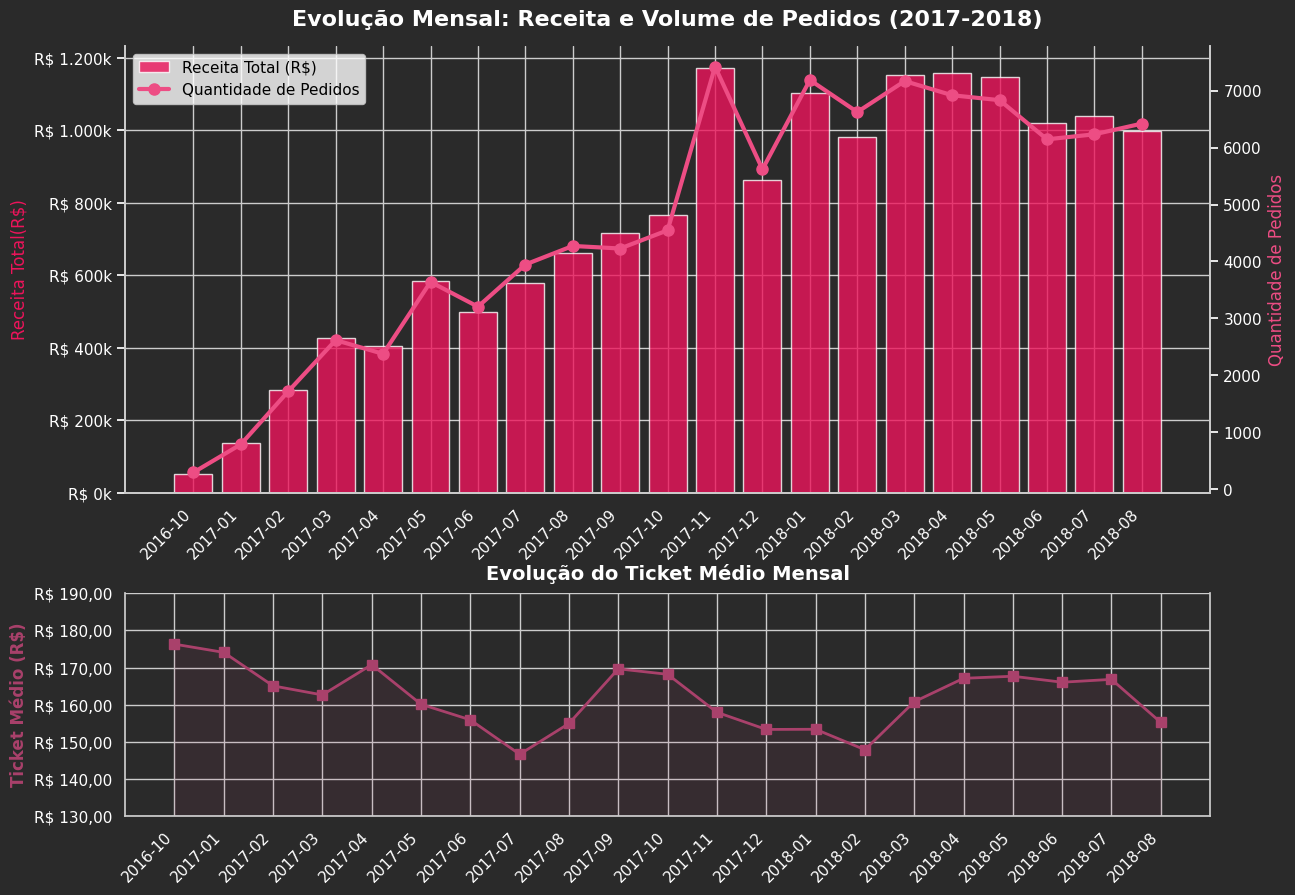

In [260]:
#Gerando gráficos:
import matplotlib.ticker as ticker

#Eixo primário --> Receita
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})
fig.set_facecolor(paleta_fiap[0]) # Definindo a cor de fundo da figura
plt.subplots_adjust(hspace=0.3)
sns.set_theme(style="whitegrid")

cor_receita = paleta_fiap[4] # Tom mais vibrante para Receita
cor_pedidos = paleta_fiap[3] # Tom mais claro para Pedidos
cor_ticket = paleta_fiap[2] # Tom médio para Ticket Médio

ax1.set_facecolor(paleta_fiap[0]) # Definindo a cor de fundo para ax1
ax1.bar(dados_limpos['ano_mes_str'], dados_limpos['receita_total'],
         color = cor_receita,
         alpha = 0.8,
         label = 'Receita Total (R$)')

ax1.set_ylabel('Receita Total(R$)',
               color = cor_receita,
               fontsize = 12)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x*1e-3:,.0f}k'.replace(',', '.')))
ax1.tick_params(axis='y', colors='white') # Cor dos ticks do eixo Y para branco

#Eixo secundário --> Quantidade de pedidos:
ax2 = ax1.twinx()
# ax2.set_facecolor(paleta_fiap[0]) # ax2 é transparente por padrão sobre ax1
ax2.plot(dados_limpos['ano_mes_str'], dados_limpos['total_pedidos'],
         color = cor_pedidos,
         marker = 'o', linewidth = 3, markersize = 8,
         label = 'Quantidade de Pedidos')
ax2.set_ylabel('Quantidade de Pedidos',
        color = cor_pedidos,
        fontsize = 12)
ax2.grid(False)
ax2.tick_params(axis='y', colors='white') # Cor dos ticks do eixo Y para branco

# Formatação Eixo 1
ax1.set_title('Evolução Mensal: Receita e Volume de Pedidos (2017-2018)', fontsize=16, fontweight='bold', pad=15, color='white')
ax1.set_xticks(range(len(dados_limpos['ano_mes_str'])))
ax1.set_xticklabels(dados_limpos['ano_mes_str'], rotation=45, ha='right', color='white')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, fontsize=11, labelcolor='black')


# Eixo Inferior: Ticket Médio (Linha com preenchimento)
ax3.set_facecolor(paleta_fiap[0]) # Definindo a cor de fundo para ax3
ax3.plot(dados_limpos['ano_mes_str'], dados_limpos['ticket_medio'], color = cor_ticket, marker='s', linewidth=2, markersize=7)
ax3.fill_between(dados_limpos['ano_mes_str'], dados_limpos['ticket_medio'], color = cor_ticket, alpha=0.1)
ax3.set_title('Evolução do Ticket Médio Mensal', fontsize=14, fontweight='bold', pad=10, color='white')
ax3.set_ylabel('Ticket Médio (R$)', color = cor_ticket, fontsize=12, fontweight='bold') # Cor do texto para branco
ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x:.2f}'.replace('.', ',')))
ax3.set_xticks(range(len(dados_limpos['ano_mes_str'])))
ax3.set_xticklabels(dados_limpos['ano_mes_str'], rotation=45, ha='right', color='white')
ax3.tick_params(axis='y', colors='white') # Cor dos ticks do eixo Y para branco
ax3.set_ylim(bottom=130, top=190)

sns.despine(right=False)
plt.show()

#### **b. Participação por região**

Pedidos por Estado:

Verificando a quantidade de compras e de clientes em cada Estado

In [261]:
resumo_estado = datasets['customers'].groupby('customer_state').agg(
    total_compras=('customer_id', 'count'),
    clientes_unicos=('customer_unique_id', 'nunique')
    ).reset_index()

resumo_estado.sort_values('clientes_unicos', ascending=False)

,customer_state,total_compras,clientes_unicos
25,SP,41746,40302
18,RJ,12852,12384
10,MG,11635,11259
22,RS,5466,5277
17,PR,5045,4882
23,SC,3637,3534
4,BA,3380,3277
6,DF,2140,2075
7,ES,2033,1964
8,GO,2020,1952


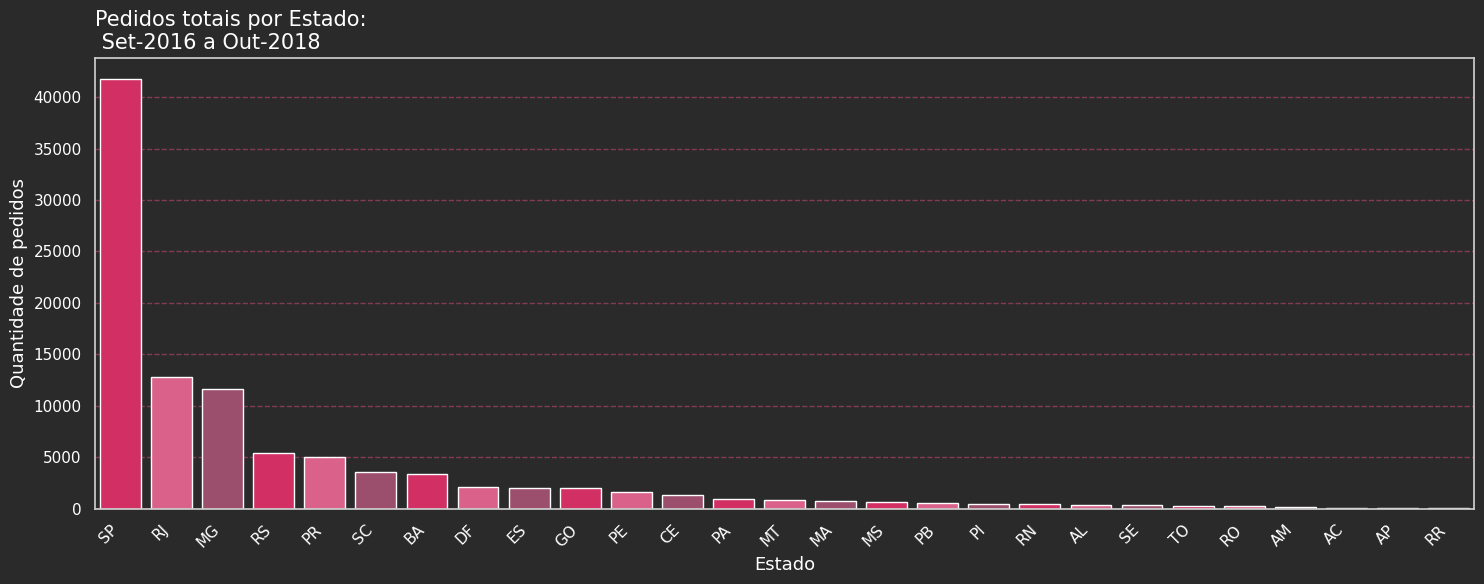

In [262]:
#Gerando gráfico de barras para compras por Estado:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenando em ordem decrescente para aplicar o gradiente corretamente
compras_estado_sorted = resumo_estado.sort_values(by='total_compras', ascending=False).reset_index(drop=True)

# Gerar uma paleta de cores contínua com a quantidade de cores necessárias
# para todos os estados. Utilizando apenas tons de rosa/vinho para as barras para garantir contraste com os fundos escuros.
n_states = len(compras_estado_sorted)
gradient_colors = sns.color_palette(paleta_fiap[2:][::-1], n_colors=n_states)

plt.figure(figsize=(15, 6), facecolor=paleta_fiap[0])
ax = sns.barplot(
    x='customer_state',
    y='total_compras',
    data=compras_estado_sorted,
    hue='customer_state',
    palette=gradient_colors,
    legend=False
)
ax.set_facecolor(paleta_fiap[0])

plt.title('Pedidos totais por Estado:\n Set-2016 a Out-2018', loc='left', color='white', fontsize=15)
plt.xlabel('Estado', color='white', fontsize=13)
plt.ylabel('Quantidade de pedidos', color='white', fontsize=13)
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(color='white')

# Adicionar grid horizontal para melhor referência
ax.yaxis.grid(True, linestyle='dashed', color=paleta_fiap[2], alpha=0.7)
ax.xaxis.grid(False) # Remover grid vertical para manter limpo

plt.tight_layout()
plt.show()

Participação por categoria

In [263]:
itens_pedidos = datasets['order_items']

#Itens mais vendidos a serem cruzados com a tabela de produtos,
#a fim de encontrar as top categorias:

pedidos_por_item = itens_pedidos.groupby(by=['product_id'], as_index=False).agg(
    valor_total_produtos = ('price', 'sum'),
    total_vendedores = ('seller_id', 'nunique'),
    qtde_vendida = ('order_item_id', 'sum'),
    valor_medio_unidade = ('price', 'mean'),
    top_seller = ('seller_id', 'max')
    ).sort_values('qtde_vendida', ascending=False)

pedidos_por_item[['valor_medio_unidade']] = pedidos_por_item[['valor_medio_unidade']].round(2)

pedidos_por_item.head(10)


,product_id,valor_total_produtos,total_vendedores,qtde_vendida,valor_medio_unidade,top_seller
8613,422879e10f46682990de24d770e7f83d,26577.22,1,793,54.91,1f50f920176fa81dab994f9023523100
22112,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90,1,640,71.36,955fee9216a65b617aa5c0531780ce60
7079,368c6c730842d78016ad823897a372db,21056.80,1,551,54.27,1f50f920176fa81dab994f9023523100
10840,53759a2ecddad2bb87a079a1f1519f73,20387.20,1,545,54.66,1f50f920176fa81dab994f9023523100
19742,99a4788cb24856965c36a24e339b6058,43025.56,2,542,88.17,53d00c40e32aeb924a84ce72b1af869d
7364,389d119b48cf3043d311335e499d9c6b,21440.59,1,534,54.70,1f50f920176fa81dab994f9023523100
27039,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51,1,369,137.65,a1043bafd471dff536d0c462352beb48
21302,a62e25e09e05e6faf31d90c6ec1aa3d1,24051.00,1,367,106.42,634964b17796e64304cadf1ad3050fb7
10867,53b36df67ebb7c41585e8d54d6772e08,37683.42,3,359,116.67,7d13fca15225358621be4086e1eb0964
8051,3dd2a17168ec895c781a9191c1e95ad7,41082.60,1,306,149.94,de722cd6dad950a92b7d4f82673f8833


In [264]:
#unindo dataframe com produtos para encontrarmos as categorias:
produtos = datasets['products']
categorias_mais_pedidas = pedidos_por_item.merge(produtos, on='product_id', how='left')

#grupando e ordenando por categoria e quantidade vendida:
categorias_mais_pedidas = categorias_mais_pedidas.groupby(['product_category_name'], as_index= False).agg(
    total_vendido = ('qtde_vendida', 'sum'),
    valor_medio_unidade = ('valor_medio_unidade', 'mean'),
    valor_total_produtos = ('valor_total_produtos', 'sum')
)

categorias_mais_pedidas = categorias_mais_pedidas.sort_values('total_vendido', ascending=False)
categorias_mais_pedidas.head(20)

,product_category_name,total_vendido,valor_medio_unidade,valor_total_produtos
13,cama_mesa_banho,13665,107.463367,1036988.68
54,moveis_decoracao,11540,103.233978,729762.49
11,beleza_saude,11081,146.776583,1258681.34
32,esporte_lazer,9932,135.441702,988048.97
44,informatica_acessorios,9874,156.028719,911954.32
72,utilidades_domesticas,9051,98.561096,632248.66
66,relogios_presentes,6594,335.905470,1205005.68
40,ferramentas_jardim,5874,222.614489,485256.46
70,telefonia,5161,83.826190,323667.53
8,automotivo,4881,152.576826,592720.11


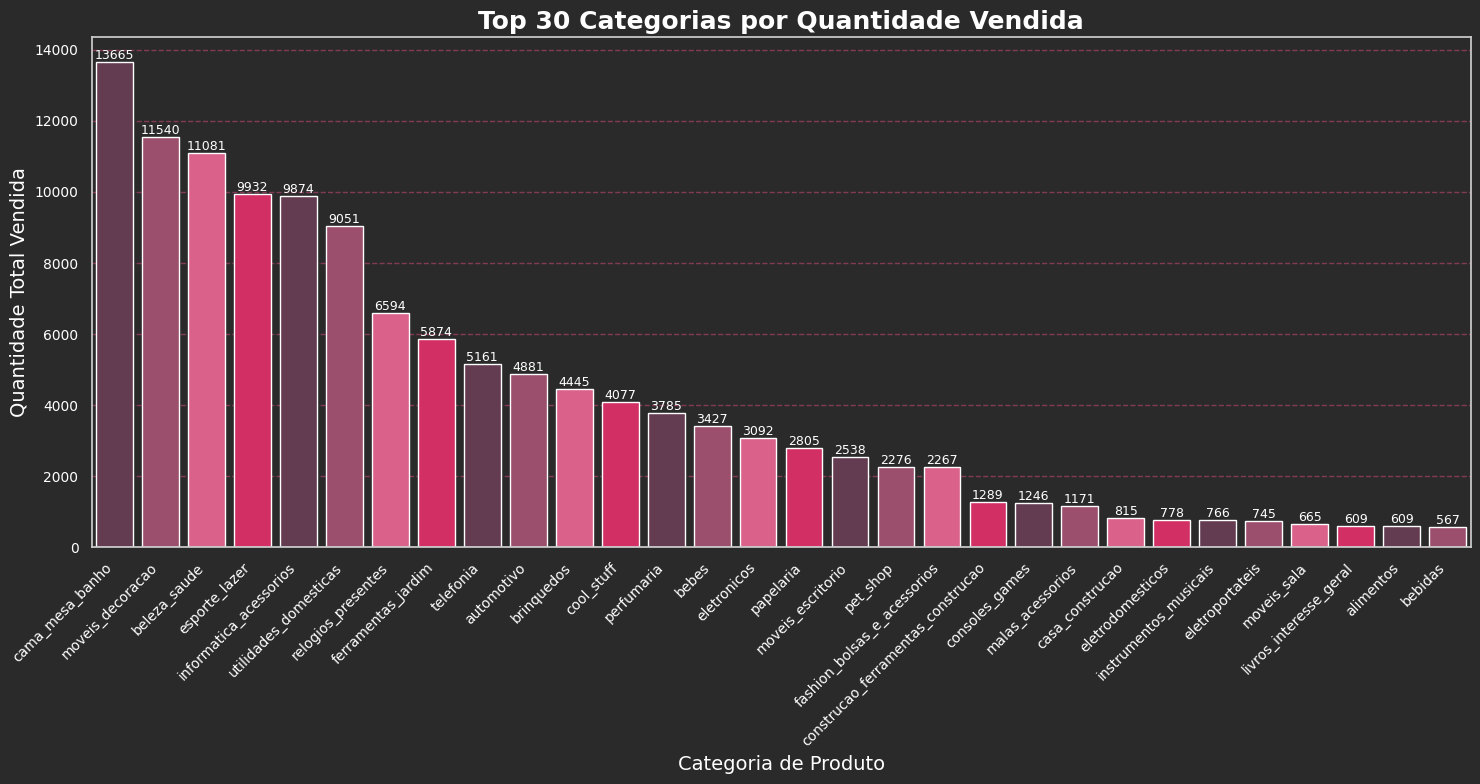

In [265]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar os dados para o plot, garantindo que o gradiente de cores seja aplicado corretamente
# para 'menor valor = tom mais escuro'. Para isso, ordenamos crescentemente.
df_plot = categorias_mais_pedidas.head(30).sort_values(by='total_vendido', ascending=False)

# Definir o número de barras para o gradiente de cores
n_bars = len(df_plot)

# Gerar uma paleta de cores contínua a partir do paleta_fiap, EXCLUINDO o primeiro tom (mais escuro)
# que será usado para o fundo. Isso garante que nenhuma barra terá a mesma cor do fundo.
# Usamos paleta_fiap[1:] para pegar apenas os tons de rosa, do mais escuro ao mais claro.
colors_for_bars = sns.color_palette(paleta_fiap[1:], n_colors=n_bars)

# Criar a figura e o axes
plt.figure(figsize=(15, 8), facecolor=paleta_fiap[0]) # Fundo da figura: tom mais escuro da paleta
ax = sns.barplot(
    x='product_category_name',
    y='total_vendido',
    data=df_plot,
    palette=colors_for_bars, # Aplicar a paleta de cores criada
    hue='product_category_name', # Usar 'hue' para que cada barra tenha uma cor diferente do gradiente
    legend=False # Desativar legenda, pois as cores representam o gradiente e não categorias distintas
)

# Fundo do plot: tom mais escuro da paleta
ax.set_facecolor(paleta_fiap[0])

# Título do gráfico (branco)
ax.set_title('Top 30 Categorias por Quantidade Vendida', loc='center', color='white', fontsize=18, fontweight='bold')

# Rótulos dos eixos (branco)
ax.set_xlabel('Categoria de Produto', color='white', fontsize=14)
ax.set_ylabel('Quantidade Total Vendida', color='white', fontsize=14)

# Rótulos dos ticks do eixo X (branco e rotacionados)
plt.xticks(rotation=45, ha='right', color='white', fontsize=10)

# Rótulos dos ticks do eixo Y (branco)
plt.yticks(color='white', fontsize=10)

# Adicionar grid horizontal para melhor referência, com cor da paleta e alpha
ax.yaxis.grid(True, linestyle='--', color=paleta_fiap[2], alpha=0.7)
ax.xaxis.grid(False) # Remover grid vertical

# Adicionar os valores no topo de cada barra (branco)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', color='white', fontsize=9)

# Ajustar layout para evitar sobreposição de rótulos
plt.tight_layout()

# Exibir o gráfico
plt.show()

Verificando a representatividade de cada Estado no total de pedidos

In [266]:
#Proporção de cada Estado no total do E-commerce:
proporcao_pedidos_totais = datasets['customers']['customer_state'].value_counts(normalize=True).reset_index()
proporcao_pedidos_totais['proportion'] = (proporcao_pedidos_totais['proportion']*100).round(2)

proporcao_pedidos_totais

,customer_state,proportion
0,SP,41.98
1,RJ,12.92
2,MG,11.70
3,RS,5.50
4,PR,5.07
5,SC,3.66
6,BA,3.40
7,DF,2.15
8,ES,2.04
9,GO,2.03


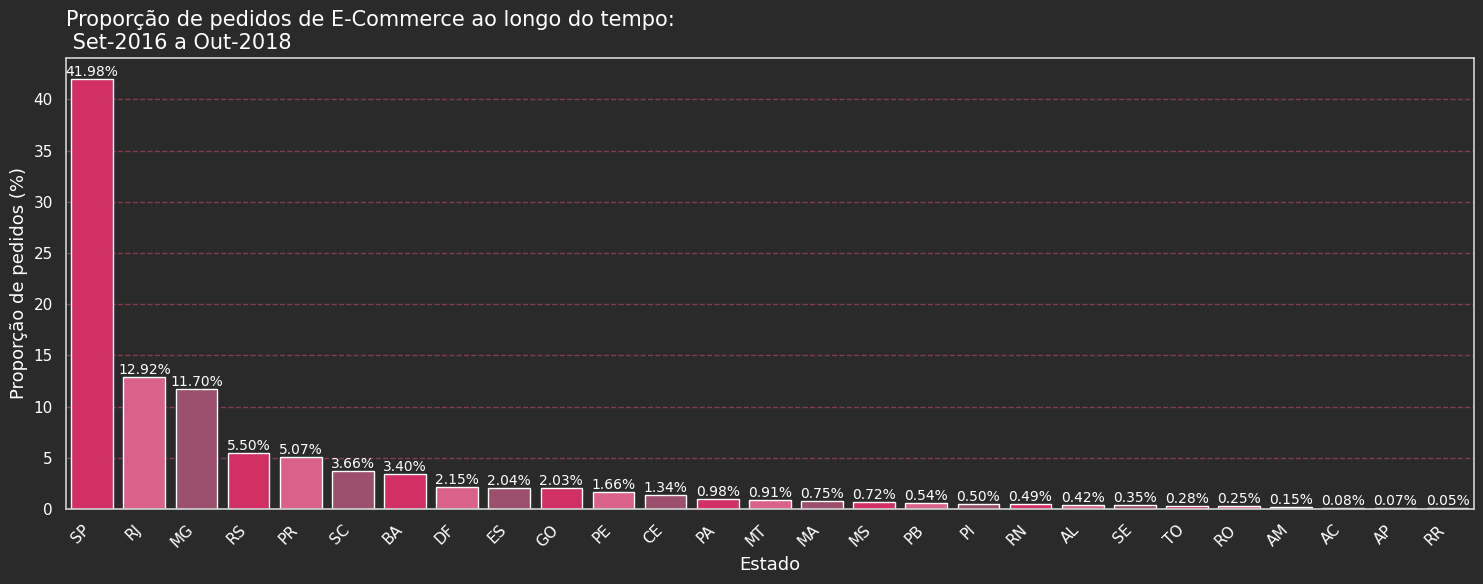

In [267]:
#Gerando gráfico de proporção por Estado:
import matplotlib.pyplot as plt
import seaborn as sns

n_states = len(compras_estado_sorted)
gradient_colors = sns.color_palette(paleta_fiap[2:][::-1], n_colors=n_states)

plt.figure(figsize = (15,6), facecolor=paleta_fiap[0])
ax = sns.barplot(
    x = 'customer_state',
    y = 'proportion',
    data = proporcao_pedidos_totais,
    palette = gradient_colors,
    hue = 'customer_state',
    legend = False
)
ax.set_facecolor(paleta_fiap[0])

plt.title('Proporção de pedidos de E-Commerce ao longo do tempo:\n Set-2016 a Out-2018', loc = 'left', fontsize = 15, color='white') # Título em branco
plt.xlabel('Estado', fontsize = 13, color='white')
plt.ylabel('Proporção de pedidos (%)', fontsize = 13, color='white')
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(color='white')

# Adicionar grid horizontal para melhor referência
ax.yaxis.grid(True, linestyle='dashed', color=paleta_fiap[2], alpha=0.7)
ax.xaxis.grid(False) # Remover grid vertical

# Incluir o valor 'proportion' no topo de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', color='white', fontsize=10)

plt.tight_layout() # Ajustar layout para prevenir sobreposição de rótulos
plt.show()

#### **c. Produtos/Categorias top performers**

Criando métricas unindo DataFrames ```pedidos```, ```intens```, ```produtos``` e ```nome_categorias```.

In [268]:
#importando datasets relevantes:

pedidos = datasets['orders']
itens = datasets['order_items']
produtos = datasets['products']
nome_categorias = datasets['product_category_name_translation']

itens.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


In [269]:
# filtrando pedidos válidos
status_validos = ['delivered', 'shipped', 'invoiced', 'processing', 'approved']
pedidos_validos = pedidos[pedidos['order_status'].isin(status_validos)]['order_id']
itens_validos = itens[itens['order_id'].isin(pedidos_validos)]

In [270]:
# Mesclando os dados
df_validados = itens_validos.merge(produtos[['product_id', 'product_category_name']], on='product_id', how='left')
df_validados = df_validados.merge(nome_categorias, on='product_category_name', how='left')

# criando coluna final de categoria
df_validados['categoria'] = df_validados['product_category_name'].str.replace('_', ' ').str.title()
df_validados['categoria'] = df_validados['categoria'].fillna('Outros')

df_validados

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,categoria
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff,Cool Stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop,Pet Shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor,Moveis Decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery,Perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools,Ferramentas Jardim
...,...,...,...,...,...,...,...,...,...,...
112096,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,utilidades_domesticas,housewares,Utilidades Domesticas
112097,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,informatica_acessorios,computers_accessories,Informatica Acessorios
112098,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,esporte_lazer,sports_leisure,Esporte Lazer
112099,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,informatica_acessorios,computers_accessories,Informatica Acessorios


In [271]:
# criando métricas por categoria
metricas_categorias = df_validados.groupby('categoria').agg(
    receita_total=('price', 'sum'),
    total_itens=('order_id', 'count'),       # volume total de itens
    pedidos_unicos=('order_id', 'nunique'),   # volume de pedidos únicos
    ticket_medio=('price', 'mean')             # Ticket Médio (Preço médio do item)
).reset_index()

# Filtrar categorias com baixíssimo volume (ruído estatístico) - mínimo de 200 itens vendidos
metricas_categorias = metricas_categorias[metricas_categorias['total_itens'] >= 200].copy()

metricas_categorias

,categoria,receita_total,total_itens,pedidos_unicos,ticket_medio
0,Agro Industria E Comercio,72530.47,212,182,342.124858
1,Alimentos,29243.51,509,449,57.452868
2,Alimentos Bebidas,15119.48,276,225,54.780725
3,Artes,24167.64,208,201,116.190577
7,Audio,50668.60,363,349,139.582920
8,Automotivo,586585.73,4204,3872,139.530383
9,Bebes,410312.20,3043,2868,134.838055
10,Bebidas,22378.71,378,296,59.202937
11,Beleza Saude,1255695.13,9634,8800,130.339955
12,Brinquedos,479808.54,4083,3855,117.513725


Top receitas/categoria

In [272]:
#filtrando e ordenando por 'receita_total'

receita_categorias = metricas_categorias[['categoria', 'receita_total']].sort_values('receita_total', ascending=False)
receita_categorias

,categoria,receita_total
11,Beleza Saude,1255695.13
67,Relogios Presentes,1198185.21
13,Cama Mesa Banho,1035964.06
32,Esporte Lazer,979740.92
44,Informatica Acessorios,904322.02
54,Moveis Decoracao,727465.05
73,Utilidades Domesticas,626825.80
26,Cool Stuff,620770.49
8,Automotivo,586585.73
40,Ferramentas Jardim,481009.94


Top tickets/Categorias

In [273]:
ticket_categorias = metricas_categorias[['categoria', 'ticket_medio']].sort_values('ticket_medio', ascending=False).round(2).copy()
ticket_categorias

,categoria,ticket_medio
62,Pcs,1098.34
29,Eletrodomesticos 2,470.85
0,Agro Industria E Comercio,342.12
45,Instrumentos Musicais,280.70
31,Eletroportateis,280.04
72,Telefonia Fixa,221.55
67,Relogios Presentes,200.70
19,Climatizacao,185.50
53,Moveis Cozinha Area De Servico Jantar E Jardim,165.13
26,Cool Stuff,164.27


Consolidação das métricas

In [274]:
# mesclando dataframes de ticket e receita por categoria:
ticket_receita = receita_categorias.merge(ticket_categorias, on = 'categoria', how = 'left')
ticket_receita

,categoria,receita_total,ticket_medio
0,Beleza Saude,1255695.13,130.34
1,Relogios Presentes,1198185.21,200.70
2,Cama Mesa Banho,1035964.06,93.36
3,Esporte Lazer,979740.92,114.06
4,Informatica Acessorios,904322.02,116.22
5,Moveis Decoracao,727465.05,87.67
6,Utilidades Domesticas,626825.80,90.65
7,Cool Stuff,620770.49,164.27
8,Automotivo,586585.73,139.53
9,Ferramentas Jardim,481009.94,111.14


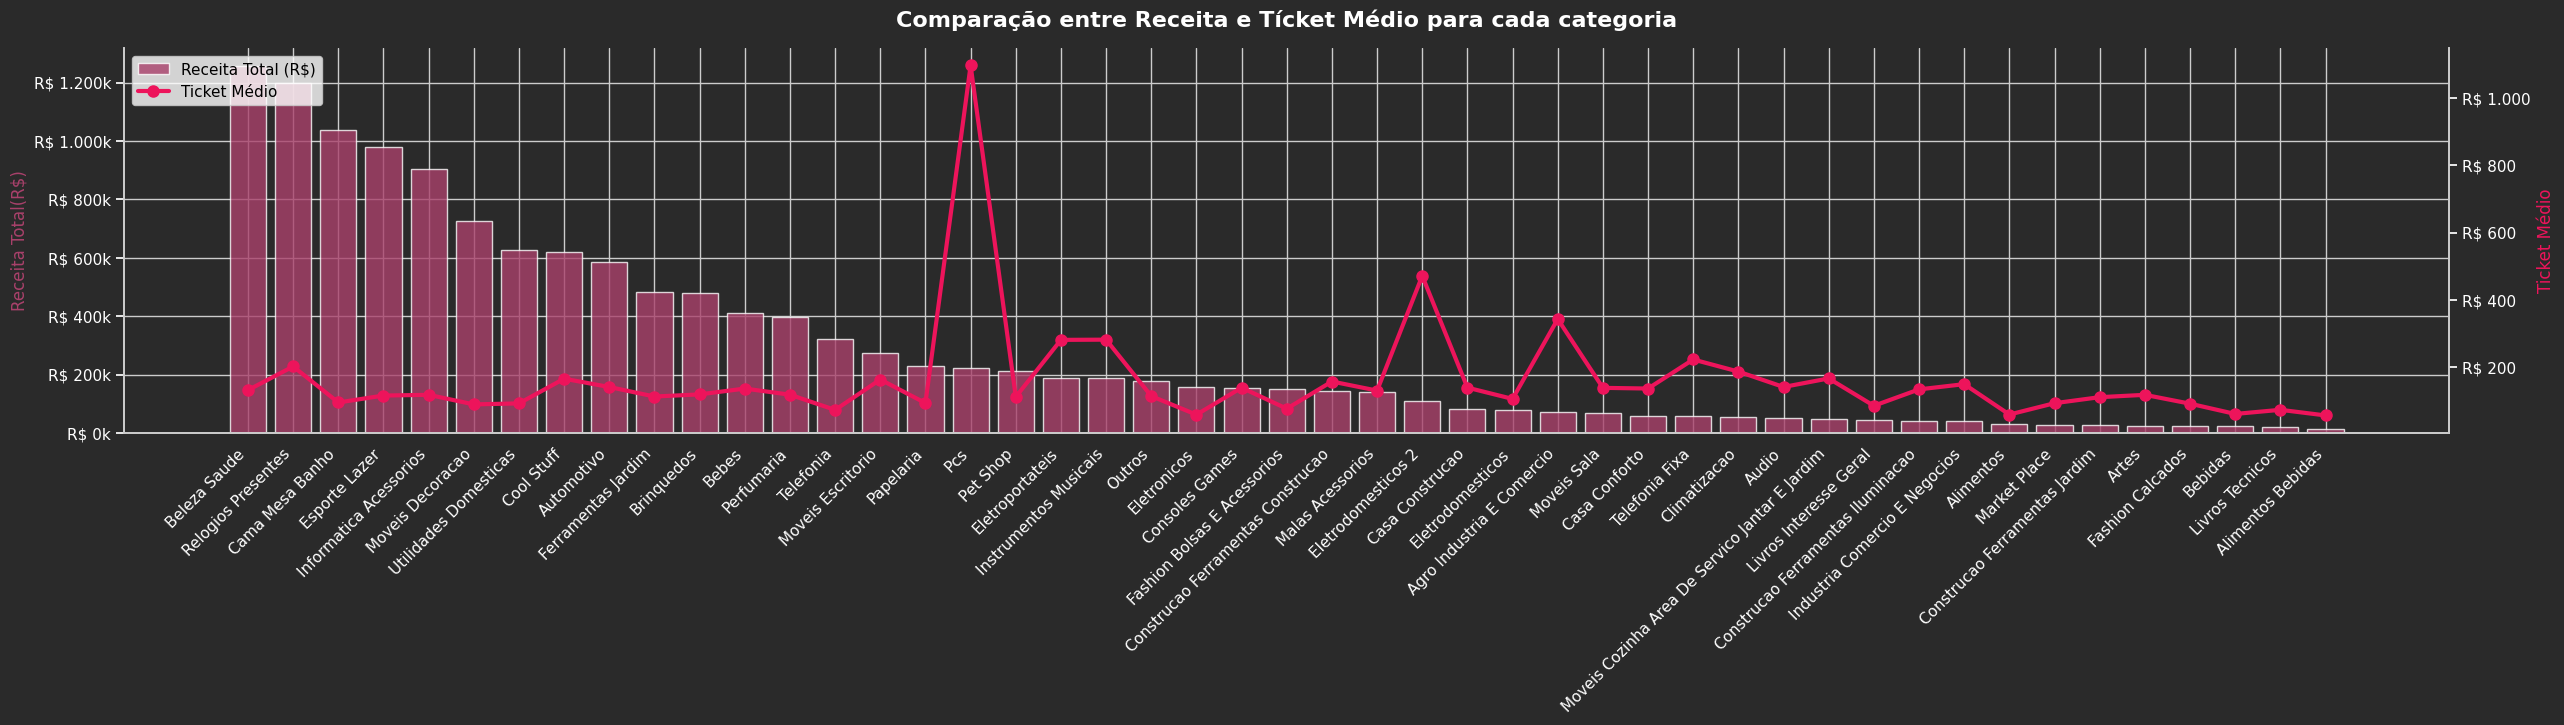

In [275]:
#Gerando gráficos:
import matplotlib.ticker as ticker
paleta_fiap = ['#2a2a2a', '#6a3652', '#a9416b', '#ed4d84', '#ED145B']

# Receita
fig, ax1 = plt.subplots(1, 1, figsize=(30, 5))
fig.set_facecolor(paleta_fiap[0]) # Definindo a cor de fundo da figura
sns.set_theme(style="whitegrid")

cor_receita = paleta_fiap[2] # Tom mais vibrante para Receita
cor_ticket = paleta_fiap[4] # Tom mais médio para ticket


ax1.set_facecolor(paleta_fiap[0]) # Definindo a cor de fundo para ax1
ax1.bar(ticket_receita['categoria'], ticket_receita['receita_total'],
         color = cor_receita,
         alpha = 0.8,
         label = 'Receita Total (R$)')

ax1.set_ylabel('Receita Total(R$)',
               color = cor_receita,
               fontsize = 12)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x*1e-3:,.0f}k'.replace(',', '.')))
ax1.tick_params(axis='y', colors='white') # Cor dos ticks do eixo Y para branco

#Ticket Médio:
ax2 = ax1.twinx()
# ax2.set_facecolor(paleta_fiap[0]) # ax2 é transparente por padrão sobre ax1
ax2.plot(ticket_receita['categoria'], ticket_receita['ticket_medio'],
         color = cor_ticket,
         marker = 'o', linewidth = 3, markersize = 8,
         label = 'Ticket Médio')
ax2.set_ylabel('Ticket Médio',
        color = cor_ticket,
        fontsize = 12)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x*1:,.0f}'.replace(',', '.')))
ax2.grid(False)
ax2.tick_params(axis='y', colors='white') # Cor dos ticks do eixo Y para branco

# Formatação Eixo 1
ax1.set_title('Comparação entre Receita e Tícket Médio para cada categoria', fontsize=16, fontweight='bold', pad=15, color='white')
ax1.set_xticks(range(len(ticket_receita['categoria'])))
ax1.set_xticklabels(ticket_receita['categoria'], rotation=45, ha='right', color='white')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, fontsize=11, labelcolor='black')

sns.despine(right=False)
plt.show()

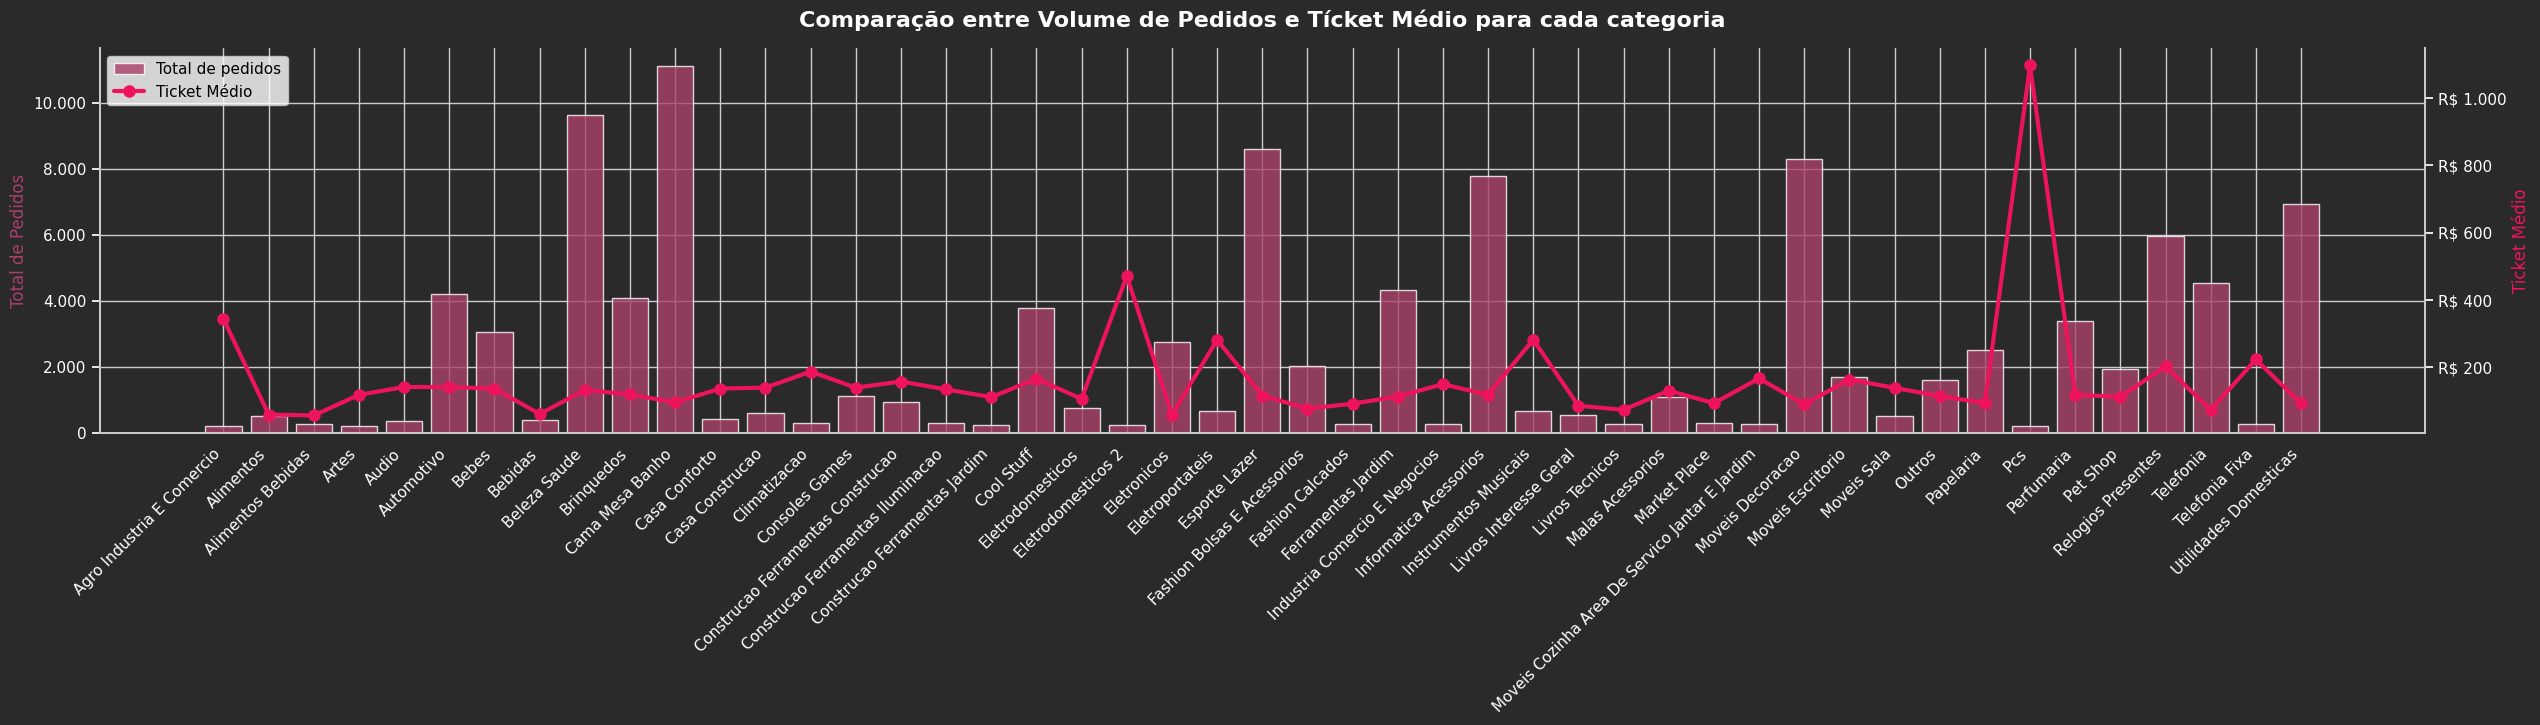

In [276]:
#Número de pedidos x Ticket médio:

#Gerando gráficos:
import matplotlib.ticker as ticker
paleta_fiap = ['#2a2a2a', '#6a3652', '#a9416b', '#ed4d84', '#ED145B']

#Eixo primário --> Receita
fig, ax1 = plt.subplots(1, 1, figsize=(30, 5))
fig.set_facecolor(paleta_fiap[0]) # Definindo a cor de fundo da figura
#plt.subplots_adjust(hspace=0.3)
sns.set_theme(style="whitegrid")

cor_volume = paleta_fiap[2] # Tom mais vibrante para Receita
cor_ticket = paleta_fiap[4] # Tom mais médio para ticket


ax1.set_facecolor(paleta_fiap[0]) # Definindo a cor de fundo para ax1
ax1.bar(metricas_categorias['categoria'], metricas_categorias['total_itens'],
         color = cor_volume,
         alpha = 0.8,
         label = 'Total de pedidos')

ax1.set_ylabel('Total de Pedidos',
               color = cor_volume,
               fontsize = 12)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1:,.0f}'.replace(',', '.')))
ax1.tick_params(axis='y', colors='white') # Cor dos ticks do eixo Y para branco

#Eixo secundário --> Ticket Médio:
ax2 = ax1.twinx()
# ax2.set_facecolor(paleta_fiap[0]) # ax2 é transparente por padrão sobre ax1
ax2.plot(metricas_categorias['categoria'], metricas_categorias['ticket_medio'],
         color = cor_ticket,
         marker = 'o', linewidth = 3, markersize = 8,
         label = 'Ticket Médio')
ax2.set_ylabel('Ticket Médio',
        color = cor_ticket,
        fontsize = 12)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x*1:,.0f}'.replace(',', '.')))
ax2.grid(False)
ax2.tick_params(axis='y', colors='white') # Cor dos ticks do eixo Y para branco

# Formatação Eixo 1
ax1.set_title('Comparação entre Volume de Pedidos e Tícket Médio para cada categoria', fontsize=16, fontweight='bold', pad=15, color='white')
ax1.set_xticks(range(len(metricas_categorias['categoria'])))
ax1.set_xticklabels(metricas_categorias['categoria'], rotation=45, ha='right', color='white')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, fontsize=11, labelcolor='black')

sns.despine(right=False)
plt.show()

#### **d. Sellers top performers**

In [277]:
top_sellers = itens_pedidos.groupby(by=['seller_id'], as_index=False).agg(
    valor_total_produtos = ('price', 'sum'), #Quantidade vendida * preço do produto
    qtde_vendida = ('order_item_id', 'sum'), #total de itens vendidos
    valor_medio_unidade = ('price', 'mean')
    ).sort_values('qtde_vendida', ascending=False)

top_sellers[['valor_medio_unidade']] = pedidos_por_item[['valor_medio_unidade']].round(2)

top_sellers

,seller_id,valor_total_produtos,qtde_vendida,valor_medio_unidade
368,1f50f920176fa81dab994f9023523100,106939.21,2898,24.99
192,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,2290,14.10
881,4a3ca9315b744ce9f8e9374361493884,200472.92,2269,35.00
1235,6560211a19b47992c3666cc44a7e94c0,123304.83,2261,289.00
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89,2172,489.00
...,...,...,...,...
2561,d36b07fd3c5088e477a72d1fccfe29d4,328.90,1,49.99
2553,d297f1055de2956aedfd3b04113dce3e,54.30,1,329.00
2551,d263fa444c1504a75cbca5cc465f592a,399.00,1,739.90
2549,d2572f31e9023e9850ef986a636ff9bf,279.00,1,188.90


In [278]:
#Identificando quais são os 10 vendedores mais performáticos:
top_sellers[['seller_id']].head(10).values

array([['1f50f920176fa81dab994f9023523100'],
       ['1025f0e2d44d7041d6cf58b6550e0bfa'],
       ['4a3ca9315b744ce9f8e9374361493884'],
       ['6560211a19b47992c3666cc44a7e94c0'],
       ['7c67e1448b00f6e969d365cea6b010ab'],
       ['da8622b14eb17ae2831f4ac5b9dab84a'],
       ['cc419e0650a3c5ba77189a1882b7556a'],
       ['955fee9216a65b617aa5c0531780ce60'],
       ['ea8482cd71df3c1969d7b9473ff13abc'],
       ['3d871de0142ce09b7081e2b9d1733cb1']], dtype=object)

### **II. Logística e SLA**

#### **a.Base analítica de logística**

A base analítica de logística foi estruturada para avaliar o desempenho da jornada de entrega, considerando pedidos entregues, tempo de entrega e ocorrência de atrasos.

Para garantir maior consistência nas métricas de tempo, a análise considera apenas pedidos entregues. Os atrasos são tratados de forma positiva, enquanto entregas realizadas no prazo ou antecipadamente são consideradas sem atraso.

In [279]:
# 1. FONTES

df_pedidos = datasets['orders'].copy()
df_clientes = datasets['customers'].copy()
df_reviews = datasets['reviews'].copy()

# 2. PADRONIZAÇÃO

df_pedidos = df_pedidos.rename(columns={
    'order_status': 'status_pedido',
    'order_purchase_timestamp': 'dt_pedido',
    'order_approved_at': 'dt_aprovacao',
    'order_delivered_carrier_date': 'dt_postagem',
    'order_delivered_customer_date': 'dt_entrega',
    'order_estimated_delivery_date': 'dt_estimada_entrega'
})


# 3. DATAS

colunas_data = [
    'dt_pedido',
    'dt_aprovacao',
    'dt_postagem',
    'dt_entrega',
    'dt_estimada_entrega'
]

df_pedidos[colunas_data] = (
    df_pedidos[colunas_data]
    .apply(pd.to_datetime, errors='coerce')
)


# 4. REVIEWS — 1 REGISTRO POR PEDIDO

reviews_pedido = (
    df_reviews
    .groupby('order_id', as_index=False)
    .agg(
        review_score=('review_score', 'mean')
    )
)


# 5. BASE ANALÍTICA

df_logistica = (
    df_pedidos[
        [
            'order_id',
            'customer_id',
            'status_pedido',
            'dt_pedido',
            'dt_aprovacao',
            'dt_postagem',
            'dt_entrega',
            'dt_estimada_entrega'
        ]
    ]
    .merge(
        df_clientes[
            [
                'customer_id',
                'customer_unique_id',
                'customer_state',
                'customer_city',
                'customer_zip_code_prefix'
            ]
        ],
        on='customer_id',
        how='left'
    )
    .merge(
        reviews_pedido,
        on='order_id',
        how='left'
    )
)

# 6. INDICADORES DA JORNADA

df_logistica['pedido_entregue'] = (
    df_logistica['dt_entrega'].notna()
)

df_logistica['tempo_aprovacao_dias'] = (
    df_logistica['dt_aprovacao']
    - df_logistica['dt_pedido']
).dt.total_seconds() / 86400

df_logistica['tempo_postagem_dias'] = (
    df_logistica['dt_postagem']
    - df_logistica['dt_aprovacao']
).dt.total_seconds() / 86400

df_logistica['tempo_transporte_dias'] = (
    df_logistica['dt_entrega']
    - df_logistica['dt_postagem']
).dt.total_seconds() / 86400

df_logistica['lead_time_dias'] = (
    df_logistica['dt_entrega']
    - df_logistica['dt_pedido']
).dt.total_seconds() / 86400

df_logistica['atraso_dias'] = (
    df_logistica['dt_entrega']
    - df_logistica['dt_estimada_entrega']
).dt.total_seconds() / 86400

# 7. SLA

df_logistica['sla_status'] = np.select(
    [
        ~df_logistica['pedido_entregue'],
        df_logistica['atraso_dias'] <= 0,
        df_logistica['atraso_dias'] > 0
    ],
    [
        'Não entregue',
        'No prazo',
        'Atrasado'
    ],
    default='Indefinido'
)

# 8. BASE DE ENTREGUES

df_logistica_entregue = (
    df_logistica
    .loc[df_logistica['pedido_entregue']]
    .copy()
)

# Apenas atrasos positivos
df_logistica_entregue['dias_atraso_positivo'] = (
    df_logistica_entregue['atraso_dias']
    .clip(lower=0)
)

# 9. VALIDAÇÃO DA BASE

pedidos_base = df_logistica['order_id'].nunique()

pedidos_entregues = (
    df_logistica_entregue['order_id'].nunique()
)

pedidos_nao_entregues = (
    (~df_logistica['pedido_entregue']).sum()
)

pedidos_atrasados = (
    df_logistica_entregue['atraso_dias'] > 0
).sum()

percentual_atrasados = (
    df_logistica_entregue['atraso_dias'] > 0
).mean() * 100

pedidos_com_avaliacao = (
    df_logistica['review_score'].notna().sum()
)

duplicidades = (
    df_logistica['order_id'].duplicated().sum()
)

# 10. SAÍDA


print("VALIDAÇÃO — BASE ANALÍTICA DE LOGÍSTICA E SLA")
print("=" * 60)

print(f"Pedidos na base:             {pedidos_base:,}")
print(f"Linhas na base:              {len(df_logistica):,}")
print(f"Pedidos entregues:           {pedidos_entregues:,}")
print(f"Pedidos não entregues:       {pedidos_nao_entregues:,}")
print(f"Pedidos atrasados:           {pedidos_atrasados:,}")
print(f"Percentual de atrasados:     {percentual_atrasados:.2f}%")
print(f"Pedidos com avaliação:       {pedidos_com_avaliacao:,}")
print(f"Duplicidade de order_id:     {duplicidades:,}")


# Espaço antes da amostra
print("\n")
print("AMOSTRA DA BASE ANALÍTICA")
print("=" * 60)

display(
    df_logistica[
        [
            'order_id',
            'status_pedido',
            'customer_state',
            'review_score',
            'tempo_aprovacao_dias',
            'tempo_postagem_dias',
            'tempo_transporte_dias',
            'lead_time_dias',
            'atraso_dias',
            'sla_status'
        ]
    ].head(10)
)

VALIDAÇÃO — BASE ANALÍTICA DE LOGÍSTICA E SLA
Pedidos na base:             99,441
Linhas na base:              99,441
Pedidos entregues:           96,476
Pedidos não entregues:       2,965
Pedidos atrasados:           7,827
Percentual de atrasados:     8.11%
Pedidos com avaliação:       98,673
Duplicidade de order_id:     0


AMOSTRA DA BASE ANALÍTICA


,order_id,status_pedido,customer_state,review_score,tempo_aprovacao_dias,tempo_postagem_dias,tempo_transporte_dias,lead_time_dias,atraso_dias,sla_status
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,SP,4.0,0.007431,2.366493,6.062650,8.436574,-7.107488,No prazo
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,BA,4.0,1.279745,0.462882,12.039410,13.782037,-5.355729,No prazo
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,GO,5.0,0.011505,0.204595,9.178113,9.394213,-17.245498,No prazo
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,RN,5.0,0.012419,3.745833,9.450498,13.208750,-12.980069,No prazo
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,SP,5.0,0.042940,0.893113,1.937824,2.873877,-9.238171,No prazo
5,a4591c265e18cb1dcee52889e2d8acc3,delivered,PR,4.0,0.009120,1.699896,14.833229,16.542245,-5.543113,No prazo
6,136cce7faa42fdb2cefd53fdc79a6098,invoiced,RS,2.0,2.043854,NaN,NaN,NaN,NaN,Não entregue
7,6514b8ad8028c9f2cc2374ded245783f,delivered,RJ,5.0,0.008113,5.864988,4.116725,9.989826,-11.461215,No prazo
8,76c6e866289321a7c93b82b54852dc33,delivered,RS,1.0,1.348356,1.476204,6.994201,9.818762,-31.410995,No prazo
9,e69bfb5eb88e0ed6a785585b27e16dbf,delivered,SP,5.0,0.007292,12.319352,5.895208,18.221852,-6.281597,No prazo


In [280]:
# ============================================================
# VALIDAÇÃO DA BASE ANALÍTICA
# ============================================================

resumo_base = pd.DataFrame({
    'Indicador': [
        'Pedidos',
        'Clientes únicos',
        'Estados',
        'Pedidos entregues',
        'Pedidos não entregues',
        'Pedidos com avaliação'
    ],
    'Quantidade': [
        df_logistica['order_id'].nunique(),
        df_logistica['customer_unique_id'].nunique(),
        df_logistica['customer_state'].nunique(),
        df_logistica['pedido_entregue'].sum(),
        (~df_logistica['pedido_entregue']).sum(),
        df_logistica['review_score'].notna().sum()
    ]
})

resumo_base['Percentual'] = (
    resumo_base['Quantidade']
    / df_logistica['order_id'].nunique()
    * 100
)

display(resumo_base.round(2))

,Indicador,Quantidade,Percentual
0,Pedidos,99441,100.00
1,Clientes únicos,96096,96.64
2,Estados,27,0.03
3,Pedidos entregues,96476,97.02
4,Pedidos não entregues,2965,2.98
5,Pedidos com avaliação,98673,99.23


In [281]:
# ============================================================
# QUALIDADE DOS DADOS
# ============================================================

qualidade_dados = pd.DataFrame({
    'Variável': [
        'dt_pedido',
        'dt_aprovacao',
        'dt_postagem',
        'dt_entrega',
        'dt_estimada_entrega',
        'review_score',
        'lead_time_dias',
        'atraso_dias'
    ],
    'Nulos': [
        df_logistica['dt_pedido'].isna().sum(),
        df_logistica['dt_aprovacao'].isna().sum(),
        df_logistica['dt_postagem'].isna().sum(),
        df_logistica['dt_entrega'].isna().sum(),
        df_logistica['dt_estimada_entrega'].isna().sum(),
        df_logistica['review_score'].isna().sum(),
        df_logistica['lead_time_dias'].isna().sum(),
        df_logistica['atraso_dias'].isna().sum()
    ]
})

qualidade_dados['% Nulos'] = (
    qualidade_dados['Nulos']
    / len(df_logistica)
    * 100
)

display(
    qualidade_dados.round(2)
)

,Variável,Nulos,% Nulos
0,dt_pedido,0,0.00
1,dt_aprovacao,160,0.16
2,dt_postagem,1783,1.79
3,dt_entrega,2965,2.98
4,dt_estimada_entrega,0,0.00
5,review_score,768,0.77
6,lead_time_dias,2965,2.98
7,atraso_dias,2965,2.98


In [282]:
# ============================================================
# INTERPRETAÇÃO DOS NULOS
# ============================================================

qualidade_dados['Interpretação'] = [
    'Não esperado',
    'Pode ocorrer em pedidos sem aprovação',
    'Pode ocorrer em pedidos não postados',
    'Esperado em pedidos não entregues',
    'Não esperado',
    'Pode ocorrer em pedidos sem avaliação',
    'Esperado em pedidos não entregues',
    'Esperado em pedidos não entregues'
]

display(
    qualidade_dados.round(2)
)

,Variável,Nulos,% Nulos,Interpretação
0,dt_pedido,0,0.00,Não esperado
1,dt_aprovacao,160,0.16,Pode ocorrer em pedidos sem aprovação
2,dt_postagem,1783,1.79,Pode ocorrer em pedidos não postados
3,dt_entrega,2965,2.98,Esperado em pedidos não entregues
4,dt_estimada_entrega,0,0.00,Não esperado
5,review_score,768,0.77,Pode ocorrer em pedidos sem avaliação
6,lead_time_dias,2965,2.98,Esperado em pedidos não entregues
7,atraso_dias,2965,2.98,Esperado em pedidos não entregues


In [283]:
status_pedidos = (df_logistica.groupby('status_pedido').agg(pedidos=('order_id', 'nunique')).reset_index())
status_pedidos['percentual'] = (status_pedidos['pedidos']/ status_pedidos['pedidos'].sum()* 100)
status_pedidos = status_pedidos.sort_values('pedidos',ascending=False)

display(status_pedidos.round(2))

,status_pedido,pedidos,percentual
3,delivered,96478,97.02
6,shipped,1107,1.11
1,canceled,625,0.63
7,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
2,created,5,0.01
0,approved,2,0.00


In [284]:
import pandas as pd

# ============================================================
# LEAD TIME
# ============================================================

resumo_lead_time = pd.DataFrame({
    'Métrica': [
        'Média',
        'Mediana',
        'Mínimo',
        'P25',
        'P75',
        'P90',
        'P95',
        'Máximo'
    ],
    'Dias': [
        df_logistica_entregue['lead_time_dias'].mean(),
        df_logistica_entregue['lead_time_dias'].median(),
        df_logistica_entregue['lead_time_dias'].min(),
        df_logistica_entregue['lead_time_dias'].quantile(0.25),
        df_logistica_entregue['lead_time_dias'].quantile(0.75),
        df_logistica_entregue['lead_time_dias'].quantile(0.90),
        df_logistica_entregue['lead_time_dias'].quantile(0.95),
        df_logistica_entregue['lead_time_dias'].max()
    ]
})

display(resumo_lead_time.round(2))

,Métrica,Dias
0,Média,12.56
1,Mediana,10.22
2,Mínimo,0.53
3,P25,6.77
4,P75,15.72
5,P90,23.10
6,P95,29.28
7,Máximo,209.63


#### **b.KPIs — OPERAÇÃO LOGÍSTICA**

In [285]:
kpis_logistica = pd.DataFrame({
    'Indicador': [
        'Pedidos analisados',
        'Pedidos entregues',
        'Pedidos atrasados',
        'SLA cumprido',
        'Pedidos não entregues',
        'Lead Time médio',
        'Atraso médio',
        'Tempo médio de transporte'
    ],

    'Resultado': [
        f'{df_logistica["order_id"].nunique():,}',

        f'{df_logistica_entregue["order_id"].nunique():,}',

        f'{(df_logistica_entregue["atraso_dias"] > 0).sum():,}',

        f'{df_logistica["sla_status"].eq("No prazo").mean() * 100:.2f}%',

        f'{df_logistica["sla_status"].eq("Não entregue").sum():,}',

        f'{df_logistica_entregue["lead_time_dias"].mean():.2f} dias',

        f'{df_logistica_entregue["dias_atraso_positivo"].mean():.2f} dias',

        f'{df_logistica_entregue["tempo_transporte_dias"].mean():.2f} dias'
    ]
})


# ------------------------------------------------------------
# Exibição
# ------------------------------------------------------------

display(
    kpis_logistica
    .style
    .hide(axis='index')
    .set_caption('INDICADORES DA OPERAÇÃO LOGÍSTICA')
    .set_properties(**{
        'text-align': 'left',
        'font-size': '12pt'
    })
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('font-size', '16px'),
                ('font-weight', 'bold'),
                ('text-align', 'left'),
                ('padding', '10px 0')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('font-weight', 'bold'),
                ('text-align', 'left')
            ]
        }
    ])
)

Indicador,Resultado
Pedidos analisados,"99,441"
Pedidos entregues,"96,476"
Pedidos atrasados,"7,827"
SLA cumprido,89.15%
Pedidos não entregues,"2,965"
Lead Time médio,12.56 dias
Atraso médio,0.77 dias
Tempo médio de transporte,9.33 dias


#### **c. Jornada logística — Onde está o gargalo?**

In [286]:
# 1. Tempo médio por etapa

jornada_logistica = pd.DataFrame({
    'Etapa': [
        'Compra → Aprovação',
        'Aprovação → Postagem',
        'Postagem → Entrega'
    ],

    'Tempo Médio (dias)': [
        df_logistica_entregue['tempo_aprovacao_dias'].mean(),
        df_logistica_entregue['tempo_postagem_dias'].mean(),
        df_logistica_entregue['tempo_transporte_dias'].mean()
    ]
})


# 2. Participação de cada etapa


tempo_operacional = (
    jornada_logistica['Tempo Médio (dias)'].sum()
)

jornada_logistica['Participação (%)'] = (
    jornada_logistica['Tempo Médio (dias)']
    / tempo_operacional
    * 100
)


# ------------------------------------------------------------
# 3. Identificar o gargalo
# ------------------------------------------------------------

gargalo = jornada_logistica.loc[
    jornada_logistica['Tempo Médio (dias)'].idxmax()
]


# ------------------------------------------------------------
# 4. Lead Time total
# ------------------------------------------------------------

lead_time_total = (
    df_logistica_entregue['lead_time_dias'].mean()
)


# ------------------------------------------------------------
# 5. Exibição
# ------------------------------------------------------------

print("JORNADA LOGÍSTICA — DECOMPOSIÇÃO DO LEAD TIME")
print("=" * 65)

display(
    jornada_logistica
    .style
    .hide(axis='index')
    .format({
        'Tempo Médio (dias)': '{:.2f}',
        'Participação (%)': '{:.1f}%'
    })
)


# ------------------------------------------------------------
# 6. Principais achados
# ------------------------------------------------------------

print("\n📌 PRINCIPAIS ACHADOS")
print("-" * 65)

print(
    f"Lead Time médio total: "
    f"{lead_time_total:.2f} dias"
)

print(
    f"Principal gargalo: "
    f"{gargalo['Etapa']} "
    f"({gargalo['Tempo Médio (dias)']:.2f} dias)"
)

print(
    f"Participação no tempo operacional: "
    f"{gargalo['Participação (%)']:.1f}%"
)

JORNADA LOGÍSTICA — DECOMPOSIÇÃO DO LEAD TIME


Etapa,Tempo Médio (dias),Participação (%)
Compra → Aprovação,0.43,3.4%
Aprovação → Postagem,2.80,22.3%
Postagem → Entrega,9.33,74.3%



📌 PRINCIPAIS ACHADOS
-----------------------------------------------------------------
Lead Time médio total: 12.56 dias
Principal gargalo: Postagem → Entrega (9.33 dias)
Participação no tempo operacional: 74.3%


In [287]:
# ============================================================
# JORNADA LOGÍSTICA — MÉDIA × MEDIANA POR ETAPA
# ============================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ------------------------------------------------------------
# 1. Consolidar as etapas da jornada
# ------------------------------------------------------------

etapas = pd.DataFrame({
    'Etapa': [
        'Compra → Aprovação',
        'Aprovação → Postagem',
        'Postagem → Entrega',
        'Compra → Entrega'
    ],

    'Media': [
        df_logistica['tempo_aprovacao_dias'].mean(),
        df_logistica['tempo_postagem_dias'].mean(),
        df_logistica['tempo_transporte_dias'].mean(),
        df_logistica['lead_time_dias'].mean()
    ],

    'Mediana': [
        df_logistica['tempo_aprovacao_dias'].median(),
        df_logistica['tempo_postagem_dias'].median(),
        df_logistica['tempo_transporte_dias'].median(),
        df_logistica['lead_time_dias'].median()
    ]
})

# Remover valores inválidos
etapas = etapas.dropna()

# ------------------------------------------------------------
# 2. Identificar a etapa crítica
# ------------------------------------------------------------

etapa_critica = etapas.loc[
    etapas['Media'].idxmax(),
    'Etapa'
]

# ------------------------------------------------------------
# 3. Criar gráfico
# ------------------------------------------------------------

fig = go.Figure()

# Barras — Média
fig.add_trace(
    go.Bar(
        x=etapas['Etapa'],
        y=etapas['Media'],
        name='Média',
        marker=dict(
            color=[
                '#4A4A4A',
                '#6F3A56',
                '#E34B82',
                '#ED145B'
            ],
            line=dict(
                color='#FFFFFF',
                width=0.5
            )
        ),
        text=[
            f'{valor:.2f} dias'
            for valor in etapas['Media']
        ],
        textposition='outside',
        textfont=dict(
            color='white',
            size=13
        ),
        hovertemplate=(
            '<b>%{x}</b><br>'
            'Média: %{y:.2f} dias'
            '<extra></extra>'
        )
    )
)

# Linha — Mediana
fig.add_trace(
    go.Scatter(
        x=etapas['Etapa'],
        y=etapas['Mediana'],
        mode='lines+markers+text',
        name='Mediana',
        line=dict(
            color='white',
            width=2
        ),
        marker=dict(
            size=7,
            color='#FFFFFF',
            line=dict(
                color='#ED145B',
                width=2
            )
        ),
        text=[
            f'{valor:.2f}'
            for valor in etapas['Mediana']
        ],
        textposition='top center',
        textfont=dict(
            color='white',
            size=11
        ),
        hovertemplate=(
            '<b>%{x}</b><br>'
            'Mediana: %{y:.2f} dias'
            '<extra></extra>'
        )
    )
)

# ------------------------------------------------------------
# 4. Destaque visual da etapa crítica
# ------------------------------------------------------------

valor_critico = etapas.loc[
    etapas['Etapa'] == etapa_critica,
    'Media'
].iloc[0]

fig.add_annotation(
    x=etapa_critica,
    y=valor_critico,
    text='<b>PRINCIPAL GARGALO</b>',
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor='#ED145B',
    ax=0,
    ay=-55,
    font=dict(
        color='#ED145B',
        size=12
    )
)

# ------------------------------------------------------------
# 5. Layout FIAP
# ------------------------------------------------------------

fig.update_layout(

    title=dict(
        text='Jornada Logística — Média × Mediana por Etapa',
        x=0.5,
        font=dict(
            color='white',
            size=18
        )
    ),

    xaxis=dict(
        title='Etapa da jornada',
        title_font=dict(
            color='white',
            size=13
        ),
        tickfont=dict(
            color='white',
            size=11
        ),
        showgrid=False
    ),

    yaxis=dict(
        title='Tempo (dias)',
        title_font=dict(
            color='white',
            size=13
        ),
        tickfont=dict(
            color='white'
        ),
        gridcolor='rgba(255,255,255,0.18)',
        griddash='dash',
        showgrid=True,
        zeroline=False
    ),

    legend=dict(
        font=dict(
            color='white'
        ),
        bgcolor='rgba(0,0,0,0)'
    ),

    plot_bgcolor='#000000',
    paper_bgcolor='#000000',

    margin=dict(
        l=70,
        r=50,
        t=80,
        b=70
    ),

    height=550,
    width=1100
)

fig.show()

In [288]:
regional = df_logistica_entregue.copy()

desempenho_regional = (
    regional
    .assign(
        pedido_atrasado=regional['atraso_dias'] > 0,
        atraso_positivo=regional['atraso_dias'].clip(lower=0)
    )
    .groupby('customer_state')
    .agg(
        pedidos=('order_id', 'nunique'),
        lead_time_medio=('lead_time_dias', 'mean'),
        lead_time_mediano=('lead_time_dias', 'median'),
        taxa_atraso=('pedido_atrasado', 'mean'),
        atraso_medio=('atraso_positivo', 'mean')
    )
    .reset_index()
)

desempenho_regional['taxa_atraso'] = (
    desempenho_regional['taxa_atraso'] * 100
)

desempenho_regional = desempenho_regional.round({
    'lead_time_medio': 2,
    'lead_time_mediano': 2,
    'taxa_atraso': 2,
    'atraso_medio': 2
})

desempenho_regional = (
    desempenho_regional
    .sort_values(
        ['lead_time_medio', 'taxa_atraso'],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

top_estados = (
    desempenho_regional
    .sort_values('lead_time_medio', ascending=False)
    .head(10)
)

fig = px.bar(
    top_estados.sort_values('lead_time_medio'),
    x='lead_time_medio',
    y='customer_state',
    orientation='h',
    text='lead_time_medio',
    color='lead_time_medio',
    color_continuous_scale=paleta_fiap,
    title='Top 10 Estados com Maior Lead Time'
)

fig.update_traces(
    texttemplate='%{text:.2f} dias',
    textposition='outside',
    textfont=dict(color='white')
)

fig.update_layout(
    title_x=0.5,

    # Fundo preto
    paper_bgcolor='black',
    plot_bgcolor='black',

    # Textos em branco
    font=dict(color='white'),

    # Eixo X
    xaxis=dict(
        title='Lead Time médio (dias)',
        title_font=dict(color='white'),
        tickfont=dict(color='white'),
        showline=True,
        linecolor='white',
        gridcolor='#333333'
    ),

    # Eixo Y
    yaxis=dict(
        title='Estado',
        title_font=dict(color='white'),
        tickfont=dict(color='white'),
        showline=True,
        linecolor='white'
    )
)

fig.show()

In [289]:
# ============================================================
# 2. DIAGNÓSTICO REGIONAL — ATRASO × SLA × VOLUME
# ============================================================

import pandas as pd
import numpy as np
import plotly.express as px
import json

# ------------------------------------------------------------
# 1. Base para análise regional
# ------------------------------------------------------------

df_regiao = df_logistica[
    [
        'order_id',
        'customer_state',
        'atraso_dias',
        'lead_time_dias',
        'sla_status'
    ]
].copy()

# Somente pedidos entregues e com informação de atraso
df_regiao = df_regiao[
    df_regiao['atraso_dias'].notna()
].copy()


# ------------------------------------------------------------
# 2. Indicadores por estado
# ------------------------------------------------------------

regiao_diagnostico = (
    df_regiao
    .groupby('customer_state')
    .agg(
        pedidos=('order_id', 'nunique'),

        # Lead time médio
        lead_time_medio=('lead_time_dias', 'mean'),

        # Atraso médio considerando toda a operação
        atraso_medio=('atraso_dias', 'mean'),

        # % de pedidos atrasados
        pedidos_atrasados=(
            'sla_status',
            lambda x: (x == 'Atrasado').sum()
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. Indicadores derivados
# ------------------------------------------------------------

regiao_diagnostico['taxa_atraso'] = (
    regiao_diagnostico['pedidos_atrasados']
    / regiao_diagnostico['pedidos']
    * 100
)

# Atraso médio SOMENTE dos pedidos que realmente atrasaram
df_atrasados = df_regiao[
    df_regiao['sla_status'] == 'Atrasado'
]

atraso_medio_atrasados = (
    df_atrasados
    .groupby('customer_state')['atraso_dias']
    .mean()
    .reset_index(name='atraso_medio_atrasados')
)

regiao_diagnostico = regiao_diagnostico.merge(
    atraso_medio_atrasados,
    on='customer_state',
    how='left'
)


# ------------------------------------------------------------
# 4. Ranking de criticidade
# ------------------------------------------------------------

# Evita destacar estados com pouco volume.
# Aqui usamos pelo menos 200 pedidos.
regiao_critica = regiao_diagnostico[
    regiao_diagnostico['pedidos'] >= 200
].copy()

regiao_critica = regiao_critica.sort_values(
    'atraso_medio_atrasados',
    ascending=False
)

top5_regioes = regiao_critica.head(5)

display(
    top5_regioes[
        [
            'customer_state',
            'pedidos',
            'taxa_atraso',
            'atraso_medio_atrasados',
            'lead_time_medio'
        ]
    ].round(2)
)

,customer_state,pedidos,taxa_atraso,atraso_medio_atrasados,lead_time_medio
24,SE,335,15.22,16.89,21.52
5,CE,1279,15.32,14.33,21.27
19,RN,474,10.76,13.15,19.28
18,RJ,12353,13.47,12.85,15.31
13,PA,946,12.37,12.30,23.77


In [290]:
# ============================================================
# SLIDE 2 — ESTADOS CRÍTICOS
# Atraso × Volume × Lead Time
# ============================================================

import plotly.express as px
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Base regional
# ------------------------------------------------------------

df_regiao = df_logistica[
    [
        'order_id',
        'customer_state',
        'atraso_dias',
        'lead_time_dias',
        'sla_status'
    ]
].copy()

df_regiao = df_regiao.dropna(
    subset=['atraso_dias', 'lead_time_dias']
)


# ------------------------------------------------------------
# 2. Métricas por estado
# ------------------------------------------------------------

regiao_diagnostico = (
    df_regiao
    .groupby('customer_state')
    .agg(
        pedidos=('order_id', 'nunique'),

        lead_time_medio=('lead_time_dias', 'mean'),

        atraso_medio=('atraso_dias', 'mean'),

        pedidos_atrasados=(
            'sla_status',
            lambda x: (x == 'Atrasado').sum()
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. Taxa de atraso
# ------------------------------------------------------------

regiao_diagnostico['taxa_atraso'] = (
    regiao_diagnostico['pedidos_atrasados']
    / regiao_diagnostico['pedidos']
    * 100
)


# ------------------------------------------------------------
# 4. Atraso médio somente entre pedidos atrasados
# ------------------------------------------------------------

atrasados_estado = (
    df_regiao[
        df_regiao['sla_status'] == 'Atrasado'
    ]
    .groupby('customer_state')
    .agg(
        atraso_medio_atrasados=('atraso_dias', 'mean')
    )
    .reset_index()
)

regiao_diagnostico = regiao_diagnostico.merge(
    atrasados_estado,
    on='customer_state',
    how='left'
)


# ------------------------------------------------------------
# 5. Filtrar estados com volume relevante
# ------------------------------------------------------------

regiao_critica = regiao_diagnostico[
    regiao_diagnostico['pedidos'] >= 200
].copy()


# ------------------------------------------------------------
# 6. Ordenar pelos maiores atrasos
# ------------------------------------------------------------

top10_estados = (
    regiao_critica
    .sort_values(
        'atraso_medio_atrasados',
        ascending=False
    )
    .head(10)
    .copy()
)


display(
    top10_estados[
        [
            'customer_state',
            'pedidos',
            'lead_time_medio',
            'taxa_atraso',
            'atraso_medio_atrasados'
        ]
    ].round(2)
)

,customer_state,pedidos,lead_time_medio,taxa_atraso,atraso_medio_atrasados
24,SE,335,21.52,15.22,16.89
5,CE,1279,21.27,15.32,14.33
19,RN,474,19.28,10.76,13.15
18,RJ,12353,15.31,13.47,12.85
13,PA,946,23.77,12.37,12.30
16,PI,476,19.46,15.97,12.30
15,PE,1593,18.45,10.80,11.34
4,BA,3256,19.34,14.04,11.10
7,ES,1995,15.79,12.23,10.60
14,PB,517,20.43,11.03,10.46


In [291]:
# ============================================================
# SCORE DE CRITICIDADE REGIONAL
# ============================================================

diagnostico = regiao_critica.copy()

# Normalização dos indicadores
diagnostico['score_lead'] = (
    diagnostico['lead_time_medio']
    / diagnostico['lead_time_medio'].max()
)

diagnostico['score_atraso'] = (
    diagnostico['taxa_atraso']
    / diagnostico['taxa_atraso'].max()
)

diagnostico['score_volume'] = (
    diagnostico['pedidos']
    / diagnostico['pedidos'].max()
)


# Score ponderado
diagnostico['criticality_score'] = (

    diagnostico['score_lead'] * 0.40

    + diagnostico['score_atraso'] * 0.40

    + diagnostico['score_volume'] * 0.20

)


# Ranking
diagnostico = diagnostico.sort_values(
    'criticality_score',
    ascending=False
)


display(
    diagnostico[
        [
            'customer_state',
            'pedidos',
            'lead_time_medio',
            'taxa_atraso',
            'criticality_score'
        ]
    ]
    .head(10)
    .round(2)
)

,customer_state,pedidos,lead_time_medio,taxa_atraso,criticality_score
1,AL,397,24.54,23.93,0.80
9,MA,717,21.57,19.67,0.68
5,CE,1279,21.27,15.32,0.61
24,SE,335,21.52,15.22,0.61
13,PA,946,23.77,12.37,0.60
16,PI,476,19.46,15.97,0.59
4,BA,3256,19.34,14.04,0.57
18,RJ,12353,15.31,13.47,0.54
14,PB,517,20.43,11.03,0.52
26,TO,274,17.66,12.77,0.50


#### **d. SLA e atrasos — Estamos cumprindo o prazo?**

In [292]:
sla_resumo = (df_logistica['sla_status'].value_counts().rename_axis('SLA').reset_index(name='Pedidos'))
sla_resumo['Percentual (%)'] = (sla_resumo['Pedidos']/ sla_resumo['Pedidos'].sum()* 100).round(2)

print("SLA — DESEMPENHO DA OPERAÇÃO")
print("=" * 50)

display(sla_resumo.style.hide(axis='index').format({'Pedidos': '{:,.0f}','Percentual (%)': '{:.2f}%'}))


SLA — DESEMPENHO DA OPERAÇÃO


SLA,Pedidos,Percentual (%)
No prazo,"88,649",89.15%
Atrasado,"7,827",7.87%
Não entregue,"2,965",2.98%


#### **e. Severidade dos atrasos**

In [293]:
# ============================================================
# II.e — SEVERIDADE DOS ATRASOS
# ============================================================

# ------------------------------------------------------------
# 1. Pedidos entregues e atrasados
# ------------------------------------------------------------

atrasos = df_logistica_entregue.loc[
    df_logistica_entregue['atraso_dias'] > 0
].copy()


# ------------------------------------------------------------
# 2. Classificação da severidade
# ------------------------------------------------------------

atrasos['faixa_atraso'] = pd.cut(
    atrasos['atraso_dias'],
    bins=[0, 1, 3, 7, np.inf],
    labels=[
        'Até 1 dia',
        '1–3 dias',
        '3–7 dias',
        '> 7 dias'
    ],
    right=False
)


# ------------------------------------------------------------
# 3. Resumo da severidade
# ------------------------------------------------------------

severidade_atrasos = (
    atrasos
    .groupby('faixa_atraso', observed=False)
    .agg(
        Pedidos=('order_id', 'nunique')
    )
    .reset_index()
)

# Percentual entre os pedidos atrasados
total_atrasados = severidade_atrasos['Pedidos'].sum()

severidade_atrasos['Percentual (%)'] = (
    severidade_atrasos['Pedidos']
    / total_atrasados
    * 100
).round(2)


# ------------------------------------------------------------
# 4. Saída analítica
# ------------------------------------------------------------

print("SEVERIDADE DOS ATRASOS")
print("=" * 60)

print(
    f"Total de pedidos atrasados: {total_atrasados:,}"
)

display(
    severidade_atrasos
    .style
    .hide(axis='index')
    .format({
        'Pedidos': '{:,.0f}',
        'Percentual (%)': '{:.2f}%'
    })
)


# ============================================================
# 5. GRÁFICO — SEVERIDADE DOS ATRASOS
# ============================================================

fig = px.bar(
    severidade_atrasos,
    x='faixa_atraso',
    y='Percentual (%)',
    text='Percentual (%)',
    color='Percentual (%)',
    color_continuous_scale=paleta_fiap
)


# ------------------------------------------------------------
# 6. Rótulos
# ------------------------------------------------------------

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)


# ------------------------------------------------------------
# 7. Layout
# ------------------------------------------------------------

fig.update_layout(

    title=dict(
        text='Severidade dos Atrasos',
        x=0.5,
        font=dict(
            color='white',
            size=18
        )
    ),

    xaxis=dict(
        title='Faixa de atraso',
        title_font=dict(color='white'),
        tickfont=dict(color='white')
    ),

    yaxis=dict(
        title='Pedidos (%)',
        title_font=dict(color='white'),
        tickfont=dict(color='white'),
        gridcolor=paleta_fiap[1],
        griddash='dash'
    ),

    paper_bgcolor='black',
    plot_bgcolor='black',

    font=dict(color='white'),

    coloraxis_colorbar=dict(
        title=dict(
            text='Pedidos (%)',
            font=dict(color='white')
        ),
        tickfont=dict(color='white')
    ),

    margin=dict(
        l=70,
        r=80,
        t=80,
        b=70
    ),

    height=500
)

fig.show()

SEVERIDADE DOS ATRASOS
Total de pedidos atrasados: 7,827


faixa_atraso,Pedidos,Percentual (%)
Até 1 dia,"1,292",16.51%
1–3 dias,"1,370",17.50%
3–7 dias,"1,819",23.24%
> 7 dias,"3,346",42.75%


#### **f. Desempenho regional — Onde estão os problemas?**


In [294]:
# ============================================================
# II.f — DESEMPENHO REGIONAL
# Onde estão os problemas?
# ============================================================

# ------------------------------------------------------------
# 1. Base: somente pedidos entregues
# ------------------------------------------------------------

regional = df_logistica_entregue.copy()


# ------------------------------------------------------------
# 2. Indicadores regionais
# ------------------------------------------------------------

desempenho_regional = (
    regional
    .assign(
        pedido_atrasado=regional['atraso_dias'] > 0,
        atraso_positivo=regional['atraso_dias'].clip(lower=0)
    )
    .groupby('customer_state')
    .agg(
        pedidos=('order_id', 'nunique'),
        lead_time_medio=('lead_time_dias', 'mean'),
        lead_time_mediano=('lead_time_dias', 'median'),
        taxa_atraso=('pedido_atrasado', 'mean'),
        atraso_medio=('atraso_positivo', 'mean')
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. Percentuais
# ------------------------------------------------------------

desempenho_regional['taxa_atraso'] = (
    desempenho_regional['taxa_atraso'] * 100
)


# ------------------------------------------------------------
# 4. Arredondamento
# ------------------------------------------------------------

desempenho_regional = desempenho_regional.round({
    'lead_time_medio': 2,
    'lead_time_mediano': 2,
    'taxa_atraso': 2,
    'atraso_medio': 2
})


# ------------------------------------------------------------
# 5. Ordenação — maior exposição primeiro
# ------------------------------------------------------------

desempenho_regional = (
    desempenho_regional
    .sort_values(
        ['lead_time_medio', 'taxa_atraso'],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Exibição
# ------------------------------------------------------------

print("DESEMPENHO REGIONAL — LEAD TIME E ATRASOS")
print("=" * 65)

display(
    desempenho_regional
    .style
    .hide(axis='index')
    .format({
        'pedidos': '{:,.0f}',
        'lead_time_medio': '{:.2f} dias',
        'lead_time_mediano': '{:.2f} dias',
        'taxa_atraso': '{:.2f}%',
        'atraso_medio': '{:.2f} dias'
    })
)

DESEMPENHO REGIONAL — LEAD TIME E ATRASOS


customer_state,pedidos,lead_time_medio,lead_time_mediano,taxa_atraso,atraso_medio
RR,41,29.39 dias,25.01 dias,12.20%,4.52 dias
AP,67,27.19 dias,24.35 dias,4.48%,2.19 dias
AM,145,26.43 dias,25.88 dias,4.14%,0.86 dias
AL,397,24.54 dias,22.33 dias,23.93%,2.21 dias
PA,946,23.77 dias,21.08 dias,12.37%,1.52 dias
MA,717,21.57 dias,19.19 dias,19.67%,1.96 dias
SE,335,21.52 dias,18.01 dias,15.22%,2.57 dias
CE,"1,279",21.27 dias,18.21 dias,15.32%,2.20 dias
AC,80,21.04 dias,18.36 dias,3.75%,0.71 dias
PB,517,20.43 dias,18.15 dias,11.03%,1.15 dias


In [295]:
# ============================================================
# 7. TOP 10 — ESTADOS COM MAIOR LEAD TIME
# ============================================================

top_regioes_leadtime = (
    desempenho_regional
    .nlargest(10, 'lead_time_medio')
    [['customer_state',
      'pedidos',
      'lead_time_medio',
      'taxa_atraso']]
)

display(
    top_regioes_leadtime
)

,customer_state,pedidos,lead_time_medio,taxa_atraso
0,RR,41,29.39,12.20
1,AP,67,27.19,4.48
2,AM,145,26.43,4.14
3,AL,397,24.54,23.93
4,PA,946,23.77,12.37
5,MA,717,21.57,19.67
6,SE,335,21.52,15.22
7,CE,1279,21.27,15.32
8,AC,80,21.04,3.75
9,PB,517,20.43,11.03


In [296]:
# ============================================================
# 8. GRÁFICO — TOP 10 ESTADOS POR LEAD TIME
# ============================================================

fig = px.bar(
    top_regioes_leadtime.sort_values('lead_time_medio'),
    x='lead_time_medio',
    y='customer_state',
    orientation='h',
    text='lead_time_medio',
    color='lead_time_medio',
    color_continuous_scale=paleta_fiap,
    title='Top 10 Estados com Maior Lead Time'
)

fig.update_traces(
    texttemplate='%{text:.1f} dias',
    textposition='outside'
)

fig.update_layout(

    title=dict(
        text='Top 10 Estados com Maior Lead Time',
        x=0.5,
        font=dict(
            color='white',
            size=18
        )
    ),

    xaxis=dict(
        title='Lead Time Médio (dias)',
        title_font=dict(color='white'),
        tickfont=dict(color='white'),
        gridcolor=paleta_fiap[1],
        griddash='dash'
    ),

    yaxis=dict(
        title='Estado',
        title_font=dict(color='white'),
        tickfont=dict(color='white')
    ),

    paper_bgcolor='black',
    plot_bgcolor='black',

    font=dict(color='white'),

    coloraxis_colorbar=dict(
        title=dict(
            text='Lead Time (dias)',
            font=dict(color='white')
        ),
        tickfont=dict(color='white')
    ),

    margin=dict(
        l=70,
        r=100,
        t=80,
        b=70
    ),

    height=500
)

fig.show()

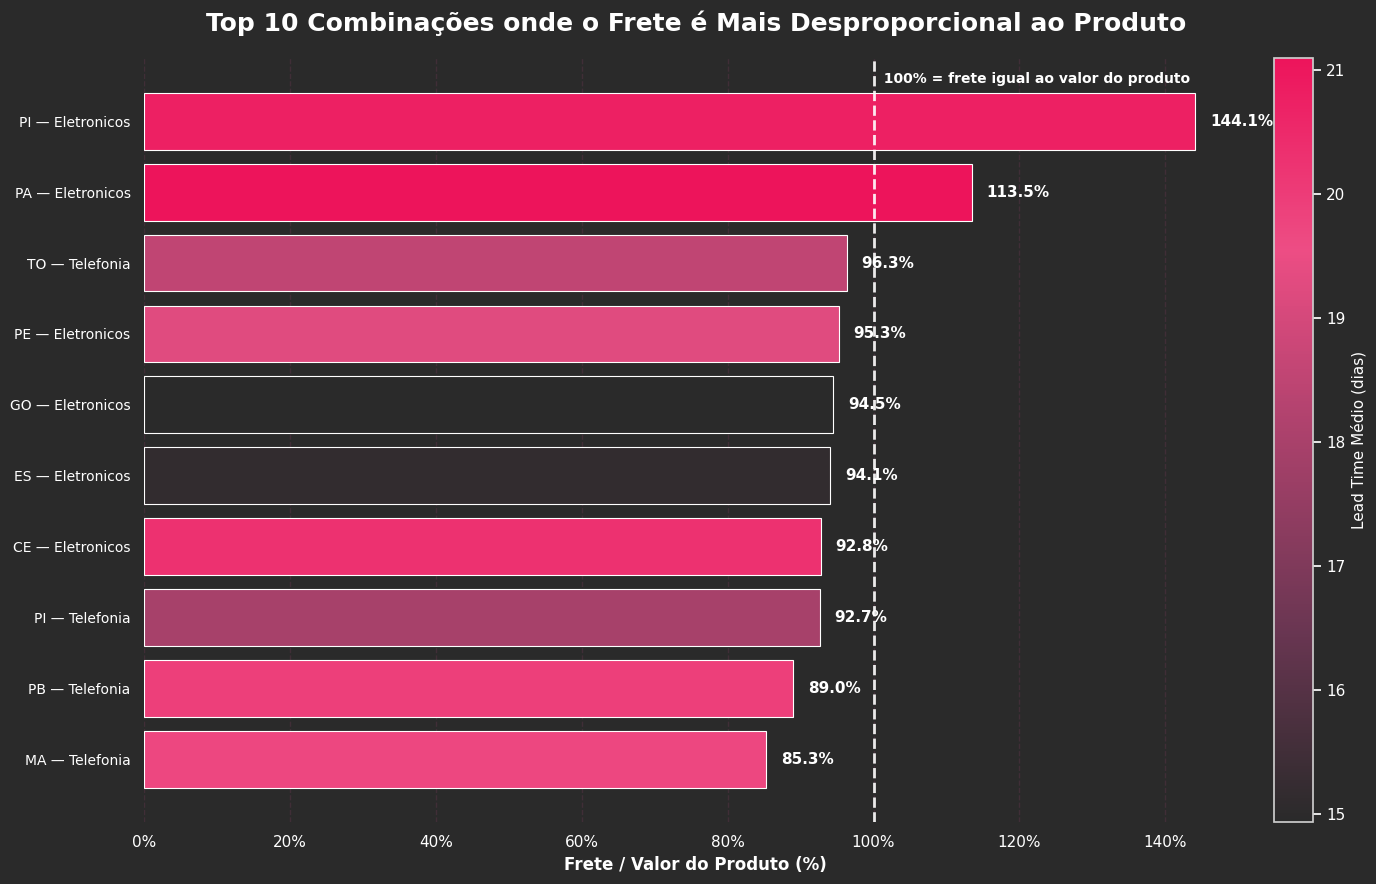

,customer_state,categoria,frete_relativo_medio,lead_time_medio,frete_medio,valor_produto_medio,quantidade_itens
825,PI,Eletronicos,144.10,20.76,33.07,65.77,22
668,PA,Eletronicos,113.48,21.10,33.94,102.71,28
1365,TO,Telefonia,96.34,18.53,29.87,60.39,21
770,PE,Eletronicos,95.27,19.26,22.91,48.07,41
387,GO,Eletronicos,94.48,14.94,17.51,25.90,33
328,ES,Eletronicos,94.07,15.14,20.78,47.04,79
213,CE,Eletronicos,92.75,20.31,27.33,81.93,46
847,PI,Telefonia,92.68,17.95,29.25,75.68,38
742,PB,Telefonia,89.03,19.94,30.32,117.50,27
467,MA,Telefonia,85.31,19.71,27.28,76.95,65


In [297]:
# ============================================================
# TOP 10 COMBINAÇÕES CRÍTICAS — FRETE x VALOR DO PRODUTO
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.ticker as ticker

# ------------------------------------------------------------
# 1. Bases
# ------------------------------------------------------------

df_orders = datasets['orders'].copy()
df_items = datasets['order_items'].copy()
df_products = datasets['products'].copy()
df_customers = datasets['customers'].copy()

# ------------------------------------------------------------
# 2. Identificar colunas de data sem depender de nomes criados
# ------------------------------------------------------------

col_pedido = (
    'dt_pedido' if 'dt_pedido' in df_orders.columns
    else 'order_purchase_timestamp'
)

col_entrega = (
    'dt_entrega' if 'dt_entrega' in df_orders.columns
    else 'order_delivered_customer_date'
)

# ------------------------------------------------------------
# 3. Selecionar informações necessárias
# ------------------------------------------------------------

orders_base = df_orders[
    ['order_id', col_pedido, col_entrega]
].copy()

customers_base = df_customers[
    ['customer_id', 'customer_state']
].copy()

products_base = df_products[
    ['product_id', 'product_category_name']
].copy()

# ------------------------------------------------------------
# 4. Montar base item x pedido x cliente x produto
# ------------------------------------------------------------

base = (
    df_items[
        [
            'order_id',
            'product_id',
            'price',
            'freight_value'
        ]
    ]
    .merge(
        orders_base,
        on='order_id',
        how='left'
    )
    .merge(
        df_orders[['order_id', 'customer_id']],
        on='order_id',
        how='left'
    )
    .merge(
        customers_base,
        on='customer_id',
        how='left'
    )
    .merge(
        products_base,
        on='product_id',
        how='left'
    )
)

# ------------------------------------------------------------
# 5. Tratamento
# ------------------------------------------------------------

base = base.dropna(
    subset=[
        'price',
        'freight_value',
        'customer_state',
        'product_category_name'
    ]
).copy()

# Evitar divisão por zero
base = base[base['price'] > 0].copy()

# ------------------------------------------------------------
# 6. Métricas do item
# ------------------------------------------------------------

# Quanto o frete representa do valor do produto
base['frete_relativo'] = (
    base['freight_value']
    / base['price']
) * 100

# Datas
base[col_pedido] = pd.to_datetime(
    base[col_pedido],
    errors='coerce'
)

base[col_entrega] = pd.to_datetime(
    base[col_entrega],
    errors='coerce'
)

# Lead time
base['lead_time_dias'] = (
    base[col_entrega] - base[col_pedido]
).dt.total_seconds() / 86400

# Remover tempos inválidos
base.loc[
    base['lead_time_dias'] < 0,
    'lead_time_dias'
] = np.nan

# ------------------------------------------------------------
# 7. Nome mais amigável da categoria
# ------------------------------------------------------------

base['categoria'] = (
    base['product_category_name']
    .fillna('Outros')
    .str.replace('_', ' ', regex=False)
    .str.title()
)

# ------------------------------------------------------------
# 8. Agregação Estado x Categoria
# ------------------------------------------------------------

analise_frete = (
    base
    .groupby(
        ['customer_state', 'categoria'],
        as_index=False
    )
    .agg(
        frete_relativo_medio=('frete_relativo', 'mean'),
        frete_mediano=('frete_relativo', 'median'),
        lead_time_medio=('lead_time_dias', 'mean'),
        valor_produto_medio=('price', 'mean'),
        frete_medio=('freight_value', 'mean'),
        quantidade_itens=('product_id', 'count')
    )
)

# ------------------------------------------------------------
# 9. Reduzir ruído estatístico
# ------------------------------------------------------------

# Só considerar combinações com pelo menos 20 itens
analise_frete = analise_frete[
    analise_frete['quantidade_itens'] >= 20
].copy()

# ------------------------------------------------------------
# 10. Selecionar TOP 10
# ------------------------------------------------------------

top10_frete = (
    analise_frete
    .sort_values(
        'frete_relativo_medio',
        ascending=False
    )
    .head(10)
    .copy()
)

# Criar nome para o eixo
top10_frete['grupo'] = (
    top10_frete['customer_state']
    + ' — '
    + top10_frete['categoria']
)

# ------------------------------------------------------------
# 11. Ordenação para gráfico
# ------------------------------------------------------------

top10_frete = top10_frete.sort_values(
    'frete_relativo_medio',
    ascending=True
)

# ------------------------------------------------------------
# 12. Gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(15, 9)
)

fig.patch.set_facecolor(paleta_fiap[0])
ax.set_facecolor(paleta_fiap[0])

# Mapa de cores baseado no lead time
norm = mcolors.Normalize(
    vmin=top10_frete['lead_time_medio'].min(),
    vmax=top10_frete['lead_time_medio'].max()
)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'fiap',
    paleta_fiap
)

cores = cmap(
    norm(top10_frete['lead_time_medio'])
)

# Barras
bars = ax.barh(
    top10_frete['grupo'],
    top10_frete['frete_relativo_medio'],
    color=cores,
    edgecolor='white',
    linewidth=0.8
)

# ------------------------------------------------------------
# 13. Linha crítica = 100%
# ------------------------------------------------------------

ax.axvline(
    100,
    color='white',
    linestyle='--',
    linewidth=2,
    alpha=0.9
)

ax.text(
    100,
    len(top10_frete) - 0.3,
    '  100% = frete igual ao valor do produto',
    color='white',
    fontsize=10,
    fontweight='bold',
    va='top'
)

# ------------------------------------------------------------
# 14. Rótulos
# ------------------------------------------------------------

for bar, (_, row) in zip(
    bars,
    top10_frete.iterrows()
):

    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{row['frete_relativo_medio']:.1f}%",
        va='center',
        color='white',
        fontsize=11,
        fontweight='bold'
    )

# ------------------------------------------------------------
# 15. Formatação
# ------------------------------------------------------------

ax.set_title(
    'Top 10 Combinações onde o Frete é Mais Desproporcional ao Produto',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=20
)

ax.set_xlabel(
    'Frete / Valor do Produto (%)',
    fontsize=12,
    fontweight='bold',
    color='white'
)

ax.set_ylabel(
    '',
    color='white'
)

ax.tick_params(
    axis='x',
    colors='white'
)

ax.tick_params(
    axis='y',
    colors='white',
    labelsize=10
)

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: f'{x:.0f}%'
    )
)

ax.grid(
    axis='x',
    color=paleta_fiap[1],
    linestyle='--',
    alpha=0.35
)

ax.grid(
    axis='y',
    visible=False
)

# ------------------------------------------------------------
# 16. Barra de cor = Lead Time
# ------------------------------------------------------------

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = plt.colorbar(
    sm,
    ax=ax,
    pad=0.02
)

cbar.set_label(
    'Lead Time Médio (dias)',
    color='white',
    fontsize=11
)

cbar.ax.tick_params(
    colors='white'
)

# ------------------------------------------------------------
# 17. Limpeza visual
# ------------------------------------------------------------

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

plt.savefig(
    'top10_frete_critico.png',
    dpi=300,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)

plt.show()

# ------------------------------------------------------------
# 18. Tabela de apoio
# ------------------------------------------------------------

display(
    top10_frete[
        [
            'customer_state',
            'categoria',
            'frete_relativo_medio',
            'lead_time_medio',
            'frete_medio',
            'valor_produto_medio',
            'quantidade_itens'
        ]
    ]
    .sort_values(
        'frete_relativo_medio',
        ascending=False
    )
    .round(2)
)

In [298]:
leadtime_estado = (
    df_logistica_entregue
    .groupby('customer_state')
    .agg(
        pedidos=('order_id', 'nunique'),
        lead_time_medio=('lead_time_dias', 'mean'),
        atraso_medio=('atraso_dias', 'mean'),
        sla_no_prazo=('sla_status', lambda x: (x == 'No prazo').mean() * 100),
        review_medio=('review_score', 'mean')
    )
    .reset_index()
)

display(
    leadtime_estado
    .sort_values('lead_time_medio', ascending=False)
    .round(2)
)

,customer_state,pedidos,lead_time_medio,atraso_medio,sla_no_prazo,review_medio
21,RR,41,29.39,-16.59,87.80,3.90
3,AP,67,27.19,-19.06,95.52,4.24
2,AM,145,26.43,-18.85,95.86,4.24
1,AL,397,24.54,-8.03,76.07,3.85
13,PA,946,23.77,-13.39,87.63,3.91
9,MA,717,21.57,-8.89,80.33,3.83
24,SE,335,21.52,-9.33,84.78,3.91
5,CE,1279,21.27,-10.11,84.68,3.94
0,AC,80,21.04,-20.08,96.25,4.09
14,PB,517,20.43,-12.60,88.97,4.08


#### **g. Frete × Valor do Produto — Onde o custo se torna desproporcional?**


In [299]:
# ============================================================
# II.g — FRETE × VALOR DO PRODUTO
# Onde o custo se torna desproporcional?
# ============================================================

import pandas as pd
import numpy as np
import plotly.express as px

# ------------------------------------------------------------
# Re-establishing necessary dataframes from the global 'datasets' dictionary
# ------------------------------------------------------------
df_orders = datasets['orders'].copy()
df_items = datasets['order_items'].copy()
df_products = datasets['products'].copy()
df_customers = datasets['customers'].copy()
df_product_category_name_translation = datasets['product_category_name_translation'].copy()

# ------------------------------------------------------------
# Identify date columns (assuming df_orders might be standardized or original)
# ------------------------------------------------------------
if 'order_purchase_timestamp' in df_orders.columns:
    col_pedido = 'order_purchase_timestamp'
    col_entrega = 'order_delivered_customer_date'
elif 'dt_pedido' in df_orders.columns:
    col_pedido = 'dt_pedido'
    col_entrega = 'dt_entrega'
else:
    raise KeyError(
        'Não encontrei a coluna de data do pedido.'
    )

# ------------------------------------------------------------
# Convert date columns
# ------------------------------------------------------------
df_orders[col_pedido] = pd.to_datetime(
    df_orders[col_pedido],
    errors='coerce'
)
df_orders[col_entrega] = pd.to_datetime(
    df_orders[col_entrega],
    errors='coerce'
)

# ------------------------------------------------------------
# Build base: item + product + order + customer (df_custo)
# ------------------------------------------------------------
df_custo = (
    df_items[
        [
            'order_id',
            'product_id',
            'price',
            'freight_value'
        ]
    ]
    .merge(
        df_products[
            [
                'product_id',
                'product_category_name'
            ]
        ],
        on='product_id',
        how='left'
    )
    .merge(
        df_orders[
            [
                'order_id',
                'customer_id',
                col_pedido,
                col_entrega
            ]
        ],
        on='order_id',
        how='left'
    )
    .merge(
        df_customers[
            [
                'customer_id',
                'customer_state'
            ]
        ],
        on='customer_id',
        how='left'
    )
)

# ------------------------------------------------------------
# Process category names
# ------------------------------------------------------------
df_custo['categoria'] = (
    df_custo['product_category_name']
    .fillna('Outros')
    .str.replace(
        '_',
        ' ',
        regex=False
    )
    .str.title()
)

# ------------------------------------------------------------
# Calculate Lead Time
# ------------------------------------------------------------
df_custo['lead_time_dias'] = (
    df_custo[col_entrega]
    -
    df_custo[col_pedido]
).dt.total_seconds() / 86400

# ------------------------------------------------------------
# Clean data (remove rows with non-positive price or freight)
# ------------------------------------------------------------
df_custo = df_custo[
    (df_custo['price'] > 0) &
    (df_custo['freight_value'] >= 0)
].copy()

# ------------------------------------------------------------
# Calculate principal indicator: relative freight cost
# ------------------------------------------------------------
df_custo['frete_percentual'] = (
    df_custo['freight_value']
    /
    df_custo['price']
    * 100
)

# ------------------------------------------------------------
# Flag cases where freight is more than product value
# ------------------------------------------------------------
df_custo['frete_maior_produto'] = (
    df_custo['freight_value']
    >
    df_custo['price']
)

# ------------------------------------------------------------
# Define freight criticality level (original code for df_custo includes this)
# ------------------------------------------------------------
df_custo['nivel_frete'] = np.select(
    [
        df_custo['frete_percentual'] > 100,
        df_custo['frete_percentual'] > 50,
        df_custo['frete_percentual'] > 30
    ],
    [
        'Frete > Produto',
        'Frete > 50% do Produto',
        'Frete > 30% do Produto'
    ],
    default='Até 30%'
)

# ------------------------------------------------------------
# Define heatmap_data (aggregation by customer_state and categoria)
# This was previously in cell NMKw1jukC4Tc
# ------------------------------------------------------------
heatmap_data = (
    df_custo
    .groupby(
        [
            'customer_state',
            'categoria'
        ],
        as_index=False
    )
    .agg(
        itens=(
            'order_id',
            'size' # This counts the number of items in the group
        ),
        frete_medio=(
            'freight_value',
            'mean'
        ),
        produto_medio=(
            'price',
            'mean'
        ),
        frete_relativo_medio=(
            'frete_percentual',
            'mean'
        ),
        frete_relativo_mediano=(
            'frete_percentual',
            'median'
        ),
        lead_time_medio=(
            'lead_time_dias',
            'mean'
        ),
        casos_frete_maior_produto=(
            'frete_maior_produto',
            'sum'
        )
    )
)

# ------------------------------------------------------------
# Calculate % of items where freight is greater than product value (optional, but part of original heatmap_data logic)
# ------------------------------------------------------------
heatmap_data['pct_frete_maior_produto'] = (
    heatmap_data['casos_frete_maior_produto']
    /
    heatmap_data['itens']
    * 100
)

# ------------------------------------------------------------
# Filter out combinations with too few items (optional, but part of original heatmap_data logic)
# ------------------------------------------------------------
heatmap_data = heatmap_data[
    heatmap_data['itens'] >= 20
].copy()


# ------------------------------------------------------------
# 1. Base Estado × Categoria (Original code from LzyhlGXiJbkK)
# ------------------------------------------------------------

frete_produto = (
    heatmap_data
    .copy()
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            'customer_state',
            'categoria',
            'frete_relativo_medio',
            'lead_time_medio',
            'itens'
        ]
    )
)

# ------------------------------------------------------------
# 2. Evitar casos isolados
# Mesmo critério utilizado na análise
# ------------------------------------------------------------

frete_produto = frete_produto[
    frete_produto['itens'] >= 20
].copy()

# ------------------------------------------------------------
# 3. Top 10
# ------------------------------------------------------------

top10_frete = (
    frete_produto
    .nlargest(
        10,
        'frete_relativo_medio'
    )
    .copy()
)

# Nome para visualização
top10_frete['grupo'] = (
    top10_frete['customer_state']
    + ' — '
    + top10_frete['categoria']
)

# ------------------------------------------------------------
# 4. Tabela de apoio
# ------------------------------------------------------------

display(
    top10_frete[
        [
            'grupo',
            'itens',
            'frete_relativo_medio',
            'lead_time_medio'
        ]
    ]
    .sort_values(
        'frete_relativo_medio',
        ascending=False
    )
    .style
    .hide(axis='index')
    .format({
        'itens': '{:,.0f}',
        'frete_relativo_medio': '{:.1f}%',
        'lead_time_medio': '{:.1f} dias'
    })
)

# ------------------------------------------------------------
# 5. Gráfico
# ------------------------------------------------------------

fig = px.bar(
    top10_frete.sort_values(
        'frete_relativo_medio'
    ),

    x='frete_relativo_medio',
    y='grupo',

    orientation='h',

    text='frete_relativo_medio',

    color='lead_time_medio',

    color_continuous_scale=paleta_fiap,

    title='Onde o frete supera o valor do produto?'
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside'
)

# ------------------------------------------------------------
# 6. Linha crítica de 100%
# ------------------------------------------------------------

fig.add_vline(
    x=100,
    line_dash='dash',
    line_color='white',
    annotation_text='100% = frete igual ao produto',
    annotation_position='top'
)

fig.update_layout(

    title=dict(
        text='Onde o frete supera o valor do produto?',
        x=0.5,
        font=dict(
            color='white',
            size=18
        )
    ),

    xaxis=dict(
        title='Frete / Valor do Produto (%)',
        title_font=dict(color='white'),
        tickfont=dict(color='white'),
        gridcolor=paleta_fiap[1],
        griddash='dash'
    ),

    yaxis=dict(
        title='',
        tickfont=dict(color='white')
    ),

    coloraxis_colorbar=dict(
        title=dict(
            text='Lead Time Médio<br>(dias)',
            font=dict(color='white')
        ),
        tickfont=dict(color='white')
    ),

    paper_bgcolor='black',
    plot_bgcolor='black',

    font=dict(color='white'),

    margin=dict(
        l=100,
        r=100,
        t=90,
        b=70
    ),

    height=550
)

fig.show()


grupo,itens,frete_relativo_medio,lead_time_medio
PI — Eletronicos,22,144.1%,20.8 dias
PA — Eletronicos,28,113.5%,21.1 dias
TO — Telefonia,21,96.3%,18.5 dias
PE — Eletronicos,41,95.3%,19.3 dias
GO — Eletronicos,33,94.5%,14.9 dias
ES — Eletronicos,79,94.1%,15.1 dias
CE — Eletronicos,46,92.8%,20.3 dias
PI — Telefonia,38,92.7%,18.0 dias
PB — Telefonia,27,89.0%,19.9 dias
MA — Telefonia,65,85.3%,19.7 dias


In [300]:
# ============================================================
# SLIDE 3 — BASE DE CUSTO LOGÍSTICO
# Frete relativo ao valor do produto
# Estado × Categoria
# ============================================================

import pandas as pd
import numpy as np
import plotly.express as px

# ------------------------------------------------------------
# 1. Bases
# ------------------------------------------------------------

df_orders = datasets['orders'].copy()
df_items = datasets['order_items'].copy()
df_products = datasets['products'].copy()
df_customers = datasets['customers'].copy()


# ------------------------------------------------------------
# 2. Identificar automaticamente as colunas de data
# ------------------------------------------------------------

print("Colunas de orders:")
print(df_orders.columns.tolist())


# Se a base ainda estiver com nomes originais do Olist
if 'order_purchase_timestamp' in df_orders.columns:

    col_pedido = 'order_purchase_timestamp'
    col_entrega = 'order_delivered_customer_date'

# Se a base já estiver padronizada
elif 'dt_pedido' in df_orders.columns:

    col_pedido = 'dt_pedido'
    col_entrega = 'dt_entrega'

else:
    raise KeyError(
        "Não foi possível identificar a coluna de data do pedido."
    )


# ------------------------------------------------------------
# 3. Datas
# ------------------------------------------------------------

df_orders[col_pedido] = pd.to_datetime(
    df_orders[col_pedido],
    errors='coerce'
)

df_orders[col_entrega] = pd.to_datetime(
    df_orders[col_entrega],
    errors='coerce'
)


# ------------------------------------------------------------
# 4. Construção da base
# ------------------------------------------------------------

df_custo_logistico = (
    df_items[
        [
            'order_id',
            'product_id',
            'price',
            'freight_value'
        ]
    ]
    .merge(
        df_products[
            [
                'product_id',
                'product_category_name'
            ]
        ],
        on='product_id',
        how='left'
    )
    .merge(
        df_orders[
            [
                'order_id',
                'customer_id',
                col_pedido,
                col_entrega
            ]
        ],
        on='order_id',
        how='left'
    )
    .merge(
        df_customers[
            [
                'customer_id',
                'customer_state'
            ]
        ],
        on='customer_id',
        how='left'
    )
)


# ------------------------------------------------------------
# 5. Lead Time
# ------------------------------------------------------------

df_custo_logistico['lead_time_dias'] = (
    df_custo_logistico[col_entrega]
    - df_custo_logistico[col_pedido]
).dt.total_seconds() / 86400


# ------------------------------------------------------------
# 6. Categoria
# ------------------------------------------------------------

df_custo_logistico['categoria'] = (
    df_custo_logistico['product_category_name']
    .fillna('Outros')
    .str.replace('_', ' ', regex=False)
    .str.title()
)


# ------------------------------------------------------------
# 7. Limpeza
# ------------------------------------------------------------

df_custo_logistico = df_custo_logistico[
    (df_custo_logistico['price'] > 0) &
    (df_custo_logistico['freight_value'] >= 0)
].copy()


# ------------------------------------------------------------
# 8. Agregação
# ------------------------------------------------------------

heatmap_data = (
    df_custo_logistico
    .groupby(
        ['customer_state', 'categoria'],
        as_index=False
    )
    .agg(

        pedidos=('order_id', 'nunique'),

        valor_produtos=('price', 'sum'),

        frete_total=('freight_value', 'sum'),

        valor_medio=('price', 'mean'),

        frete_medio=('freight_value', 'mean'),

        lead_time_medio=('lead_time_dias', 'mean')
    )
)


# ------------------------------------------------------------
# 9. Frete relativo
# ------------------------------------------------------------

heatmap_data['frete_percentual'] = (
    heatmap_data['frete_total']
    /
    heatmap_data['valor_produtos']
    * 100
)


# ------------------------------------------------------------
# 10. Remover combinações com pouco volume
# ------------------------------------------------------------

heatmap_data = heatmap_data[
    heatmap_data['pedidos'] >= 30
].copy()


# ------------------------------------------------------------
# 11. Conferência
# ------------------------------------------------------------

print(
    f"Combinações Estado × Categoria: "
    f"{len(heatmap_data):,}"
)

display(
    heatmap_data
    .sort_values(
        'frete_percentual',
        ascending=False
    )
    .head(15)
    .round(2)
)

Colunas de orders:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Combinações Estado × Categoria: 379


,customer_state,categoria,pedidos,valor_produtos,frete_total,valor_medio,frete_medio,lead_time_medio,frete_percentual
394,GO,Eletronicos,32,854.75,577.78,25.90,17.51,14.94,67.60
784,PE,Eletronicos,37,1971.04,939.11,48.07,22.91,19.26,47.65
334,ES,Eletronicos,73,3716.14,1641.44,47.04,20.78,15.14,44.17
746,PB,Moveis Decoracao,31,4441.71,1819.91,105.76,43.33,22.90,40.97
1258,SE,Esporte Lazer,31,3116.92,1253.59,89.05,35.82,18.88,40.22
787,PE,Fashion Bolsas E Acessorios,34,2336.93,928.55,64.91,25.79,15.75,39.73
156,BA,Eletronicos,98,6252.13,2418.20,57.89,22.39,18.73,38.68
863,PI,Telefonia,35,2875.69,1111.61,75.68,29.25,17.95,38.66
466,MA,Moveis Decoracao,40,4570.36,1759.18,95.22,36.65,21.94,38.49
816,PE,Utilidades Domesticas,55,5380.52,2043.99,89.68,34.07,15.61,37.99


In [301]:
# ============================================================
# ANÁLISE DE CUSTO LOGÍSTICO
# FRETE x VALOR DO PRODUTO
# ============================================================

import pandas as pd
import numpy as np
import plotly.express as px

# ------------------------------------------------------------
# 1. Bases
# ------------------------------------------------------------

df_orders = datasets['orders'].copy()
df_items = datasets['order_items'].copy()
df_products = datasets['products'].copy()
df_customers = datasets['customers'].copy()


# ------------------------------------------------------------
# 2. Identificar as colunas de pedidos
# ------------------------------------------------------------

# Caso a base ainda esteja com os nomes originais do Olist
if 'order_purchase_timestamp' in df_orders.columns:

    col_pedido = 'order_purchase_timestamp'
    col_entrega = 'order_delivered_customer_date'

# Caso você já tenha padronizado as colunas
elif 'dt_pedido' in df_orders.columns:

    col_pedido = 'dt_pedido'
    col_entrega = 'dt_entrega'

else:

    raise KeyError(
        'Não encontrei a coluna de data do pedido.'
    )


# ------------------------------------------------------------
# 3. Converter datas
# ------------------------------------------------------------

df_orders[col_pedido] = pd.to_datetime(
    df_orders[col_pedido],
    errors='coerce'
)

df_orders[col_entrega] = pd.to_datetime(
    df_orders[col_entrega],
    errors='coerce'
)


# ------------------------------------------------------------
# 4. Construir base item + produto + pedido + cliente
# ------------------------------------------------------------

df_custo = (

    df_items[
        [
            'order_id',
            'product_id',
            'price',
            'freight_value'
        ]
    ]

    .merge(

        df_products[
            [
                'product_id',
                'product_category_name'
            ]
        ],

        on='product_id',
        how='left'
    )

    .merge(

        df_orders[
            [
                'order_id',
                'customer_id',
                col_pedido,
                col_entrega
            ]
        ],

        on='order_id',
        how='left'
    )

    .merge(

        df_customers[
            [
                'customer_id',
                'customer_state'
            ]
        ],

        on='customer_id',
        how='left'
    )
)


# ------------------------------------------------------------
# 5. Categoria
# ------------------------------------------------------------

df_custo['categoria'] = (

    df_custo['product_category_name']

    .fillna('Outros')

    .str.replace(
        '_',
        ' ',
        regex=False
    )

    .str.title()
)


# ------------------------------------------------------------
# 6. Lead Time
# ------------------------------------------------------------

df_custo['lead_time_dias'] = (

    df_custo[col_entrega]
    -
    df_custo[col_pedido]

).dt.total_seconds() / 86400


# ------------------------------------------------------------
# 7. Limpeza
# ------------------------------------------------------------

df_custo = df_custo[
    (df_custo['price'] > 0) &
    (df_custo['freight_value'] >= 0)
].copy()


# ------------------------------------------------------------
# 8. INDICADOR PRINCIPAL
# Frete relativo ao valor do produto
# ------------------------------------------------------------

df_custo['frete_percentual'] = (

    df_custo['freight_value']
    /
    df_custo['price']
    * 100
)


# ------------------------------------------------------------
# 9. Flag crítica
# ------------------------------------------------------------

df_custo['frete_maior_produto'] = (

    df_custo['freight_value']
    >
    df_custo['price']
)


# ------------------------------------------------------------
# 10. Faixa de criticidade
# ------------------------------------------------------------

df_custo['nivel_frete'] = np.select(

    [

        df_custo['frete_percentual'] > 100,

        df_custo['frete_percentual'] > 50,

        df_custo['frete_percentual'] > 30

    ],

    [

        'Frete > Produto',

        'Frete > 50% do Produto',

        'Frete > 30% do Produto'

    ],

    default='Até 30%'
)


# ------------------------------------------------------------
# 11. Conferência
# ------------------------------------------------------------

print(
    f'Itens analisados: {len(df_custo):,}'
)

print(
    f'Casos onde o frete supera o produto: '
    f'{df_custo["frete_maior_produto"].sum():,}'
)

print(
    f'Percentual de casos críticos: '
    f'{df_custo["frete_maior_produto"].mean() * 100:.2f}%'
)

display(

    df_custo[
        [
            'order_id',
            'customer_state',
            'categoria',
            'price',
            'freight_value',
            'frete_percentual',
            'lead_time_dias',
            'nivel_frete'
        ]
    ]

    .sort_values(
        'frete_percentual',
        ascending=False
    )

    .head(20)

    .round(2)
)

Itens analisados: 112,650
Casos onde o frete supera o produto: 4,124
Percentual de casos críticos: 3.66%


,order_id,customer_state,categoria,price,freight_value,frete_percentual,lead_time_dias,nivel_frete
87081,c5bdd8ef3c0ec420232e668302179113,SP,Construcao Ferramentas Construcao,0.85,22.30,2623.53,8.16,Frete > Produto
48625,6e864b3f0ec71031117ad4cf46b7f2a1,RJ,Construcao Ferramentas Construcao,0.85,18.23,2144.71,9.97,Frete > Produto
27652,3ee6513ae7ea23bdfab5b9ab60bffcb5,SP,Construcao Ferramentas Construcao,0.85,18.23,2144.71,13.51,Frete > Produto
110535,fb265b2dc558a56445dfc48f8224e201,RS,Beleza Saude,9.90,121.22,1224.44,NaN,Frete > Produto
94495,d642656598ae928a250620315d19e87e,PA,Brinquedos,4.99,37.04,742.28,NaN,Frete > Produto
57312,8272b63d03f5f79c56e9e4120aec44ef,SP,Beleza Saude,1.20,7.89,657.50,14.99,Frete > Produto
57303,8272b63d03f5f79c56e9e4120aec44ef,SP,Beleza Saude,1.20,7.89,657.50,14.99,Frete > Produto
57299,8272b63d03f5f79c56e9e4120aec44ef,SP,Beleza Saude,1.20,7.89,657.50,14.99,Frete > Produto
57297,8272b63d03f5f79c56e9e4120aec44ef,SP,Beleza Saude,1.20,7.89,657.50,14.99,Frete > Produto
57300,8272b63d03f5f79c56e9e4120aec44ef,SP,Beleza Saude,1.20,7.89,657.50,14.99,Frete > Produto


In [302]:
# ============================================================
# CASOS EM QUE O FRETE SUPERA O VALOR DO PRODUTO
# ============================================================

casos_criticos = (

    df_custo[
        df_custo['frete_maior_produto']
    ]

    .groupby(
        [
            'customer_state',
            'categoria'
        ],
        as_index=False
    )

    .agg(

        casos=(
            'order_id',
            'size'
        ),

        frete_relativo_medio=(
            'frete_percentual',
            'mean'
        ),

        frete_relativo_maximo=(
            'frete_percentual',
            'max'
        ),

        lead_time_medio=(
            'lead_time_dias',
            'mean'
        )
    )

    .sort_values(
        [
            'casos',
            'frete_relativo_medio'
        ],
        ascending=False
    )
)


display(
    casos_criticos
    .head(15)
    .round(2)
)

,customer_state,categoria,casos,frete_relativo_medio,frete_relativo_maximo,lead_time_medio
620,SP,Utilidades Domesticas,130,151.58,311.62,8.49
432,RJ,Eletronicos,130,127.86,322.45,17.82
610,SP,Moveis Decoracao,93,130.11,261.02,12.35
582,SP,Beleza Saude,77,273.24,657.50,11.30
223,MG,Eletronicos,73,127.53,283.88,13.61
600,SP,Esporte Lazer,72,160.26,391.11,13.57
234,MG,Moveis Decoracao,59,130.42,254.74,12.32
453,RJ,Utilidades Domesticas,52,154.50,280.30,12.74
584,SP,Cama Mesa Banho,48,139.59,243.07,6.66
54,BA,Eletronicos,47,135.21,202.07,18.37


In [303]:
# ============================================================
# PRIORIZAÇÃO LOGÍSTICA
# ============================================================

priorizacao = (
    heatmap_data
    .groupby('customer_state', as_index=False)
    .agg(
        pedidos=('pedidos', 'sum'),
        lead_time_medio=('lead_time_medio', 'mean'),
        frete_percentual=('frete_percentual', 'mean')
    )
)

# Ranking dos indicadores
priorizacao['rank_lead_time'] = (
    priorizacao['lead_time_medio']
    .rank(method='min', ascending=False)
)

priorizacao['rank_frete'] = (
    priorizacao['frete_percentual']
    .rank(method='min', ascending=False)
)

# Índice combinado
priorizacao['indice_prioridade'] = (
    priorizacao['rank_lead_time']
    + priorizacao['rank_frete']
)

priorizacao = priorizacao.sort_values(
    'indice_prioridade'
)

display(
    priorizacao.round(2)
)

,customer_state,pedidos,lead_time_medio,frete_percentual,rank_lead_time,rank_frete,indice_prioridade
6,MA,500,21.58,27.41,3.0,2.0,5.0
2,CE,1104,20.83,25.84,5.0,4.0,9.0
10,PA,692,23.53,23.74,2.0,7.0,9.0
11,PB,224,20.93,24.29,4.0,6.0,10.0
12,PE,1416,18.03,28.46,9.0,1.0,10.0
19,SE,104,19.21,25.97,7.0,3.0,10.0
13,PI,191,18.90,24.32,8.0,5.0,13.0
1,BA,3091,19.32,22.76,6.0,8.0,14.0
0,AL,164,23.73,17.93,1.0,18.0,19.0
9,MT,674,17.45,21.55,11.0,10.0,21.0


In [304]:
# ============================================================
# ESTADO × CATEGORIA
# ============================================================

heatmap_data = (

    df_custo

    .groupby(
        [
            'customer_state',
            'categoria'
        ],
        as_index=False
    )

    .agg(

        itens=(
            'order_id',
            'size'
        ),

        frete_medio=(
            'freight_value',
            'mean'
        ),

        produto_medio=(
            'price',
            'mean'
        ),

        frete_relativo_medio=(
            'frete_percentual',
            'mean'
        ),

        frete_relativo_mediano=(
            'frete_percentual',
            'median'
        ),

        lead_time_medio=(
            'lead_time_dias',
            'mean'
        ),

        casos_frete_maior_produto=(
            'frete_maior_produto',
            'sum'
        )
    )
)


# ------------------------------------------------------------
# % de itens onde o frete supera o produto
# ------------------------------------------------------------

heatmap_data['pct_frete_maior_produto'] = (

    heatmap_data['casos_frete_maior_produto']
    /
    heatmap_data['itens']
    * 100
)


# ------------------------------------------------------------
# Evitar combinações com pouquíssimos itens
# ------------------------------------------------------------

heatmap_data = heatmap_data[
    heatmap_data['itens'] >= 20
].copy()


display(

    heatmap_data

    .sort_values(
        'frete_relativo_medio',
        ascending=False
    )

    .head(20)

    .round(2)
)

,customer_state,categoria,itens,frete_medio,produto_medio,frete_relativo_medio,frete_relativo_mediano,lead_time_medio,casos_frete_maior_produto,pct_frete_maior_produto
840,PI,Eletronicos,22,33.07,65.77,144.10,147.69,20.76,15,68.18
680,PA,Eletronicos,28,33.94,102.71,113.48,108.89,21.10,15,53.57
1391,TO,Telefonia,21,29.87,60.39,96.34,90.46,18.53,9,42.86
784,PE,Eletronicos,41,22.91,48.07,95.27,98.00,19.26,20,48.78
394,GO,Eletronicos,33,17.51,25.90,94.48,101.28,14.94,17,51.52
334,ES,Eletronicos,79,20.78,47.04,94.07,100.67,15.14,41,51.90
217,CE,Eletronicos,46,27.33,81.93,92.75,90.07,20.31,22,47.83
863,PI,Telefonia,38,29.25,75.68,92.68,81.51,17.95,15,39.47
756,PB,Telefonia,27,30.32,117.50,89.03,81.64,19.94,10,37.04
476,MA,Telefonia,65,27.28,76.95,85.31,81.38,19.71,23,35.38


#### **h. Rotas críticas — Quais devem ser priorizadas?**

In [305]:
# ============================================================
# SLIDE 4 — ROTAS CRÍTICAS
# ============================================================

import pandas as pd
import numpy as np
import plotly.express as px

# ------------------------------------------------------------
# 1. Preparar order_items
# ------------------------------------------------------------

df_items_rota = (
    df_order_items[
        ['order_id', 'seller_id']
    ]
    .drop_duplicates()
)


# ------------------------------------------------------------
# 2. Adicionar estado do vendedor
# ------------------------------------------------------------

df_items_rota = df_items_rota.merge(
    df_sellers[
        ['seller_id', 'seller_state']
    ],
    on='seller_id',
    how='left'
)


# ------------------------------------------------------------
# 3. Utilizar a base logística que você JÁ criou
# ------------------------------------------------------------

df_rotas = df_items_rota.merge(
    df_logistica[
        [
            'order_id',
            'customer_id',
            'customer_state',
            'lead_time_dias',
            'atraso_dias',
            'pedido_entregue'
        ]
    ],
    on='order_id',
    how='inner'
)


# ------------------------------------------------------------
# 4. Considerar somente pedidos entregues
# ------------------------------------------------------------

df_rotas = df_rotas[
    df_rotas['pedido_entregue'] == True
].copy()


# ------------------------------------------------------------
# 5. Criar a rota
# ------------------------------------------------------------

df_rotas['rota'] = (
    df_rotas['seller_state']
    + ' → '
    + df_rotas['customer_state']
)


# ------------------------------------------------------------
# 6. Indicador de atraso
# ------------------------------------------------------------

df_rotas['pedido_atrasado'] = (
    df_rotas['atraso_dias'] > 0
)


# ------------------------------------------------------------
# 7. Consolidar por rota
# ------------------------------------------------------------

rotas = (
    df_rotas
    .groupby(
        ['seller_state', 'customer_state', 'rota'],
        as_index=False
    )
    .agg(
        pedidos=('order_id', 'nunique'),

        lead_time_medio=(
            'lead_time_dias',
            'mean'
        ),

        atraso_medio=(
            'atraso_dias',
            'mean'
        ),

        taxa_atraso=(
            'pedido_atrasado',
            'mean'
        )
    )
)


# ------------------------------------------------------------
# 8. Transformar atraso em %
# ------------------------------------------------------------

rotas['taxa_atraso_pct'] = (
    rotas['taxa_atraso'] * 100
)


# ------------------------------------------------------------
# 9. Retirar rotas com pouco volume
# ------------------------------------------------------------

rotas = rotas[
    rotas['pedidos'] >= 30
].copy()


# ------------------------------------------------------------
# 10. Verificar resultado
# ------------------------------------------------------------

print(
    f'Rotas analisadas: {len(rotas):,}'
)

display(
    rotas.sort_values(
        'lead_time_medio',
        ascending=False
    ).head(10).round(2)
)

Rotas analisadas: 125


,seller_state,customer_state,rota,pedidos,lead_time_medio,atraso_medio,taxa_atraso,taxa_atraso_pct
406,SP,RR,SP → RR,33,31.62,-13.82,0.15,15.15
254,PR,AL,PR → AL,36,29.25,-5.48,0.39,38.89
388,SP,AP,SP → AP,49,28.10,-17.79,0.06,6.12
157,MG,PA,MG → PA,84,27.35,-10.48,0.13,13.10
387,SP,AM,SP → AM,99,25.85,-18.64,0.04,4.04
266,PR,PA,PR → PA,54,25.38,-14.32,0.13,12.96
168,MG,SE,MG → SE,36,25.34,-8.44,0.11,11.11
258,PR,CE,PR → CE,64,25.01,-9.03,0.14,13.85
386,SP,AL,SP → AL,256,25.00,-7.27,0.26,26.07
285,RJ,CE,RJ → CE,54,24.92,-5.74,0.22,22.22


In [306]:
# ============================================================
# II.h — SLIDE 29
# ROTAS CRÍTICAS: TEMPO × ATRASO × VOLUME
# GRÁFICO FINAL — FUNDO PRETO
# ============================================================

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go


# ============================================================
# 1. BASE
# ============================================================

rotas_plot = rotas.copy()


# ============================================================
# 2. GARANTIR MÉTRICAS NUMÉRICAS
# ============================================================

colunas = [
    'lead_time_medio',
    'taxa_atraso_pct',
    'pedidos'
]

for coluna in colunas:

    rotas_plot[coluna] = pd.to_numeric(
        rotas_plot[coluna],
        errors='coerce'
    )


rotas_plot = (
    rotas_plot
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=colunas)
    .copy()
)


# ============================================================
# 3. NORMALIZAÇÃO
# ============================================================

def normalizar(serie):

    if serie.max() == serie.min():

        return pd.Series(
            0.5,
            index=serie.index
        )

    return (
        (serie - serie.min())
        /
        (serie.max() - serie.min())
    )


# ============================================================
# 4. ÍNDICE DE EXPOSIÇÃO
# ============================================================
# Lead Time = 40%
# Atraso    = 40%
# Volume    = 20%
# ============================================================

rotas_plot['indice_exposicao'] = (

    normalizar(
        rotas_plot['lead_time_medio']
    ) * 0.40

    +

    normalizar(
        rotas_plot['taxa_atraso_pct']
    ) * 0.40

    +

    normalizar(
        rotas_plot['pedidos']
    ) * 0.20
)


# ============================================================
# 5. MEDIANAS
# ============================================================

mediana_lead = (
    rotas_plot['lead_time_medio'].median()
)

mediana_atraso = (
    rotas_plot['taxa_atraso_pct'].median()
)


# ============================================================
# 6. ROTAS EXATAS DA APRESENTAÇÃO
# ============================================================

rotas_slide = [
    'SP → AL',
    'SP → MA',
    'PR → BA',
    'MA → SP',
    'SP → PI',
    'SP → PA',
    'SP → SE'
]


# ============================================================
# 7. SELECIONAR AS ROTAS DO SLIDE
# ============================================================

rotas_destacadas = (
    rotas_plot[
        rotas_plot['rota'].isin(rotas_slide)
    ]
    .copy()
)


# ============================================================
# 8. ORDEM EXATA DA APRESENTAÇÃO
# ============================================================

ordem_rotas = {

    'SP → AL': 1,

    'SP → MA': 2,

    'PR → BA': 3,

    'MA → SP': 4,

    'SP → PI': 5,

    'SP → PA': 6,

    'SP → SE': 7
}


rotas_destacadas['ordem'] = (
    rotas_destacadas['rota']
    .map(ordem_rotas)
)


rotas_destacadas = (
    rotas_destacadas
    .sort_values('ordem')
    .copy()
)


# ============================================================
# 9. GRÁFICO
# ============================================================

fig = px.scatter(

    rotas_plot,

    x='lead_time_medio',

    y='taxa_atraso_pct',

    size='pedidos',

    color='indice_exposicao',

    hover_name='rota',

    hover_data={

        'lead_time_medio': ':.1f',

        'taxa_atraso_pct': ':.1f',

        'pedidos': ':,',

        'indice_exposicao': ':.3f'
    },

    color_continuous_scale=paleta_fiap,

    size_max=28,

    labels={

        'lead_time_medio':
            'Lead Time Médio (dias)',

        'taxa_atraso_pct':
            'Taxa de Atraso (%)',

        'pedidos':
            'Volume de Pedidos',

        'indice_exposicao':
            'Exposição'
    }
)


# ============================================================
# 10. BOLHAS DA BASE
# ============================================================

fig.update_traces(

    selector=dict(
        mode='markers'
    ),

    marker=dict(

        opacity=0.40,

        line=dict(
            color='white',
            width=0.4
        )
    )
)


# ============================================================
# 11. MEDIANA — LEAD TIME
# ============================================================

fig.add_vline(

    x=mediana_lead,

    line_dash='dash',

    line_color='white',

    line_width=1.5
)


# ============================================================
# 12. MEDIANA — ATRASO
# ============================================================

fig.add_hline(

    y=mediana_atraso,

    line_dash='dash',

    line_color='white',

    line_width=1.5
)


# ============================================================
# 13. QUADRANTE PRIORITÁRIO
# ============================================================

fig.add_shape(

    type='rect',

    x0=mediana_lead,

    x1=33,

    y0=mediana_atraso,

    y1=40,

    fillcolor=paleta_fiap[4],

    opacity=0.025,

    line_width=0,

    layer='below'
)


# ============================================================
# 14. DESTACAR AS 7 ROTAS
# ============================================================

fig.add_trace(

    go.Scatter(

        x=rotas_destacadas[
            'lead_time_medio'
        ],

        y=rotas_destacadas[
            'taxa_atraso_pct'
        ],

        mode='markers+text',

        text=rotas_destacadas[
            'rota'
        ],

        textposition=[

            'top center',     # SP → AL
            'top center',     # SP → MA
            'bottom center',  # PR → BA
            'top center',     # MA → SP
            'top center',     # SP → PI
            'bottom center',  # SP → PA
            'top center'      # SP → SE
        ],

        textfont=dict(

            color='white',

            size=9
        ),

        marker=dict(

            size=11,

            color=paleta_fiap[4],

            line=dict(

                color='white',

                width=1.3
            )
        ),

        hovertemplate=(

            '<b>%{text}</b><br>'
            'Lead Time: %{x:.1f} dias<br>'
            'Taxa de atraso: %{y:.1f}%<br>'
            '<extra></extra>'
        ),

        showlegend=False
    )
)


# ============================================================
# 15. TEXTO — ROTAS PRIORITÁRIAS
# ============================================================

fig.add_annotation(

    x=26.2,

    y=33,

    text='<b>ROTAS PRIORITÁRIAS</b>',

    showarrow=False,

    font=dict(

        color=paleta_fiap[4],

        size=10
    )
)


# ============================================================
# 16. LAYOUT — FUNDO PRETO
# ============================================================

fig.update_layout(

    title=dict(

        text=(
            'Rotas críticas: onde tempo, atraso '
            'e volume se concentram?'
        ),

        x=0.5,

        xanchor='center',

        y=0.97,

        font=dict(

            color='white',

            size=15
        )
    ),

    # FUNDO PRETO
    paper_bgcolor='black',

    plot_bgcolor='black',

    font=dict(
        color='white'
    ),

    # EIXO X
    xaxis=dict(

        title='Lead Time Médio (dias)',

        range=[4, 33],

        title_font=dict(
            color='white',
            size=12
        ),

        tickfont=dict(
            color='white',
            size=10
        ),

        gridcolor=paleta_fiap[1],

        griddash='dash',

        zeroline=False,

        showline=True,

        linecolor='white',

        linewidth=1
    ),

    # EIXO Y
    yaxis=dict(

        title='Taxa de Atraso (%)',

        range=[0, 41],

        title_font=dict(
            color='white',
            size=12
        ),

        tickfont=dict(
            color='white',
            size=10
        ),

        gridcolor=paleta_fiap[1],

        griddash='dash',

        zeroline=False,

        showline=True,

        linecolor='white',

        linewidth=1
    ),

    # COLORBAR
    coloraxis_colorbar=dict(

        title=dict(

            text='Exposição',

            font=dict(
                color='white',
                size=11
            )
        ),

        tickfont=dict(
            color='white',
            size=9
        ),

        thickness=15,

        len=0.80
    ),

    margin=dict(

        l=65,

        r=80,

        t=60,

        b=60
    ),

    height=520
)


# ============================================================
# 17. EXIBIR
# ============================================================

fig.show()


# ============================================================
# 18. TABELA — MESMAS 7 ROTAS
# ============================================================

tabela_rotas = (
    rotas_destacadas[
        [
            'rota',
            'lead_time_medio',
            'taxa_atraso_pct',
            'pedidos',
            'indice_exposicao'
        ]
    ]
    .rename(columns={

        'rota':
            'Rota',

        'lead_time_medio':
            'Lead Time (dias)',

        'taxa_atraso_pct':
            'Atraso (%)',

        'pedidos':
            'Pedidos',

        'indice_exposicao':
            'Exposição'
    })
)


display(

    tabela_rotas

    .style

    .hide(axis='index')

    .format({

        'Lead Time (dias)': '{:.1f}',

        'Atraso (%)': '{:.1f}%',

        'Pedidos': '{:,.0f}',

        'Exposição': '{:.2f}'
    })
)

Rota,Lead Time (dias),Atraso (%),Pedidos,Exposição
SP → AL,25.0,26.1%,256,0.57
SP → MA,22.1,21.1%,493,0.48
PR → BA,21.9,16.7%,144,0.42
MA → SP,16.1,25.0%,124,0.42
SP → PI,20.3,18.1%,329,0.42
SP → PA,23.3,13.2%,683,0.41
SP → SE,21.3,16.2%,208,0.41


#### **i. Diagnóstico integrado — Onde tempo, custo e satisfação se encontram?**

In [307]:
###########CONSILIDADEO# ============================================================
# SLIDE 30 — DIAGNÓSTICO INTEGRADO
# Onde tempo, custo e satisfação se encontram?
#
# X = Frete / Valor do Produto
# Y = Dias de atraso
# Bolha = Volume de pedidos
# Cor = Média de avaliação
# ============================================================

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go


# ============================================================
# 1. PREPARAÇÃO DA BASE
# ============================================================

base30 = rotas_analise.copy()

# Evitar combinações com pouco volume
base30 = base30[
    base30['total_pedidos'] >= 10
].copy()

cols = [
    'frete_percentual_medio',
    'atraso_medio_dias',
    'total_pedidos',
    'review_medio'
]

for c in cols:
    base30[c] = pd.to_numeric(
        base30[c],
        errors='coerce'
    )

base30 = base30.dropna(
    subset=cols
).copy()


# ============================================================
# 2. CONSIDERAR SOMENTE ATRASOS REAIS
# ============================================================

base30 = base30[
    base30['atraso_medio_dias'] > 0
].copy()


# ============================================================
# 3. MEDIANAS
# ============================================================

mediana_frete = (
    base30['frete_percentual_medio'].median()
)

mediana_atraso = (
    base30['atraso_medio_dias'].median()
)

mediana_review = (
    base30['review_medio'].median()
)


# ============================================================
# 4. ÍNDICE DE EXPOSIÇÃO
#
# Maior frete  = 40%
# Maior atraso = 40%
# Menor review = 20%
# ============================================================

def normalizar(s):

    if s.max() == s.min():
        return pd.Series(
            0.5,
            index=s.index
        )

    return (
        (s - s.min()) /
        (s.max() - s.min())
    )


base30['score_frete'] = normalizar(
    base30['frete_percentual_medio']
)

base30['score_atraso'] = normalizar(
    base30['atraso_medio_dias']
)

# Para review, quanto MENOR a avaliação,
# maior a exposição
base30['score_review'] = 1 - normalizar(
    base30['review_medio']
)


base30['indice_exposicao'] = (

    base30['score_frete'] * 0.40

    +

    base30['score_atraso'] * 0.40

    +

    base30['score_review'] * 0.20
)


# ============================================================
# 5. TOP 7 COMBINAÇÕES PRIORITÁRIAS
# ============================================================

prioridades30 = (

    base30[
        (base30['frete_percentual_medio'] >= mediana_frete) &
        (base30['atraso_medio_dias'] >= mediana_atraso)
    ]

    .nlargest(
        7,
        'indice_exposicao'
    )

    .copy()
)


# ============================================================
# 6. GRÁFICO
# ============================================================

fig = px.scatter(

    base30,

    x='frete_percentual_medio',

    y='atraso_medio_dias',

    size='total_pedidos',

    color='review_medio',

    hover_name='product_category_name_final',

    hover_data={

        'seller_state': True,

        'customer_state': True,

        'frete_percentual_medio': ':.1f',

        'atraso_medio_dias': ':.1f',

        'total_pedidos': ':,',

        'review_medio': ':.2f',

        'indice_exposicao': ':.2f'
    },

    color_continuous_scale=paleta_fiap,

    size_max=26,

    labels={

        'frete_percentual_medio':
            'Frete / Valor do Produto (%)',

        'atraso_medio_dias':
            'Dias de Atraso',

        'total_pedidos':
            'Volume de Pedidos',

        'review_medio':
            'Média de Avaliação'
    }
)


# ============================================================
# 7. BOLHAS
# ============================================================

fig.update_traces(

    marker=dict(

        opacity=0.55,

        line=dict(

            color='white',

            width=0.5
        )
    )
)


# ============================================================
# 8. LINHA DE MEDIANA — FRETE
# ============================================================

fig.add_vline(

    x=mediana_frete,

    line_dash='dash',

    line_color='white',

    line_width=2,

    opacity=0.8
)


# ============================================================
# 9. LINHA DE MEDIANA — ATRASO
# ============================================================

fig.add_hline(

    y=mediana_atraso,

    line_dash='dash',

    line_color='white',

    line_width=2,

    opacity=0.8
)


# ============================================================
# 10. QUADRANTE DE PRIORIDADE
# ============================================================

fig.add_shape(

    type='rect',

    x0=mediana_frete,

    x1=base30[
        'frete_percentual_medio'
    ].max() * 1.03,

    y0=mediana_atraso,

    y1=base30[
        'atraso_medio_dias'
    ].max() * 1.05,

    fillcolor=paleta_fiap[4],

    opacity=0.025,

    line=dict(

        color=paleta_fiap[4],

        width=1
    ),

    layer='below'
)


# ============================================================
# 11. TEXTO DO QUADRANTE
# ============================================================

fig.add_annotation(

    x=(
        mediana_frete
        +
        (
            base30['frete_percentual_medio'].max()
            -
            mediana_frete
        ) * 0.65
    ),

    y=(
        mediana_atraso
        +
        (
            base30['atraso_medio_dias'].max()
            -
            mediana_atraso
        ) * 0.80
    ),

    text=(
        '<b>PRIORIDADE LOGÍSTICA</b><br>'
        'Alto custo + maior atraso'
    ),

    showarrow=False,

    align='center',

    font=dict(

        color=paleta_fiap[4],

        size=11
    )
)


# ============================================================
# 12. DESTACAR TOP 7
# ============================================================

fig.add_trace(

    go.Scatter(

        x=prioridades30[
            'frete_percentual_medio'
        ],

        y=prioridades30[
            'atraso_medio_dias'
        ],

        mode='markers+text',

        text=(

            prioridades30['seller_state']
            + ' → '
            + prioridades30['customer_state']
        ),

        textposition='top center',

        textfont=dict(

            color='white',

            size=9
        ),

        marker=dict(

            size=13,

            color=paleta_fiap[4],

            line=dict(

                color='white',

                width=1.5
            )
        ),

        showlegend=False
    )
)


# ============================================================
# 13. LAYOUT FIAP
# ============================================================

fig.update_layout(

    title=dict(

        text='Onde tempo, custo e satisfação se encontram?',

        x=0.5,

        font=dict(

            color='white',

            size=19
        )
    ),

    xaxis=dict(

        title='Frete / Valor do Produto (%)',

        tickfont=dict(
            color='white'
        ),

        title_font=dict(
            color='white'
        ),

        gridcolor=paleta_fiap[1],

        griddash='dash',

        showgrid=True,

        zeroline=False
    ),

    yaxis=dict(

        title='Dias de Atraso',

        tickfont=dict(
            color='white'
        ),

        title_font=dict(
            color='white'
        ),

        gridcolor=paleta_fiap[1],

        griddash='dash',

        showgrid=True,

        zeroline=True,

        zerolinecolor='white'
    ),

    coloraxis_colorbar=dict(

        title=dict(

            text='Média de<br>Avaliação',

            font=dict(
                color='white'
            )
        ),

        tickfont=dict(
            color='white'
        )
    ),

    plot_bgcolor='black',

    paper_bgcolor='black',

    font=dict(
        color='white'
    ),

    margin=dict(

        l=80,

        r=100,

        t=80,

        b=75
    ),

    height=600
)


# ============================================================
# 14. EXIBIR
# ============================================================

fig.show()


# ============================================================
# 15. TABELA — PRIORIDADES
# ============================================================

tabela_slide30 = (

    prioridades30[

        [
            'seller_state',
            'customer_state',
            'product_category_name_final',
            'total_pedidos',
            'atraso_medio_dias',
            'frete_percentual_medio',
            'review_medio',
            'indice_exposicao'
        ]
    ]

    .sort_values(
        'indice_exposicao',
        ascending=False
    )

    .round(2)
)

display(tabela_slide30)

,seller_state,customer_state,product_category_name_final,total_pedidos,atraso_medio_dias,frete_percentual_medio,review_medio,indice_exposicao
4409,SP,SE,auto,12,10.12,68.26,3.58,0.85
717,MG,BA,toys,10,6.03,32.62,3.33,0.37


####j.  Top 10 Combinações Críticas — FRETE x VALOR DO PRODUTO

ANÁLISE DIAGNÓSTICA

In [308]:
# ============================================================
# SLIDE 4 — ROTAS CRÍTICAS
# ============================================================

import pandas as pd
import numpy as np
import plotly.express as px

# ------------------------------------------------------------
# 1. Preparar order_items
# ------------------------------------------------------------

df_items_rota = (
    df_order_items[
        ['order_id', 'seller_id']
    ]
    .drop_duplicates()
)


# ------------------------------------------------------------
# 2. Adicionar estado do vendedor
# ------------------------------------------------------------

df_items_rota = df_items_rota.merge(
    df_sellers[
        ['seller_id', 'seller_state']
    ],
    on='seller_id',
    how='left'
)


# ------------------------------------------------------------
# 3. Utilizar a base logística que você JÁ criou
# ------------------------------------------------------------

df_rotas = df_items_rota.merge(
    df_logistica[
        [
            'order_id',
            'customer_id',
            'customer_state',
            'lead_time_dias',
            'atraso_dias',
            'pedido_entregue'
        ]
    ],
    on='order_id',
    how='inner'
)


# ------------------------------------------------------------
# 4. Considerar somente pedidos entregues
# ------------------------------------------------------------

df_rotas = df_rotas[
    df_rotas['pedido_entregue'] == True
].copy()


# ------------------------------------------------------------
# 5. Criar a rota
# ------------------------------------------------------------

df_rotas['rota'] = (
    df_rotas['seller_state']
    + ' → '
    + df_rotas['customer_state']
)


# ------------------------------------------------------------
# 6. Indicador de atraso
# ------------------------------------------------------------

df_rotas['pedido_atrasado'] = (
    df_rotas['atraso_dias'] > 0
)


# ------------------------------------------------------------
# 7. Consolidar por rota
# ------------------------------------------------------------

rotas = (
    df_rotas
    .groupby(
        ['seller_state', 'customer_state', 'rota'],
        as_index=False
    )
    .agg(
        pedidos=('order_id', 'nunique'),

        lead_time_medio=(
            'lead_time_dias',
            'mean'
        ),

        atraso_medio=(
            'atraso_dias',
            'mean'
        ),

        taxa_atraso=(
            'pedido_atrasado',
            'mean'
        )
    )
)


# ------------------------------------------------------------
# 8. Transformar atraso em %
# ------------------------------------------------------------

rotas['taxa_atraso_pct'] = (
    rotas['taxa_atraso'] * 100
)


# ------------------------------------------------------------
# 9. Retirar rotas com pouco volume
# ------------------------------------------------------------

rotas = rotas[
    rotas['pedidos'] >= 30
].copy()


# ------------------------------------------------------------
# 10. Verificar resultado
# ------------------------------------------------------------

print(
    f'Rotas analisadas: {len(rotas):,}'
)

display(
    rotas.sort_values(
        'lead_time_medio',
        ascending=False
    ).head(10).round(2)
)

Rotas analisadas: 125


,seller_state,customer_state,rota,pedidos,lead_time_medio,atraso_medio,taxa_atraso,taxa_atraso_pct
406,SP,RR,SP → RR,33,31.62,-13.82,0.15,15.15
254,PR,AL,PR → AL,36,29.25,-5.48,0.39,38.89
388,SP,AP,SP → AP,49,28.10,-17.79,0.06,6.12
157,MG,PA,MG → PA,84,27.35,-10.48,0.13,13.10
387,SP,AM,SP → AM,99,25.85,-18.64,0.04,4.04
266,PR,PA,PR → PA,54,25.38,-14.32,0.13,12.96
168,MG,SE,MG → SE,36,25.34,-8.44,0.11,11.11
258,PR,CE,PR → CE,64,25.01,-9.03,0.14,13.85
386,SP,AL,SP → AL,256,25.00,-7.27,0.26,26.07
285,RJ,CE,RJ → CE,54,24.92,-5.74,0.22,22.22


In [309]:
df_atraso_review = (
    df_logistica_entregue[
        [
            'order_id',
            'atraso_dias',
            'lead_time_dias',
            'review_score'
        ]
    ]
    .dropna(
        subset=['atraso_dias', 'review_score']
    )
    .copy()
)

# Faixas de atraso
df_atraso_review['faixa_atraso'] = pd.cut(
    df_atraso_review['atraso_dias'],
    bins=[
        -np.inf,
        0,
        1,
        3,
        7,
        np.inf
    ],
    labels=[
        'No prazo / antecipado',
        'Até 1 dia',
        '1–3 dias',
        '3–7 dias',
        '> 7 dias'
    ]
)

review_atraso = (
    df_atraso_review
    .groupby(
        'faixa_atraso',
        observed=False
    )
    .agg(
        pedidos=('order_id', 'nunique'),
        review_medio=('review_score', 'mean')
    )
    .reset_index()
)

review_atraso['review_medio'] = (
    review_atraso['review_medio']
    .round(2)
)

display(review_atraso)

,faixa_atraso,pedidos,review_medio
0,No prazo / antecipado,88168,4.29
1,Até 1 dia,1280,4.04
2,1–3 dias,1356,3.51
3,3–7 dias,1773,2.32
4,> 7 dias,3253,1.73


In [310]:
# ============================================================
# CORRELAÇÃO — ATRASO × REVIEW
# ============================================================

correlacao_atraso_review = (
    df_atraso_review[
        ['atraso_dias', 'review_score']
    ]
    .corr()
)

display(
    correlacao_atraso_review.round(3)
)

print(
    f"Correlação entre atraso e review_score: "
    f"{correlacao_atraso_review.loc['atraso_dias', 'review_score']:.3f}"
)

,atraso_dias,review_score
atraso_dias,1.000,-0.267
review_score,-0.267,1.000


Correlação entre atraso e review_score: -0.267


In [311]:
import pandas as pd
import numpy as np

# ============================================================
# 5.5 REGIÃO × SLA × FRETE
# ============================================================

# Ensure 'frete_percentual' is calculated in df_custo_logistico
# This calculation is needed before grouping by customer_state
# df_custo_logistico is assumed to be prepared in previous cells (e.g., K_uxnNQoBDWU)
df_custo_logistico['frete_percentual'] = (
    df_custo_logistico['freight_value'] / df_custo_logistico['price'] * 100
)
# Handle potential division by zero if 'price' can be 0, resulting in inf or NaN
df_custo_logistico['frete_percentual'] = df_custo_logistico['frete_percentual'].replace([np.inf, -np.inf], np.nan)
# Drop rows where frete_percentual is NaN if needed, or fillna appropriately
df_custo_logistico.dropna(subset=['frete_percentual'], inplace=True)


# 1. Aggregate freight data from df_custo_logistico by state
frete_por_estado = df_custo_logistico.groupby('customer_state').agg(
    frete_medio=('freight_value', 'mean'),
    frete_percentual=('frete_percentual', 'mean')
).reset_index()

# 2. Aggregate SLA and other logistical metrics from df_logistica by state
# df_logistica is assumed to be prepared in previous cells (e.g., EtKzoBxamIqz)
logistica_por_estado = df_logistica.groupby('customer_state').agg(
    sla=('sla_status', lambda x: (x == 'No prazo').mean() * 100), # Percentage of orders 'No prazo'
    pedidos=('order_id', 'nunique'), # Count unique orders
    lead_time=('lead_time_dias', 'mean') # Mean lead time
).reset_index()

# 3. Merge the aggregated dataframes to create regiao_diagnostico
regiao_diagnostico = frete_por_estado.merge(logistica_por_estado, on='customer_state', how='left')

# Ensure all numeric columns are handled properly (e.g., fillna for NaN values from merges)
for col in ['frete_medio', 'frete_percentual', 'sla', 'pedidos', 'lead_time']:
    regiao_diagnostico[col] = regiao_diagnostico[col].fillna(0)

# Sort the final DataFrame
regiao_diagnostico = regiao_diagnostico.sort_values(
    'frete_medio',
    ascending=False
)

display(
    regiao_diagnostico.round(2)
)

,customer_state,frete_medio,frete_percentual,sla,pedidos,lead_time
21,RR,42.98,58.90,78.26,46,29.39
14,PB,42.72,51.16,85.82,536,20.43
20,RO,41.07,59.42,93.28,253,19.37
0,AC,40.07,51.17,95.06,81,21.04
16,PI,39.15,49.98,80.81,495,19.46
9,MA,38.26,54.93,77.11,747,21.57
26,TO,37.25,49.95,85.36,280,17.66
24,SE,36.65,46.49,81.14,350,21.52
1,AL,35.84,47.45,73.12,413,24.54
13,PA,35.83,47.36,85.03,975,23.77


In [312]:
# ============================================================
# TOP EXPOSIÇÕES — Slide 30
# ============================================================

top_exposicoes = (
    base30
    .sort_values(
        ['atraso_medio_dias', 'frete_percentual_medio'],
        ascending=False
    )
    .head(10)
)

display(
    top_exposicoes[
        [
            'seller_state',
            'customer_state',
            'product_category_name_final',
            'total_pedidos',
            'atraso_medio_dias',
            'frete_percentual_medio',
            'review_medio'
        ]
    ]
    .style
    .format({
        'total_pedidos': '{:,.0f}',
        'atraso_medio_dias': '{:.1f}',
        'frete_percentual_medio': '{:.1f}%',
        'review_medio': '{:.2f}'
    })
    .set_caption(
        'Principais Exposições — Tempo × Custo × Satisfação'
    )
)

,seller_state,customer_state,product_category_name_final,total_pedidos,atraso_medio_dias,frete_percentual_medio,review_medio
4409,SP,SE,auto,12,10.1,68.3%,3.58
717,MG,BA,toys,10,6.0,32.6%,3.33
2388,RJ,SP,electronics,10,3.6,26.9%,4.09
1599,PR,MG,bed_bath_table,13,2.5,29.0%,2.21
694,MG,BA,cool_stuff,13,1.0,30.5%,4.07
2047,RJ,CE,watches_gifts,13,0.5,27.2%,2.93


In [313]:
# ============================================================
# SLIDE 4 — ROTAS CRÍTICAS
# ============================================================

import pandas as pd
import numpy as np
import plotly.express as px

# ------------------------------------------------------------
# 1. Preparar order_items
# ------------------------------------------------------------

df_items_rota = (
    df_order_items[
        ['order_id', 'seller_id']
    ]
    .drop_duplicates()
)


# ------------------------------------------------------------
# 2. Adicionar estado do vendedor
# ------------------------------------------------------------

df_items_rota = df_items_rota.merge(
    df_sellers[
        ['seller_id', 'seller_state']
    ],
    on='seller_id',
    how='left'
)


# ------------------------------------------------------------
# 3. Utilizar a base logística que você JÁ criou
# ------------------------------------------------------------

df_rotas = df_items_rota.merge(
    df_logistica[
        [
            'order_id',
            'customer_id',
            'customer_state',
            'lead_time_dias',
            'atraso_dias',
            'pedido_entregue'
        ]
    ],
    on='order_id',
    how='inner'
)


# ------------------------------------------------------------
# 4. Considerar somente pedidos entregues
# ------------------------------------------------------------

df_rotas = df_rotas[
    df_rotas['pedido_entregue'] == True
].copy()


# ------------------------------------------------------------
# 5. Criar a rota
# ------------------------------------------------------------

df_rotas['rota'] = (
    df_rotas['seller_state']
    + ' → '
    + df_rotas['customer_state']
)


# ------------------------------------------------------------
# 6. Indicador de atraso
# ------------------------------------------------------------

df_rotas['pedido_atrasado'] = (
    df_rotas['atraso_dias'] > 0
)


# ------------------------------------------------------------
# 7. Consolidar por rota
# ------------------------------------------------------------

rotas = (
    df_rotas
    .groupby(
        ['seller_state', 'customer_state', 'rota'],
        as_index=False
    )
    .agg(
        pedidos=('order_id', 'nunique'),

        lead_time_medio=(
            'lead_time_dias',
            'mean'
        ),

        atraso_medio=(
            'atraso_dias',
            'mean'
        ),

        taxa_atraso=(
            'pedido_atrasado',
            'mean'
        )
    )
)


# ------------------------------------------------------------
# 8. Transformar atraso em %
# ------------------------------------------------------------

rotas['taxa_atraso_pct'] = (
    rotas['taxa_atraso'] * 100
)


# ------------------------------------------------------------
# 9. Retirar rotas com pouco volume
# ------------------------------------------------------------

rotas = rotas[
    rotas['pedidos'] >= 30
].copy()


# ------------------------------------------------------------
# 10. Verificar resultado
# ------------------------------------------------------------

print(
    f'Rotas analisadas: {len(rotas):,}'
)

display(
    rotas.sort_values(
        'lead_time_medio',
        ascending=False
    ).head(10).round(2)
)

Rotas analisadas: 125


,seller_state,customer_state,rota,pedidos,lead_time_medio,atraso_medio,taxa_atraso,taxa_atraso_pct
406,SP,RR,SP → RR,33,31.62,-13.82,0.15,15.15
254,PR,AL,PR → AL,36,29.25,-5.48,0.39,38.89
388,SP,AP,SP → AP,49,28.10,-17.79,0.06,6.12
157,MG,PA,MG → PA,84,27.35,-10.48,0.13,13.10
387,SP,AM,SP → AM,99,25.85,-18.64,0.04,4.04
266,PR,PA,PR → PA,54,25.38,-14.32,0.13,12.96
168,MG,SE,MG → SE,36,25.34,-8.44,0.11,11.11
258,PR,CE,PR → CE,64,25.01,-9.03,0.14,13.85
386,SP,AL,SP → AL,256,25.00,-7.27,0.26,26.07
285,RJ,CE,RJ → CE,54,24.92,-5.74,0.22,22.22


### **III. Comportamento e Pagamentos**

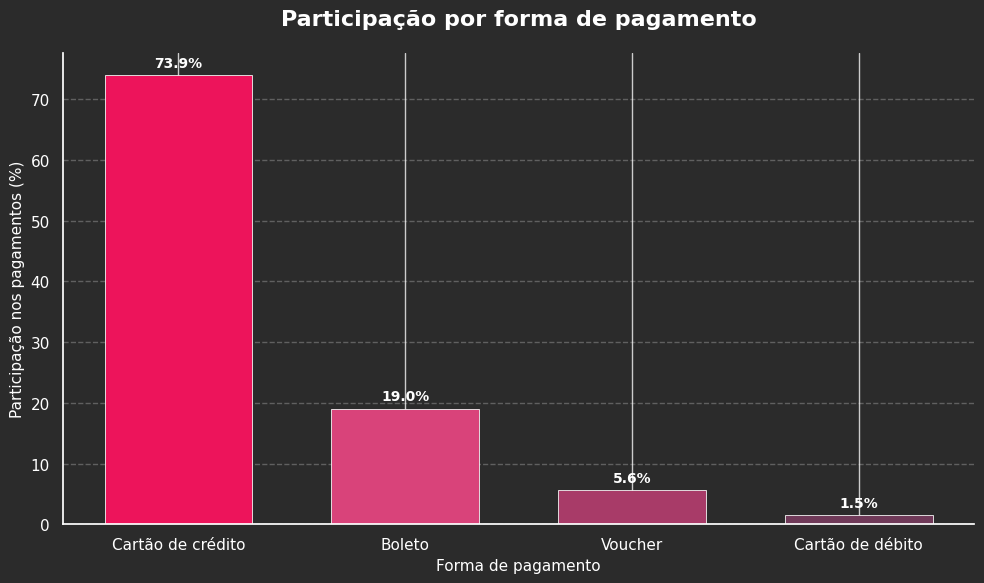

In [314]:
forma_pagamento = (
    pagamentos["payment_type"]
    .value_counts(normalize=True)
    .mul(100)
    .drop("not_defined", errors="ignore")
    .sort_values(ascending=False)
)

forma_pagamento = forma_pagamento.rename({
    "credit_card": "Cartão de crédito",
    "boleto": "Boleto",
    "voucher": "Voucher",
    "debit_card": "Cartão de débito"
})

cores_fiap = [
    "#ED145B",
    "#D9437A",
    "#A83B68",
    "#703A59"
]

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#2B2B2B")
ax.set_facecolor("#2B2B2B")

barras = ax.bar(
    forma_pagamento.index,
    forma_pagamento.values,
    color=cores_fiap,
    edgecolor="#F5F5F5",
    linewidth=0.6,
    width=0.65
)

ax.set_title(
    "Participação por forma de pagamento",
    fontsize=16,
    fontweight="bold",
    color="white",
    pad=20
)

ax.set_xlabel(
    "Forma de pagamento",
    fontsize=11,
    color="white"
)

ax.set_ylabel(
    "Participação nos pagamentos (%)",
    fontsize=11,
    color="white"
)

ax.tick_params(
    axis="x",
    colors="white",
    labelrotation=0
)

ax.tick_params(
    axis="y",
    colors="white"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
    color="white"
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("white")
ax.spines["bottom"].set_color("white")

ax.bar_label(
    barras,
    fmt="%.1f%%",
    padding=4,
    color="white",
    fontsize=10,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

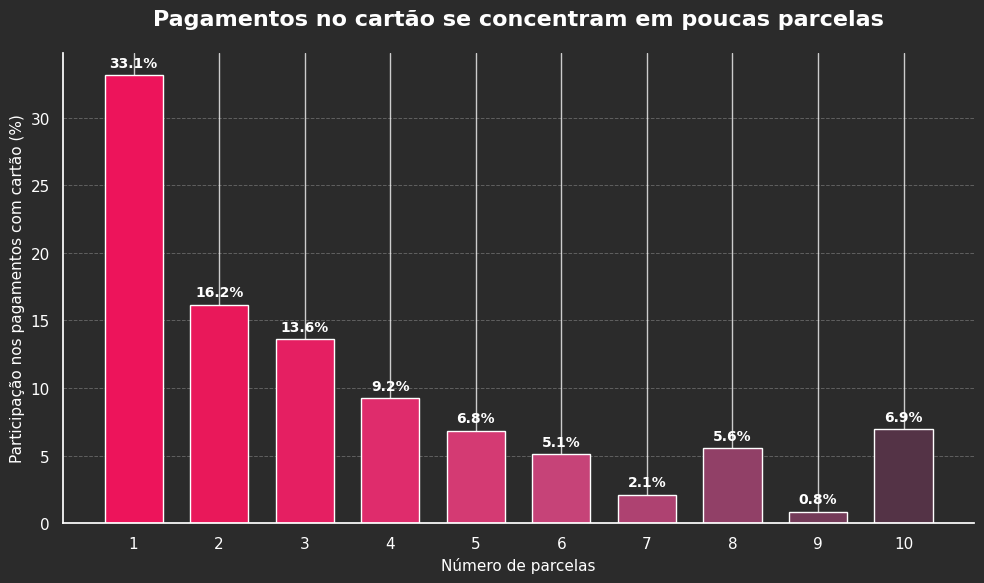

In [315]:
filtro_cartao = pagamentos["payment_type"] == "credit_card"

parcelamento = (
    pagamentos[filtro_cartao]["payment_installments"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
)

parcelamento = parcelamento[
    parcelamento.index.isin(range(1, 11))
]

cores_fiap = [
    "#ED145B",
    "#E9185A",
    "#E51F62",
    "#DF2C6C",
    "#D43A73",
    "#C64378",
    "#AE4271",
    "#914067",
    "#743B59",
    "#543346"
]

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#2B2B2B")
ax.set_facecolor("#2B2B2B")

barras = ax.bar(
    parcelamento.index.astype(str),
    parcelamento.values,
    color=cores_fiap,
    width=0.68
)

ax.set_title(
    "Pagamentos no cartão se concentram em poucas parcelas",
    fontsize=16,
    fontweight="bold",
    color="white",
    pad=20
)

ax.set_xlabel(
    "Número de parcelas",
    fontsize=11,
    color="white"
)

ax.set_ylabel(
    "Participação nos pagamentos com cartão (%)",
    fontsize=11,
    color="white"
)

ax.tick_params(
    axis="x",
    colors="white"
)

ax.tick_params(
    axis="y",
    colors="white"
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
    color="white"
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("white")
ax.spines["bottom"].set_color("white")

ax.bar_label(
    barras,
    fmt="%.1f%%",
    padding=4,
    color="white",
    fontsize=10,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

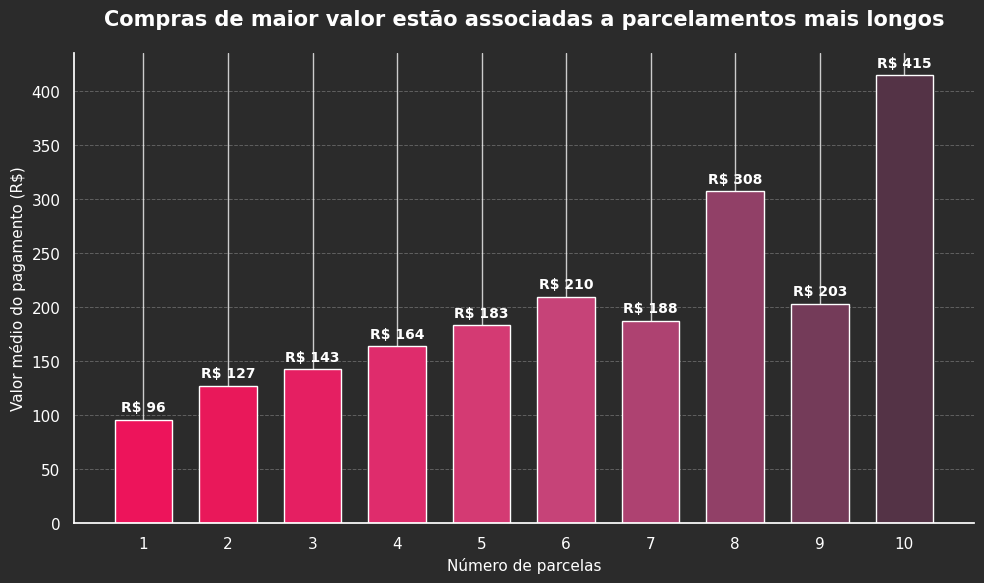

In [316]:
quantidade_por_parcela = (
    pagamentos[filtro_cartao]["payment_installments"]
    .value_counts()
)

parcelas_relevantes = (
    quantidade_por_parcela[
        quantidade_por_parcela >= 500
    ]
    .index
    .sort_values()
)

filtro_parcelas = pagamentos["payment_installments"].isin(
    parcelas_relevantes
)

filtro_analise = filtro_cartao & filtro_parcelas

media_por_parcela = (
    pagamentos[filtro_analise]
    .groupby("payment_installments")["payment_value"]
    .mean()
)

cores_fiap = [
    "#ED145B",
    "#E9185A",
    "#E51F62",
    "#DF2C6C",
    "#D43A73",
    "#C64378",
    "#AE4271",
    "#914067",
    "#743B59",
    "#543346"
]

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#2B2B2B")
ax.set_facecolor("#2B2B2B")

barras = ax.bar(
    media_por_parcela.index.astype(str),
    media_por_parcela.values,
    color=cores_fiap[:len(media_por_parcela)],
    width=0.68
)

ax.set_title(
    "Compras de maior valor estão associadas a parcelamentos mais longos",
    fontsize=15,
    fontweight="bold",
    color="white",
    pad=20
)

ax.set_xlabel(
    "Número de parcelas",
    fontsize=11,
    color="white"
)

ax.set_ylabel(
    "Valor médio do pagamento (R$)",
    fontsize=11,
    color="white"
)

ax.tick_params(
    axis="x",
    colors="white"
)

ax.tick_params(
    axis="y",
    colors="white"
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
    color="white"
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("white")
ax.spines["bottom"].set_color("white")

ax.bar_label(
    barras,
    labels=[
        f"R$ {valor:.0f}"
        for valor in media_por_parcela.values
    ],
    padding=4,
    color="white",
    fontsize=10,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#### **a. Recência, Frequência e Monetização — RFM por customer_unique_id**

In [317]:
pedidos = datasets["orders"].copy()
clientes = datasets["customers"].copy()
pagamentos = datasets["payments"].copy()

pedidos["order_purchase_timestamp"] = pd.to_datetime(
    pedidos["order_purchase_timestamp"]
)

valor_por_pedido = (
    pagamentos
    .groupby("order_id", as_index=False)["payment_value"]
    .sum()
)

base_rfm = (
    pedidos[
        ["order_id", "customer_id", "order_purchase_timestamp"]
    ]
    .merge(
        clientes[
            ["customer_id", "customer_unique_id"]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        valor_por_pedido,
        on="order_id",
        how="left"
    )
)

data_referencia = (
    base_rfm["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

rfm = (
    base_rfm
    .groupby("customer_unique_id")
    .agg(
        ultima_compra=("order_purchase_timestamp", "max"),
        frequencia=("order_id", "nunique"),
        monetizacao=("payment_value", "sum")
    )
    .reset_index()
)

rfm["recencia"] = (
    data_referencia - rfm["ultima_compra"]
).dt.days

rfm[["recencia", "frequencia", "monetizacao"]].describe()

,recencia,frequencia,monetizacao
count,96096.000000,96096.000000,96096.000000
mean,288.735691,1.034809,166.592492
std,153.414676,0.214384,231.428332
min,1.000000,1.000000,0.000000
25%,164.000000,1.000000,63.120000
50%,269.000000,1.000000,108.000000
75%,398.000000,1.000000,183.530000
max,773.000000,17.000000,13664.080000


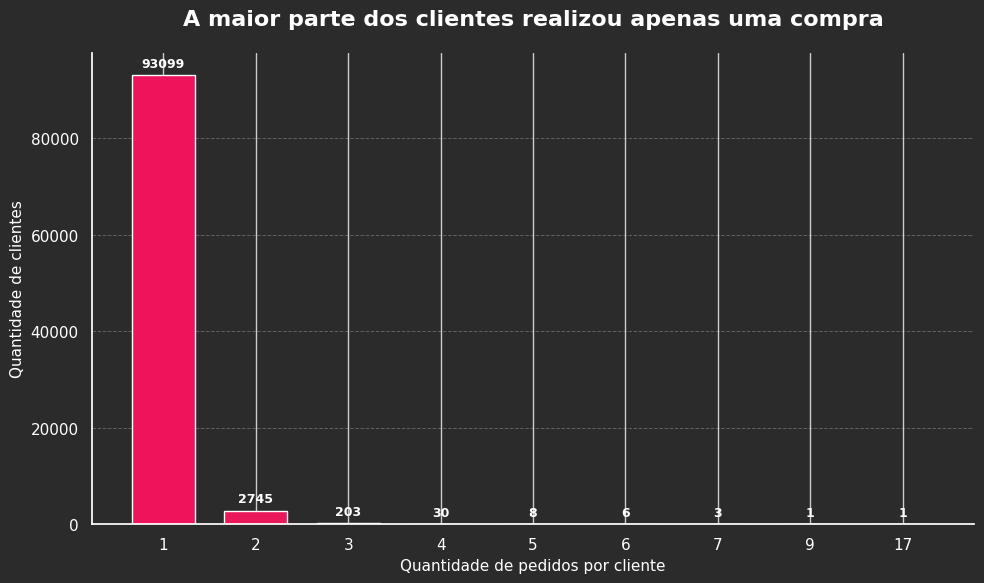

In [318]:
frequencia_clientes = (
    rfm["frequencia"]
    .value_counts()
    .sort_index()
)

cores_fiap = [
    "#ED145B",
    "#E9185A",
    "#E51F62",
    "#DF2C6C",
    "#D43A73",
    "#C64378",
    "#AE4271",
    "#914067",
    "#743B59",
    "#543346"
]

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#2B2B2B")
ax.set_facecolor("#2B2B2B")

barras = ax.bar(
    frequencia_clientes.index.astype(str),
    frequencia_clientes.values,
    color=cores_fiap[:len(frequencia_clientes)],
    width=0.68
)

ax.set_title(
    "A maior parte dos clientes realizou apenas uma compra",
    fontsize=16,
    fontweight="bold",
    color="white",
    pad=20
)

ax.set_xlabel(
    "Quantidade de pedidos por cliente",
    fontsize=11,
    color="white"
)

ax.set_ylabel(
    "Quantidade de clientes",
    fontsize=11,
    color="white"
)

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
    color="white"
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("white")
ax.spines["bottom"].set_color("white")

ax.bar_label(
    barras,
    fmt="%.0f",
    padding=4,
    color="white",
    fontsize=9,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#### **b. Recência**

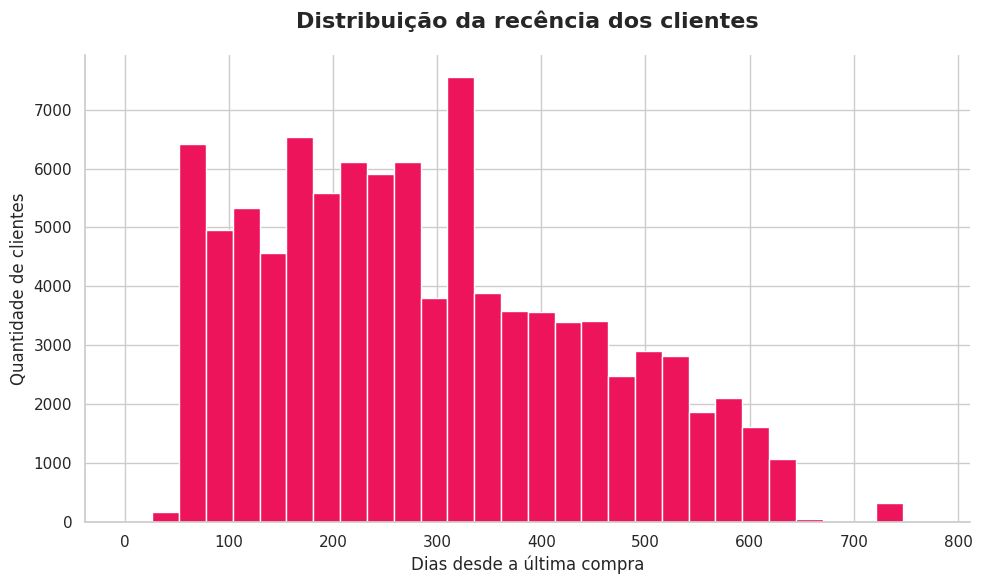

In [319]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    rfm["recencia"],
    bins=30,
    color="#ED145B",
    edgecolor="white"
)

ax.set_title(
    "Distribuição da recência dos clientes",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Dias desde a última compra")
ax.set_ylabel("Quantidade de clientes")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [320]:
clientes_recompra = rfm.copy()

clientes_recompra["comportamento"] = clientes_recompra["frequencia"].apply(
    lambda x: "Realizou recompra" if x > 1 else "Apenas uma compra"
)

recompra = (
    clientes_recompra["comportamento"]
    .value_counts()
)

percentual_recompra = (
    clientes_recompra["comportamento"]
    .value_counts(normalize=True)
    .mul(100)
)

recompra_resultado = pd.DataFrame({
    "Quantidade": recompra,
    "Percentual": percentual_recompra
})

recompra_resultado

,Quantidade,Percentual
comportamento,,
Apenas uma compra,93099,96.881244
Realizou recompra,2997,3.118756


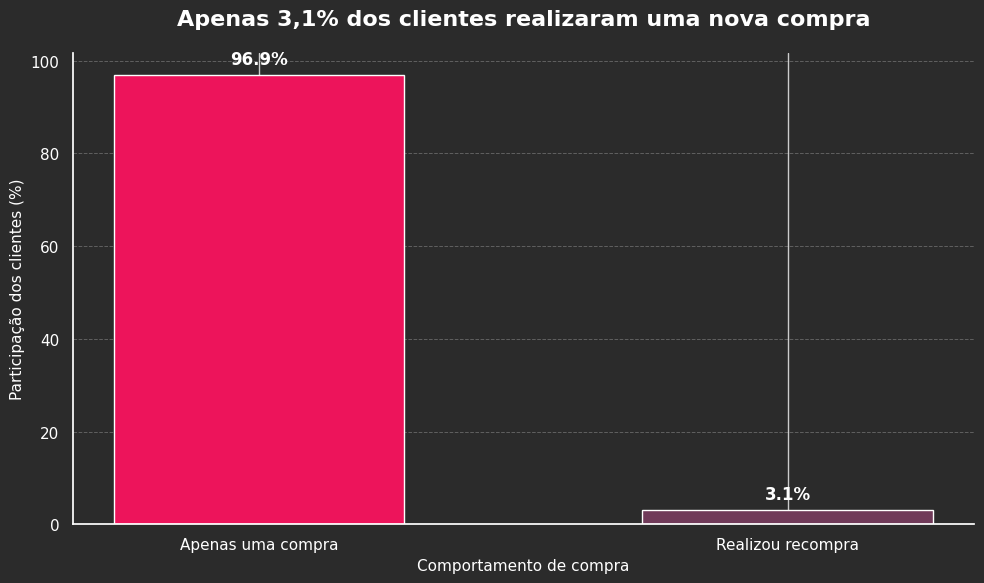

In [321]:
clientes_recompra = rfm.copy()

clientes_recompra["comportamento"] = clientes_recompra["frequencia"].apply(
    lambda x: "Realizou recompra" if x > 1 else "Apenas uma compra"
)

percentual_recompra = (
    clientes_recompra["comportamento"]
    .value_counts(normalize=True)
    .mul(100)
)

ordem = [
    "Apenas uma compra",
    "Realizou recompra"
]

dados_grafico = percentual_recompra.reindex(ordem)

cores_fiap = [
    "#ED145B",
    "#703A59"
]

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#2B2B2B")
ax.set_facecolor("#2B2B2B")

barras = ax.bar(
    dados_grafico.index,
    dados_grafico.values,
    color=cores_fiap,
    width=0.55
)

ax.set_title(
    "Apenas 3,1% dos clientes realizaram uma nova compra",
    fontsize=16,
    fontweight="bold",
    color="white",
    pad=20
)

ax.set_xlabel(
    "Comportamento de compra",
    fontsize=11,
    color="white"
)

ax.set_ylabel(
    "Participação dos clientes (%)",
    fontsize=11,
    color="white"
)

ax.tick_params(
    axis="x",
    colors="white",
    labelsize=11
)

ax.tick_params(
    axis="y",
    colors="white"
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
    color="white"
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("white")
ax.spines["bottom"].set_color("white")

ax.bar_label(
    barras,
    labels=[
        f"{valor:.1f}%"
        for valor in dados_grafico.values
    ],
    padding=5,
    color="white",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

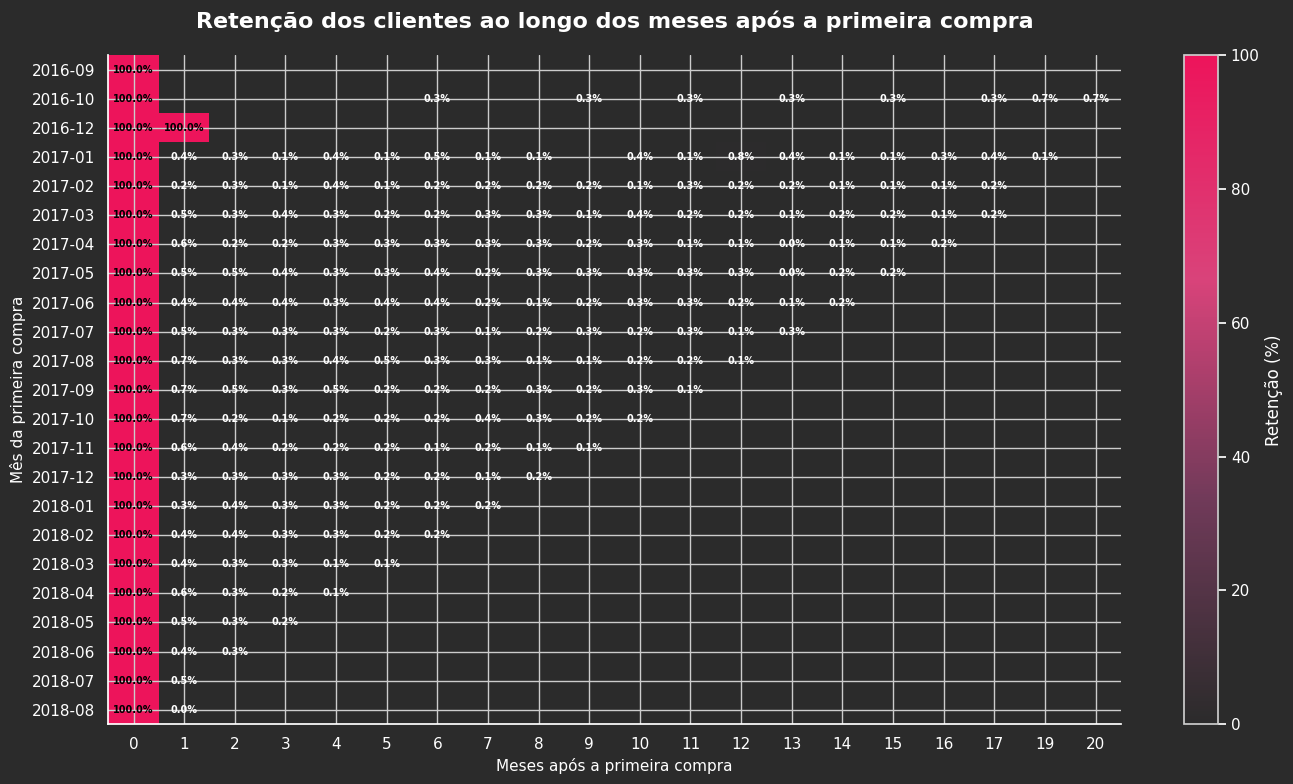

In [322]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pedidos = datasets["orders"].copy()
clientes = datasets["customers"].copy()

pedidos["order_purchase_timestamp"] = pd.to_datetime(
    pedidos["order_purchase_timestamp"]
)

pedidos_validos = pedidos[
    pedidos["order_status"] != "canceled"
].copy()

base_coorte = (
    pedidos_validos[
        [
            "order_id",
            "customer_id",
            "order_purchase_timestamp"
        ]
    ]
    .merge(
        clientes[
            [
                "customer_id",
                "customer_unique_id"
            ]
        ],
        on="customer_id",
        how="left"
    )
)

base_coorte["mes_compra"] = (
    base_coorte["order_purchase_timestamp"]
    .dt.to_period("M")
)

primeira_compra = (
    base_coorte
    .groupby("customer_unique_id")["mes_compra"]
    .min()
    .rename("coorte")
)

base_coorte = base_coorte.merge(
    primeira_compra,
    on="customer_unique_id",
    how="left"
)

base_coorte["indice_coorte"] = (
    (base_coorte["mes_compra"].dt.year - base_coorte["coorte"].dt.year) * 12
    +
    (base_coorte["mes_compra"].dt.month - base_coorte["coorte"].dt.month)
)

coorte = (
    base_coorte
    .groupby(
        ["coorte", "indice_coorte"]
    )["customer_unique_id"]
    .nunique()
    .reset_index()
)

coorte_pivot = coorte.pivot(
    index="coorte",
    columns="indice_coorte",
    values="customer_unique_id"
)

tamanho_coorte = coorte_pivot[0]

retencao = (
    coorte_pivot
    .divide(tamanho_coorte, axis=0)
    * 100
)

cmap_fiap = LinearSegmentedColormap.from_list(
    "fiap",
    [
        "#2B2B2B",
        "#703A59",
        "#D9437A",
        "#ED145B"
    ]
)

fig, ax = plt.subplots(figsize=(14, 8))

fig.patch.set_facecolor("#2B2B2B")
ax.set_facecolor("#2B2B2B")

imagem = ax.imshow(
    retencao,
    aspect="auto",
    cmap=cmap_fiap,
    vmin=0,
    vmax=100
)

ax.set_title(
    "Retenção dos clientes ao longo dos meses após a primeira compra",
    fontsize=16,
    fontweight="bold",
    color="white",
    pad=20
)

ax.set_xlabel(
    "Meses após a primeira compra",
    fontsize=11,
    color="white"
)

ax.set_ylabel(
    "Mês da primeira compra",
    fontsize=11,
    color="white"
)

ax.set_xticks(range(len(retencao.columns)))
ax.set_xticklabels(
    retencao.columns,
    color="white"
)

ax.set_yticks(range(len(retencao.index)))
ax.set_yticklabels(
    [str(periodo) for periodo in retencao.index],
    color="white"
)

ax.tick_params(
    axis="both",
    colors="white"
)

for i in range(retencao.shape[0]):
    for j in range(retencao.shape[1]):

        valor = retencao.iloc[i, j]

        if pd.notna(valor):
            ax.text(
                j,
                i,
                f"{valor:.1f}%",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if valor < 60 else "black",
                fontweight="bold"
            )

barra = plt.colorbar(
    imagem,
    ax=ax
)

barra.set_label(
    "Retenção (%)",
    color="white"
)

barra.ax.tick_params(
    colors="white"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("white")
ax.spines["bottom"].set_color("white")

plt.tight_layout()
plt.show()

,quantidade_clientes,taxa_recompra
faixa_avaliacao,,
1,10800,1.46
2,3157,6.56
3,7931,3.88
4,18846,4.64
5,54646,2.64


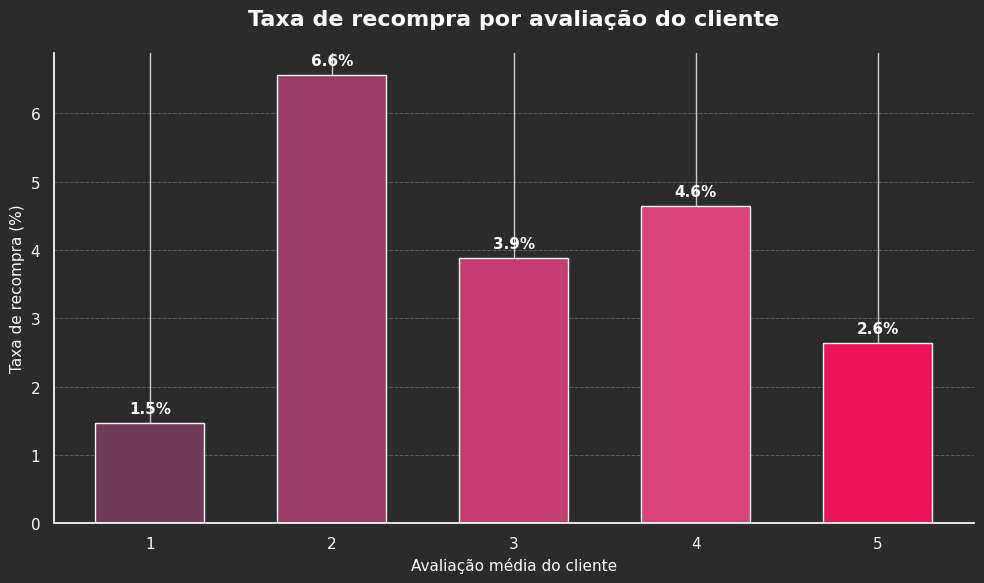

In [323]:
import pandas as pd
import matplotlib.pyplot as plt

clientes = datasets["customers"].copy()
pedidos = datasets["orders"].copy()
reviews = datasets["reviews"].copy()

pedidos_reviews = (
    pedidos[
        ["order_id", "customer_id"]
    ]
    .merge(
        clientes[
            ["customer_id", "customer_unique_id"]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        reviews[
            ["order_id", "review_score"]
        ],
        on="order_id",
        how="left"
    )
)

frequencia_cliente = (
    pedidos_reviews
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .rename("frequencia")
)

pedidos_reviews = pedidos_reviews.merge(
    frequencia_cliente,
    on="customer_unique_id",
    how="left"
)

pedidos_reviews["recompra"] = (
    pedidos_reviews["frequencia"] > 1
)

avaliacao_cliente = (
    pedidos_reviews
    .groupby("customer_unique_id")
    .agg(
        review_score=("review_score", "mean"),
        recompra=("recompra", "max")
    )
    .dropna()
    .reset_index()
)

avaliacao_cliente["faixa_avaliacao"] = (
    avaliacao_cliente["review_score"]
    .round()
    .clip(1, 5)
    .astype(int)
)

taxa_recompra_avaliacao = (
    avaliacao_cliente
    .groupby("faixa_avaliacao")["recompra"]
    .mean()
    .mul(100)
    .reindex([1, 2, 3, 4, 5])
)

quantidade_clientes_avaliacao = (
    avaliacao_cliente
    .groupby("faixa_avaliacao")["customer_unique_id"]
    .nunique()
    .reindex([1, 2, 3, 4, 5])
)

resultado_avaliacao = pd.DataFrame({
    "quantidade_clientes": quantidade_clientes_avaliacao,
    "taxa_recompra": taxa_recompra_avaliacao
})

display(resultado_avaliacao.round(2))

cores_fiap = [
    "#703A59",
    "#9C3D68",
    "#C63D72",
    "#D9437A",
    "#ED145B"
]

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#2B2B2B")
ax.set_facecolor("#2B2B2B")

barras = ax.bar(
    taxa_recompra_avaliacao.index.astype(str),
    taxa_recompra_avaliacao.values,
    color=cores_fiap,
    width=0.6
)

ax.set_title(
    "Taxa de recompra por avaliação do cliente",
    fontsize=16,
    fontweight="bold",
    color="white",
    pad=20
)

ax.set_xlabel(
    "Avaliação média do cliente",
    fontsize=11,
    color="white"
)

ax.set_ylabel(
    "Taxa de recompra (%)",
    fontsize=11,
    color="white"
)

ax.tick_params(
    axis="x",
    colors="white"
)

ax.tick_params(
    axis="y",
    colors="white"
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
    color="white"
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("white")
ax.spines["bottom"].set_color("white")

ax.bar_label(
    barras,
    labels=[
        f"{valor:.1f}%"
        for valor in taxa_recompra_avaliacao.values
    ],
    padding=5,
    color="white",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#### c. Frequência

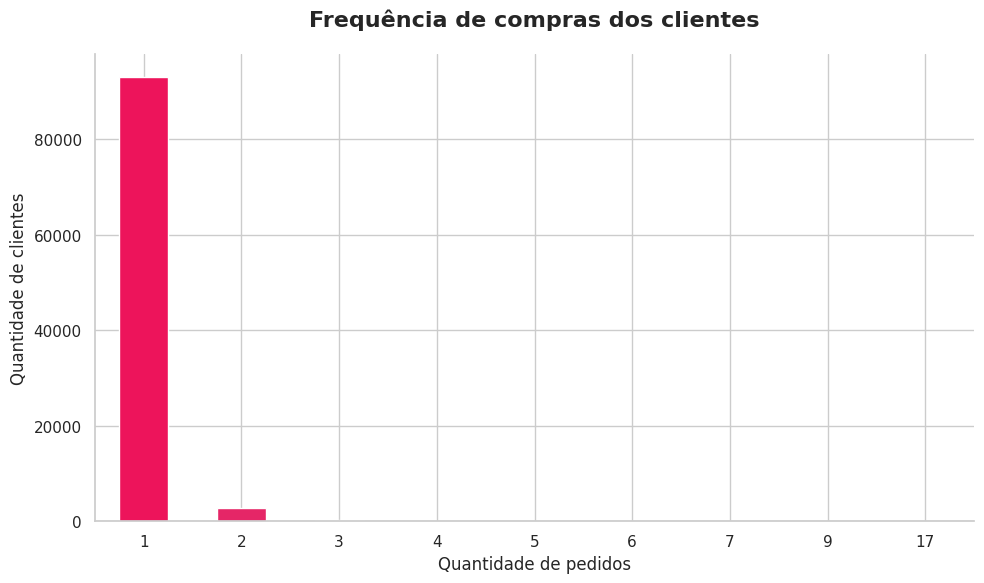

In [324]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

cmap_fiap = LinearSegmentedColormap.from_list(
    "fiap",
    ["#ED145B", "#D9437A", "#703A59", "#2B2B2B"]
)

frequencia_clientes = (
    rfm["frequencia"]
    .value_counts()
    .sort_index()
)

cores_frequencia = [
    cmap_fiap(i / max(len(frequencia_clientes) - 1, 1))
    for i in range(len(frequencia_clientes))
]

fig, ax = plt.subplots(figsize=(10, 6))

frequencia_clientes.plot(
    kind="bar",
    ax=ax,
    color=cores_frequencia
)

ax.set_title(
    "Frequência de compras dos clientes",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Quantidade de pedidos")
ax.set_ylabel("Quantidade de clientes")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### d.Monetização

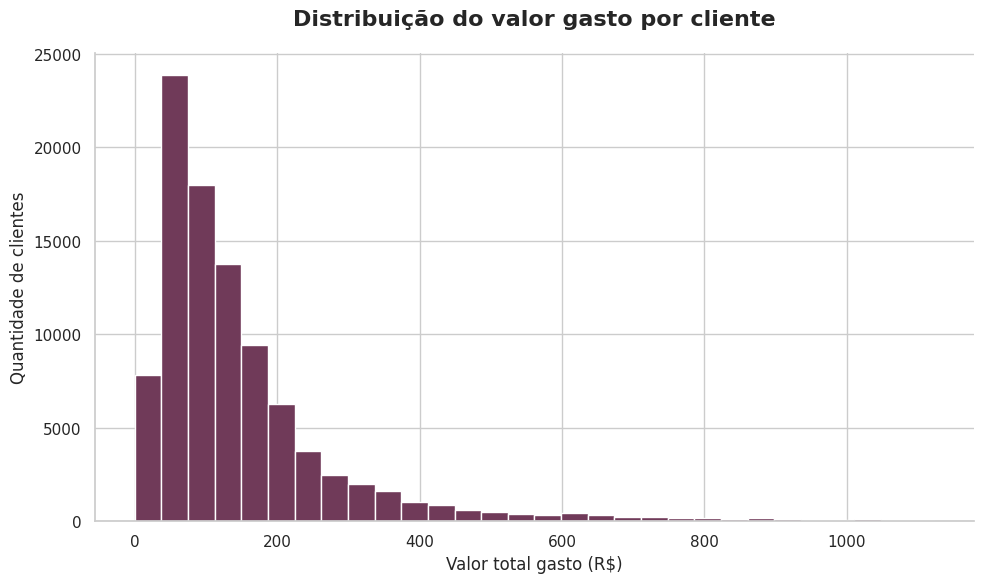

In [325]:
limite_monetizacao = rfm["monetizacao"].quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    rfm.loc[
        rfm["monetizacao"] <= limite_monetizacao,
        "monetizacao"
    ],
    bins=30,
    color="#703A59",
    edgecolor="white"
)

ax.set_title(
    "Distribuição do valor gasto por cliente",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Valor total gasto (R$)")
ax.set_ylabel("Quantidade de clientes")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### e. Oportunidades

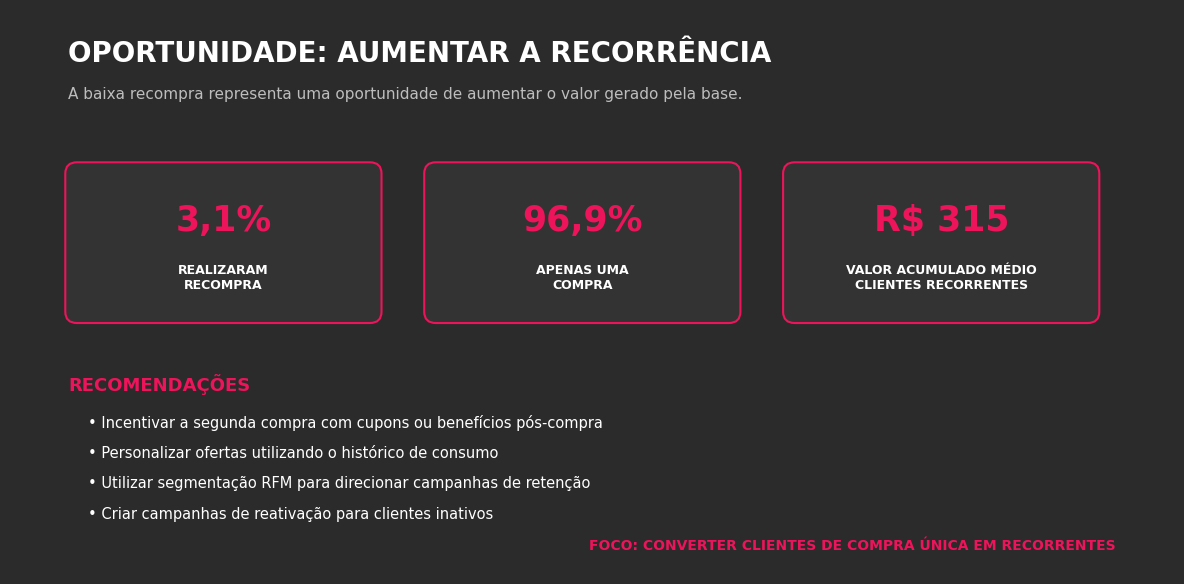

In [326]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# =========================
# PALETA FIAP
# =========================
fundo = "#2B2B2B"
fundo_card = "#333333"
rosa = "#ED145B"
branco = "#FFFFFF"
cinza = "#BDBDBD"

# =========================
# CRIAÇÃO DA FIGURA
# =========================
fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor(fundo)
ax.set_facecolor(fundo)

ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis("off")

# =========================
# TÍTULO
# =========================
ax.text(
    0.6, 5.45,
    "OPORTUNIDADE: AUMENTAR A RECORRÊNCIA",
    fontsize=20,
    fontweight="bold",
    color=branco
)

ax.text(
    0.6, 5.05,
    "A baixa recompra representa uma oportunidade de aumentar o valor gerado pela base.",
    fontsize=11,
    color=cinza
)

# =========================
# CARDS DOS INDICADORES
# =========================
cards = [
    (
        0.6,
        "3,1%",
        "REALIZARAM\nRECOMPRA"
    ),
    (
        4.3,
        "96,9%",
        "APENAS UMA\nCOMPRA"
    ),
    (
        8.0,
        "R$ 315",
        "VALOR ACUMULADO MÉDIO\nCLIENTES RECORRENTES"
    )
]

for x, numero, descricao in cards:

    card = FancyBboxPatch(
        (x, 2.7),
        3.2,
        1.65,
        boxstyle="round,pad=0.03,rounding_size=0.12",
        linewidth=1.5,
        edgecolor=rosa,
        facecolor=fundo_card
    )

    ax.add_patch(card)

    ax.text(
        x + 1.6,
        3.75,
        numero,
        ha="center",
        va="center",
        fontsize=25,
        fontweight="bold",
        color=rosa
    )

    ax.text(
        x + 1.6,
        3.15,
        descricao,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=branco
    )

# =========================
# RECOMENDAÇÕES
# =========================
ax.text(
    0.6, 1.95,
    "RECOMENDAÇÕES",
    fontsize=13,
    fontweight="bold",
    color=rosa
)

recomendacoes = [
    "Incentivar a segunda compra com cupons ou benefícios pós-compra",
    "Personalizar ofertas utilizando o histórico de consumo",
    "Utilizar segmentação RFM para direcionar campanhas de retenção",
    "Criar campanhas de reativação para clientes inativos"
]

y = 1.55

for recomendacao in recomendacoes:

    ax.text(
        0.8,
        y,
        "• " + recomendacao,
        fontsize=10.5,
        color=branco
    )

    y -= 0.32

# =========================
# MENSAGEM FINAL
# =========================
ax.text(
    11.4,
    0.25,
    "FOCO: CONVERTER CLIENTES DE COMPRA ÚNICA EM RECORRENTES",
    fontsize=10,
    fontweight="bold",
    color=rosa,
    ha="right"
)

plt.tight_layout()

# =========================
# SALVAR IMAGEM
# =========================
plt.savefig(
    "oportunidade_retencao.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

<>:91: SyntaxWarning:

invalid escape sequence '\$'

<>:91: SyntaxWarning:

invalid escape sequence '\$'

/tmp/ipykernel_1526/13043155.py:91: SyntaxWarning:

invalid escape sequence '\$'



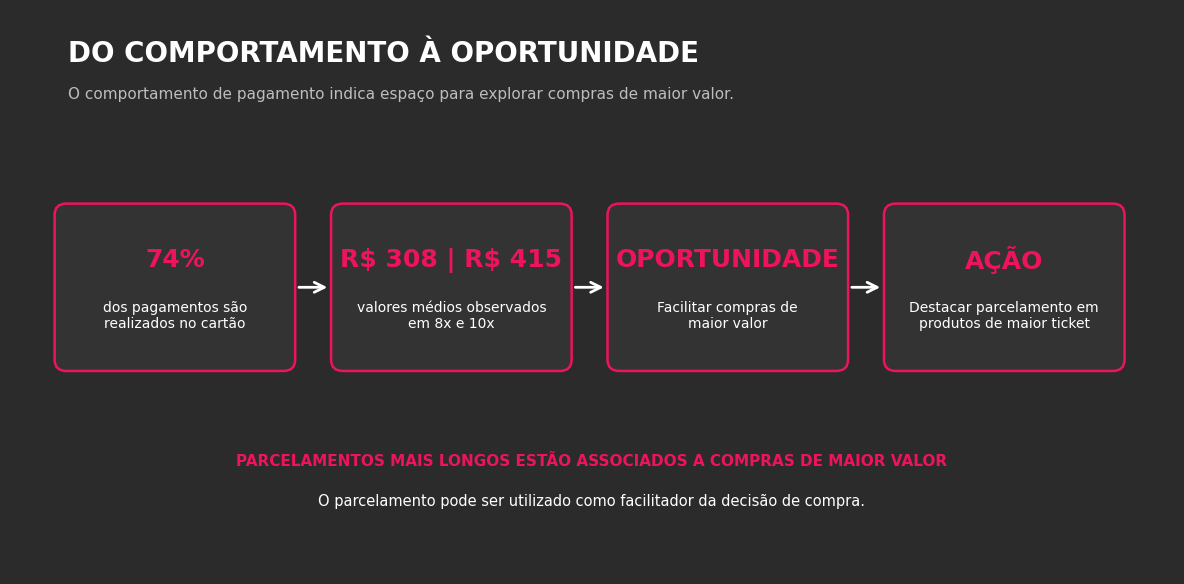

In [327]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# =========================
# CORES FIAP
# =========================
fundo = "#2B2B2B"
card = "#333333"
rosa = "#ED145B"
branco = "#FFFFFF"
cinza = "#BDBDBD"

fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor(fundo)
ax.set_facecolor(fundo)

ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis("off")


# =========================
# TÍTULO
# =========================
ax.text(
    0.6, 5.45,
    "DO COMPORTAMENTO À OPORTUNIDADE",
    fontsize=20,
    fontweight="bold",
    color=branco
)

ax.text(
    0.6, 5.05,
    "O comportamento de pagamento indica espaço para explorar compras de maior valor.",
    fontsize=11,
    color=cinza
)


# =========================
# FUNÇÃO PARA CRIAR CARD
# =========================
def criar_card(x, y, largura, altura, titulo, texto):

    caixa = FancyBboxPatch(
        (x, y),
        largura,
        altura,
        boxstyle="round,pad=0.04,rounding_size=0.12",
        linewidth=1.8,
        edgecolor=rosa,
        facecolor=card
    )

    ax.add_patch(caixa)

    ax.text(
        x + largura/2,
        y + altura*0.67,
        titulo,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color=rosa
    )

    ax.text(
        x + largura/2,
        y + altura*0.32,
        texto,
        ha="center",
        va="center",
        fontsize=10,
        color=branco
    )


# CARD 1
criar_card(
    0.5, 2.2, 2.4, 1.7,
    "74%",
    "dos pagamentos são\nrealizados no cartão"
)

# CARD 2
criar_card(
    3.35, 2.2, 2.4, 1.7,
    "R\$ 308 | R\$ 415",
    "valores médios observados\nem 8x e 10x"
)

# CARD 3
criar_card(
    6.2, 2.2, 2.4, 1.7,
    "OPORTUNIDADE",
    "Facilitar compras de\nmaior valor"
)

# CARD 4
criar_card(
    9.05, 2.2, 2.4, 1.7,
    "AÇÃO",
    "Destacar parcelamento em\nprodutos de maior ticket"
)


# =========================
# SETAS
# =========================
for inicio, fim in [
    ((2.95, 3.05), (3.30, 3.05)),
    ((5.80, 3.05), (6.15, 3.05)),
    ((8.65, 3.05), (9.00, 3.05))
]:

    seta = FancyArrowPatch(
        inicio,
        fim,
        arrowstyle="->",
        mutation_scale=18,
        linewidth=2,
        color=branco
    )

    ax.add_patch(seta)


# =========================
# INSIGHT FINAL
# =========================
ax.text(
    6,
    1.15,
    "PARCELAMENTOS MAIS LONGOS ESTÃO ASSOCIADOS A COMPRAS DE MAIOR VALOR",
    ha="center",
    fontsize=11,
    fontweight="bold",
    color=rosa
)

ax.text(
    6,
    0.72,
    "O parcelamento pode ser utilizado como facilitador da decisão de compra.",
    ha="center",
    fontsize=10.5,
    color=branco
)


plt.tight_layout()

plt.savefig(
    "oportunidade_pagamentos_fluxo.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

####f. Recompra e retenção por corte

In [328]:
total_clientes = rfm["customer_unique_id"].nunique()

clientes_recompra = rfm.loc[
    rfm["frequencia"] > 1,
    "customer_unique_id"
].nunique()

clientes_uma_compra = total_clientes - clientes_recompra

taxa_recompra = (
    clientes_recompra / total_clientes
) * 100

print(f"Total de clientes: {total_clientes}")
print(f"Clientes com recompra: {clientes_recompra}")
print(f"Clientes com apenas uma compra: {clientes_uma_compra}")
print(f"Taxa de recompra: {taxa_recompra:.2f}%")

Total de clientes: 96096
Clientes com recompra: 2997
Clientes com apenas uma compra: 93099
Taxa de recompra: 3.12%


**Taxa Geral de recompra**

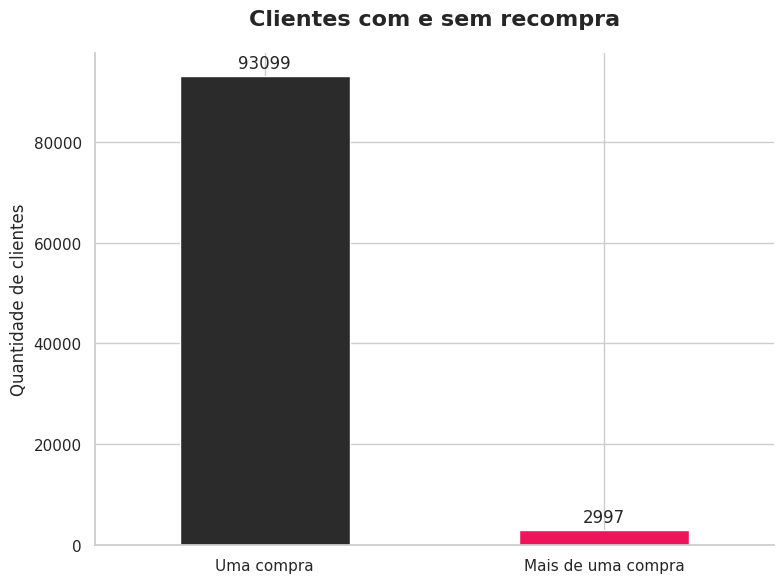

In [329]:
dados_recompra = pd.Series({
    "Uma compra": clientes_uma_compra,
    "Mais de uma compra": clientes_recompra
})

fig, ax = plt.subplots(figsize=(8, 6))

dados_recompra.plot(
    kind="bar",
    ax=ax,
    color=["#2B2B2B", "#ED145B"]
)

ax.set_title(
    "Clientes com e sem recompra",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("")
ax.set_ylabel("Quantidade de clientes")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Retenção por coorte**

In [330]:
base_coorte = (
    pedidos_validos[
        [
            "order_id",
            "customer_id",
            "order_purchase_timestamp"
        ]
    ]
    .merge(
        clientes[
            [
                "customer_id",
                "customer_unique_id"
            ]
        ],
        on="customer_id",
        how="left"
    )
)

base_coorte["mes_compra"] = (
    base_coorte["order_purchase_timestamp"]
    .dt.to_period("M")
)

primeira_compra = (
    base_coorte
    .groupby("customer_unique_id")["mes_compra"]
    .min()
    .rename("coorte")
)

base_coorte = base_coorte.merge(
    primeira_compra,
    on="customer_unique_id",
    how="left"
)

base_coorte["indice_coorte"] = (
    (base_coorte["mes_compra"].dt.year - base_coorte["coorte"].dt.year) * 12
    +
    (base_coorte["mes_compra"].dt.month - base_coorte["coorte"].dt.month)
)

coorte = (
    base_coorte
    .groupby(
        ["coorte", "indice_coorte"]
    )["customer_unique_id"]
    .nunique()
    .reset_index()
)

coorte_pivot = coorte.pivot(
    index="coorte",
    columns="indice_coorte",
    values="customer_unique_id"
)

tamanho_coorte = coorte_pivot[0]

retencao = (
    coorte_pivot
    .divide(tamanho_coorte, axis=0)
    * 100
)

retencao

indice_coorte,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
coorte,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.336700,NaN,NaN,0.336700,NaN,0.336700,NaN,0.336700,NaN,0.336700,NaN,0.336700,0.673401,0.673401
2016-12,100.0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.393701,0.262467,0.131234,0.393701,0.131234,0.524934,0.131234,0.131234,NaN,0.393701,0.131234,0.787402,0.393701,0.131234,0.131234,0.262467,0.393701,0.131234,NaN
2017-02,100.0,0.230548,0.288184,0.115274,0.403458,0.115274,0.230548,0.172911,0.172911,0.230548,0.115274,0.288184,0.172911,0.172911,0.115274,0.057637,0.057637,0.230548,NaN,NaN
2017-03,100.0,0.499424,0.345755,0.384172,0.345755,0.153669,0.153669,0.307338,0.345755,0.076834,0.384172,0.153669,0.230503,0.115252,0.153669,0.230503,0.076834,0.153669,NaN,NaN
2017-04,100.0,0.599829,0.214225,0.171380,0.299914,0.257069,0.342759,0.299914,0.299914,0.171380,0.257069,0.085690,0.085690,0.042845,0.085690,0.085690,0.171380,NaN,NaN,NaN
2017-05,100.0,0.476057,0.504060,0.392047,0.308037,0.336040,0.420050,0.168020,0.252030,0.280034,0.252030,0.336040,0.252030,0.028003,0.196024,0.224027,NaN,NaN,NaN,NaN
2017-06,100.0,0.447857,0.351887,0.415867,0.255918,0.383877,0.351887,0.223928,0.127959,0.223928,0.319898,0.319898,0.159949,0.127959,0.191939,NaN,NaN,NaN,NaN,NaN


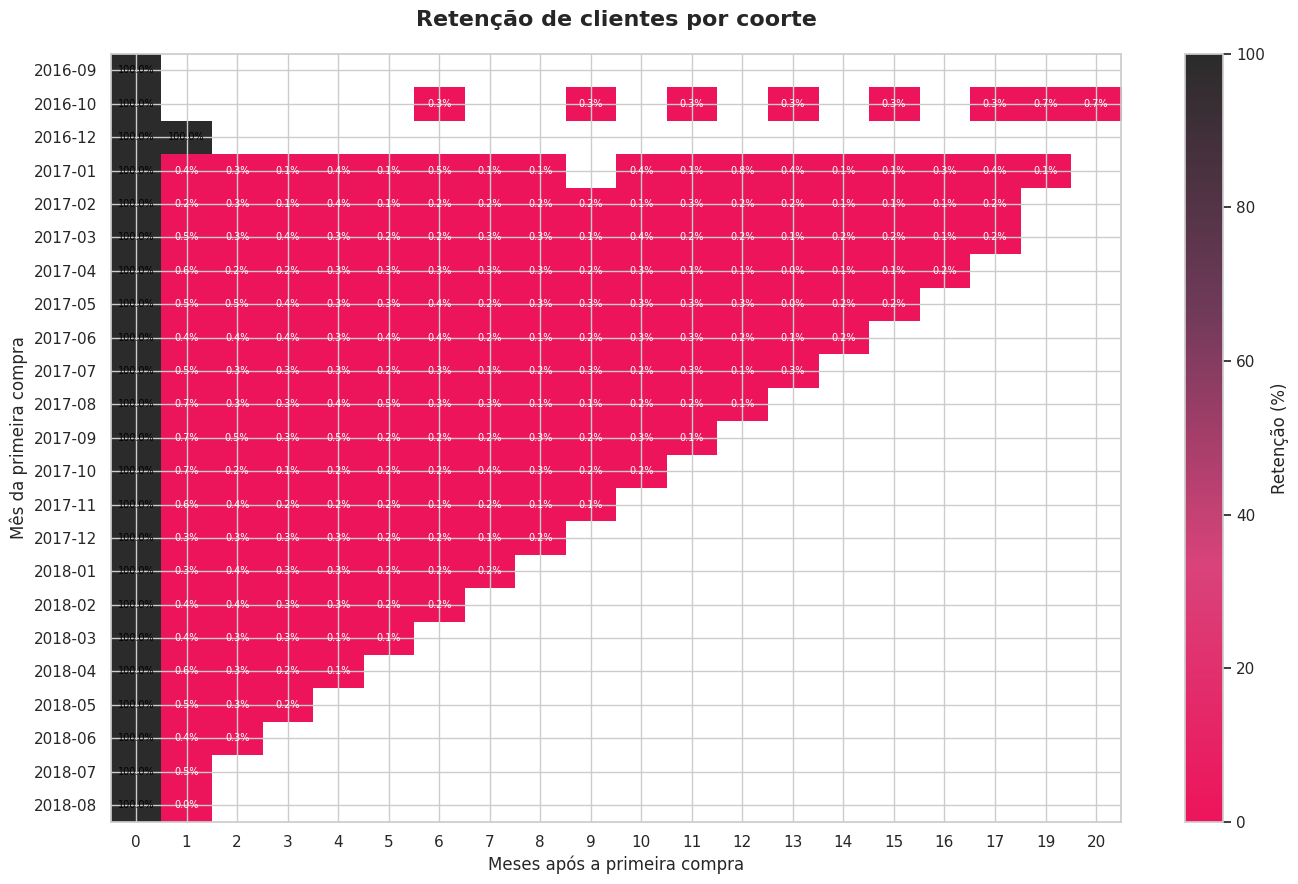

In [331]:
fig, ax = plt.subplots(figsize=(14, 9))

imagem = ax.imshow(
    retencao,
    aspect="auto",
    cmap=cmap_fiap,
    vmin=0,
    vmax=100
)

ax.set_title(
    "Retenção de clientes por coorte",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Meses após a primeira compra")
ax.set_ylabel("Mês da primeira compra")

ax.set_xticks(range(len(retencao.columns)))
ax.set_xticklabels(retencao.columns)

ax.set_yticks(range(len(retencao.index)))
ax.set_yticklabels(
    [str(periodo) for periodo in retencao.index]
)

for i in range(retencao.shape[0]):
    for j in range(retencao.shape[1]):

        valor = retencao.iloc[i, j]

        if pd.notna(valor):
            ax.text(
                j,
                i,
                f"{valor:.1f}%",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if valor < 40 else "black"
            )

barra = plt.colorbar(
    imagem,
    ax=ax
)

barra.set_label("Retenção (%)")

plt.tight_layout()
plt.show()

### **IV. Satisfação do Cliente**

#### **a. Reviews Totais**

In [332]:
score_counts = datasets['reviews']['review_score'].value_counts().reset_index()
score_counts.columns = ['review_score', 'count']
score_counts = score_counts.sort_values('review_score')

fig = px.bar(
    score_counts,
    x='review_score',
    y='count',
    color='review_score',
    color_continuous_scale=paleta_fiap,
    title='Quantidade de Reviews por Score',
    labels={'review_score': 'Review Score', 'count': 'Quantidade'}
)

fig.update_layout(
    xaxis_title=dict(text='Review Score', font=dict(color='white')),
    yaxis_title=dict(text='Quantidade', font=dict(color='white')),
    title=dict(text='Quantidade de Reviews por Score', x=0.5, font=dict(color='white')),
    showlegend=False,
    xaxis=dict(tickmode='linear', tickfont=dict(color='white'), gridcolor=paleta_fiap[1], griddash='dash', gridwidth=1, showgrid=True),
    yaxis=dict(tickfont=dict(color='white'), gridcolor=paleta_fiap[1], griddash='dash', gridwidth=1, showgrid=True),
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    coloraxis_colorbar=dict(
        title=dict(text='Média de Avaliação', font=dict(color='white')),
        tickfont=dict(color='white')
    )
)
fig.show()

#### **b. Top 5 categorias alta/baixa avaliação**

In [333]:
import plotly.express as px
import pandas as pd

# Carregar os dataframes necessários
df_products = datasets['products']
df_order_items = datasets['order_items']
df_reviews = datasets['reviews']
df_product_category_name_translation = datasets['product_category_name_translation']
df_orders = datasets['orders'] # Adicionado para tempo de entrega

# 1. Mesclar df_order_items com df_products para obter a categoria do produto
products_with_items = pd.merge(df_order_items, df_products[['product_id', 'product_category_name']], on='product_id', how='inner')

# 2. Mesclar com as avaliações para obter o review_score
products_reviews = pd.merge(products_with_items, df_reviews[['order_id', 'review_score']], on='order_id', how='inner')

# 3. Mesclar com a tabela de tradução de nomes de categorias (mantido para estrutura, mas usaremos o nome original)
products_reviews_translated = pd.merge(
    products_reviews,
    df_product_category_name_translation,
    on='product_category_name',
    how='left'
)

# Usar o nome da categoria original (Português)
products_reviews_translated['product_category_name_final'] = products_reviews_translated['product_category_name']

# Adicionar informações de tempo de entrega
# Mesclar com df_orders para obter os timestamps de compra e entrega
products_reviews_delivery = pd.merge(
    products_reviews_translated,
    df_orders[['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date']], # Usar os nomes de coluna originais
    on='order_id',
    how='inner' # Manter inner join para consistência com merges anteriores
)

# Converter colunas de data para datetime
products_reviews_delivery['order_purchase_timestamp'] = pd.to_datetime(products_reviews_delivery['order_purchase_timestamp'])
products_reviews_delivery['order_delivered_customer_date'] = pd.to_datetime(products_reviews_delivery['order_delivered_customer_date'])

# Calcular o tempo de entrega em horas
products_reviews_delivery['delivery_time_hours'] = (
    products_reviews_delivery['order_delivered_customer_date'] - products_reviews_delivery['order_purchase_timestamp'] # Usar os nomes de coluna originais
).dt.total_seconds() / 3600

# Remover linhas com tempo de entrega ou review_score nulos, para garantir dados válidos para ambas as métricas.
# review_score já foi tratado por 'inner' join com df_reviews.
# delivery_time_hours pode ter NaNs se 'order_delivered_customer_date' for nulo.
products_reviews_delivery_filtered = products_reviews_delivery.dropna(subset=['delivery_time_hours', 'review_score'])


# 4. Calcular a média de review_score e delivery_time_hours por categoria
category_metrics = products_reviews_delivery_filtered.groupby('product_category_name_final').agg(
    average_review_score=('review_score', 'mean'),
    average_delivery_time_hours=('delivery_time_hours', 'mean')
).reset_index()

# 5. Filtrar e selecionar as top 5 categorias com 5 estrelas e as top 5 com 1 estrela
# As categorias com 5 estrelas serão as com maior média de avaliação
top_5_good_categories = category_metrics.sort_values(by='average_review_score', ascending=False).head(5)
top_5_good_categories['type'] = 'Top 5 Categorias (Média Alta)'

# As categorias com 1 estrela serão as com menor média de avaliação
top_5_bad_categories = category_metrics.sort_values(by='average_review_score', ascending=True).head(5)
top_5_bad_categories['type'] = 'Top 5 Categorias (Média Baixa)'

# Combinar os dataframes
combined_categories = pd.concat([top_5_good_categories, top_5_bad_categories])

# Definir as cores:
# O bom (média alta) é rosa (#ED145B, do paleta_fiap)
# O ruim (média baixa) é cinza (#2a2a2a, do paleta_fiap)
color_map = {
    'Top 5 Categorias (Média Alta)': paleta_fiap[4],  # Rosa
    'Top 5 Categorias (Média Baixa)': paleta_fiap[0]   # Cinza
}

# 6. Criar o gráfico de barras interativo
fig = px.bar(
    combined_categories,
    x='product_category_name_final',
    y='average_review_score',
    color='type',
    color_discrete_map=color_map,
    title='Top 5 Categorias por Média de Avaliação (Alta e Baixa)',
    labels={
        'product_category_name_final': 'Categoria do Produto',
        'average_review_score': 'Média de Avaliação',
        'type': 'Tipo de Categoria'
    },
    hover_data={'average_review_score': ':.2f'} # Removido o tempo médio de entrega
)

fig.update_layout(
    xaxis_title=dict(text='Categoria do Produto', font=dict(color='white')),
    yaxis_title=dict(text='Média de Avaliação', font=dict(color='white')),
    title=dict(text='Top 5 Categorias por Média de Avaliação (Alta e Baixa)', x=0.5, font=dict(color='white')),
    xaxis=dict(tickfont=dict(color='white'), gridcolor=paleta_fiap[1], griddash='dash', gridwidth=1, showgrid=True),
    yaxis=dict(tickfont=dict(color='white'), gridcolor=paleta_fiap[1], griddash='dash', gridwidth=1, showgrid=True),
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)'
)

# Add white outline to grey bars (Top 5 Categorias (Média Baixa))
# The color_map defines 'Top 5 Categorias (Média Baixa)' to paleta_fiap[0] (dark grey)
fig.update_traces(
    marker_line_color='white',
    marker_line_width=1,
    selector=dict(marker_color=paleta_fiap[0])
)

fig.show()

In [334]:
import plotly.express as px
import pandas as pd

# Sort the categories by average_review_score in descending order
category_metrics_sorted = category_metrics.sort_values(by='average_review_score', ascending=False)

# Create a continuous color scale using paleta_fiap
# paleta_fiap has 5 colors: darkest gray, a few shades of pink/purple, brightest pink
# We want highest score to be brightest pink and lowest score to be darkest gray.
# So, we'll use paleta_fiap[::-1] to reverse it, or simply select the colors explicitly.
# Let's map it from paleta_fiap[4] (brightest pink) to paleta_fiap[0] (darkest grey).

fig = px.bar(
    category_metrics_sorted,
    x='product_category_name_final',
    y='average_review_score',
    color='average_review_score', # Color based on the review score itself
    color_continuous_scale=[paleta_fiap[0], paleta_fiap[1], paleta_fiap[2], paleta_fiap[3], paleta_fiap[4]], # Custom continuous scale from gray to pink
    title='Média de Score de Reviews por Categoria',
    labels={
        'product_category_name_final': 'Categoria do Produto',
        'average_review_score': 'Média de Avaliação'
    },
    hover_data={'average_review_score': ':.2f'}
)

fig.update_layout(
    xaxis_title=dict(text='Categoria do Produto', font=dict(color='white')),
    yaxis_title=dict(text='Média de Avaliação', font=dict(color='white')),
    title=dict(text='Média de Score de Reviews por Categoria (Ordenado)', x=0.5, font=dict(color='white')),
    xaxis=dict(tickfont=dict(color='white'), gridcolor='rgba(255,255,255,0.3)', griddash='dash', gridwidth=1, showgrid=True),
    yaxis=dict(tickfont=dict(color='white'), gridcolor='rgba(255,255,255,0.3)', griddash='dash', gridwidth=1, showgrid=True),
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    coloraxis_colorbar=dict(
        title=dict(text='Média de Avaliação', font=dict(color='white')),
        tickfont=dict(color='white')
    )
)

fig.show()

#### **c. Tempo de Entrega vs Peso do Produto vs Média Avaliação**

In [335]:
import plotly.express as px
import pandas as pd

# Carregar os dataframes necessários
df_orders = datasets['orders']
df_reviews = datasets['reviews']
df_order_items = datasets['order_items']
df_products = datasets['products']

# 1. Mesclar pedidos com avaliações para obter order_id, tempo de entrega e score da avaliação
orders_reviews = pd.merge(df_orders, df_reviews, on='order_id', how='inner')

# 2. Converter colunas de data para datetime
orders_reviews['dt_pedido'] = pd.to_datetime(orders_reviews['order_purchase_timestamp'])
orders_reviews['dt_entrega'] = pd.to_datetime(orders_reviews['order_delivered_customer_date'])

# 3. Calcular o tempo de entrega em horas
orders_reviews['delivery_time_hours'] = (orders_reviews['dt_entrega'] - orders_reviews['dt_pedido']).dt.total_seconds() / 3600

# Remover linhas com tempo de entrega ou review_score nulos (significam pedidos não entregues ou sem avaliação)
orders_reviews_filtered = orders_reviews.dropna(subset=['delivery_time_hours', 'review_score'])

# 4. Mesclar com order_items para obter product_id
orders_items_reviews = pd.merge(orders_reviews_filtered, df_order_items, on='order_id', how='inner')

# 5. Mesclar com produtos para obter o peso do produto
final_data = pd.merge(orders_items_reviews, df_products[['product_id', 'product_weight_g']], on='product_id', how='inner')

# Remover linhas com peso do produto nulo
final_data = final_data.dropna(subset=['product_weight_g'])

# 6. Agrupar por product_id para calcular a média do tempo de entrega e da avaliação
product_summary = final_data.groupby('product_id').agg(
    average_delivery_time_hours=('delivery_time_hours', 'mean'),
    average_review_score=('review_score', 'mean'),
    product_weight_g=('product_weight_g', 'mean') # Peso deve ser o mesmo para o mesmo product_id
).reset_index()

# 7. Criar o gráfico de dispersão interativo
fig = px.scatter(
    product_summary,
    x='product_weight_g',
    y='average_delivery_time_hours',
    color='average_review_score',
    size='product_weight_g', # Opcional: fazer o tamanho do ponto depender do peso para visualização extra
    color_continuous_scale=paleta_fiap, # Usar a paleta Fiap para a cor
    title='Tempo de Entrega vs Peso do Produto vs Média de Avaliação',
    labels={
        'product_weight_g': 'Peso do Produto (gramas)',
        'average_delivery_time_hours': 'Tempo Médio de Entrega (horas)',
        'average_review_score': 'Média de Avaliação'
    },
    hover_name='product_id' # Mostrar o ID do produto ao passar o mouse
)

fig.update_layout(
    xaxis_title='Peso do Produto (gramas)',
    yaxis_title='Tempo Médio de Entrega (horas)',
    coloraxis_colorbar=dict(
        title='Média de Avaliação'
    ),
    title_x=0.5,
    yaxis=dict(gridcolor='#dddddd', griddash='dash', gridwidth=1, showgrid=True),
    xaxis=dict(gridcolor='#dddddd', griddash='dash', gridwidth=1, showgrid=True),
    plot_bgcolor='white' # Adiciona fundo branco ao plot
)

fig.show()

#### **d. Tempo Médio de Entrega por Estado Brasileiro**

In [336]:
import plotly.express as px
import pandas as pd

# Carregar os dataframes necessários
df_orders = datasets['orders']
df_customers = datasets['customers']
df_reviews = datasets['reviews'] # Carrega o dataframe de reviews

# 1. Mesclar orders com customers para obter o estado do cliente
orders_customers = pd.merge(df_orders, df_customers, on='customer_id', how='inner')

# 2. Converter colunas de data para datetime
orders_customers['dt_pedido'] = pd.to_datetime(orders_customers['order_purchase_timestamp'])
orders_customers['dt_entrega'] = pd.to_datetime(orders_customers['order_delivered_customer_date'])

# 3. Calcular o tempo de entrega em horas
orders_customers['delivery_time_hours'] = (orders_customers['dt_entrega'] - orders_customers['dt_pedido']).dt.total_seconds() / 3600

# Remover linhas com tempo de entrega nulo (significam pedidos não entregues)
orders_customers_filtered = orders_customers.dropna(subset=['delivery_time_hours'])

# Mesclar com reviews para obter a pontuação da avaliação
orders_customers_reviews = pd.merge(orders_customers_filtered, df_reviews[['order_id', 'review_score']], on='order_id', how='left')

# 4. Calcular o tempo médio de entrega e a média de reviews por estado do cliente
avg_metrics_by_state = orders_customers_reviews.groupby('customer_state').agg(
    average_delivery_time_hours=('delivery_time_hours', 'mean'),
    average_review_score=('review_score', 'mean')
).reset_index()

# 5. Ordenar por tempo médio de entrega para melhor visualização
avg_metrics_by_state = avg_metrics_by_state.sort_values(by='average_delivery_time_hours', ascending=False)

# 6. Criar o gráfico de barras interativo
fig = px.bar(
    avg_metrics_by_state,
    x='customer_state',
    y='average_delivery_time_hours',
    color='average_review_score', # Colorir pela média do tempo de entrega
    color_continuous_scale=paleta_fiap, # Usar a paleta Fiap
    title='Tempo Médio de Entrega e Média de Reviews por Estado Brasileiro',
    labels={
        'customer_state': 'Estado do Cliente',
        'average_delivery_time_hours': 'Tempo Médio de Entrega (horas)',
        'average_review_score': 'Média de Avaliação'
    },
    hover_data={'average_delivery_time_hours': ':.2f', 'average_review_score': ':.2f'} # Formatar hover para 2 casas decimais
)

fig.update_layout(
    xaxis_title='Estado do Cliente',
    yaxis_title='Tempo Médio de Entrega (horas)',
    coloraxis_colorbar=dict(
        title='Média de Avaliação'
    ),
    title_x=0.5,
    yaxis=dict(gridcolor='#dddddd', griddash='dash', gridwidth=1, showgrid=True),
    xaxis=dict(gridcolor='#dddddd', griddash='dash', gridwidth=1, showgrid=True),
    plot_bgcolor='white' # Adiciona fundo branco ao plot
)

fig.show()

#### **e. Media de Avaliação por Vendedores e Tempo de Entrega**

In [337]:
import plotly.express as px
import pandas as pd

# Carregar os dataframes necessários
df_orders = datasets['orders']
df_order_items = datasets['order_items']
df_reviews = datasets['reviews']
df_sellers = datasets['sellers']

# 1. Mesclar df_orders com df_order_items para obter seller_id e timestamps do pedido
orders_items = pd.merge(df_orders, df_order_items[['order_id', 'seller_id']], on='order_id', how='inner')

# 2. Mesclar o resultado com df_reviews para obter o review_score
orders_items_reviews = pd.merge(orders_items, df_reviews[['order_id', 'review_score']], on='order_id', how='inner')

# 3. Converter colunas de data para datetime
orders_items_reviews['dt_pedido'] = pd.to_datetime(orders_items_reviews['order_purchase_timestamp'])
orders_items_reviews['dt_entrega'] = pd.to_datetime(orders_items_reviews['order_delivered_customer_date'])

# 4. Calcular o tempo de entrega em horas
orders_items_reviews['delivery_time_hours'] = (orders_items_reviews['dt_entrega'] - orders_items_reviews['dt_pedido']).dt.total_seconds() / 3600

# Remover linhas com tempo de entrega ou review_score nulos
orders_items_reviews_filtered = orders_items_reviews.dropna(subset=['delivery_time_hours', 'review_score'])

# 5. Agrupar por seller_id para calcular a média do tempo de entrega e da avaliação
seller_performance = orders_items_reviews_filtered.groupby('seller_id').agg(
    average_delivery_time_hours=('delivery_time_hours', 'mean'),
    average_review_score=('review_score', 'mean')
).reset_index()

# 6. Criar o gráfico de dispersão interativo
fig = px.scatter(
    seller_performance,
    x='seller_id',  # Eixo X: Vendedores
    y='average_delivery_time_hours', # Eixo Y: Tempo de entrega
    color='average_review_score', # Cor: Média de Avaliação
    color_continuous_scale=paleta_fiap,
    title='Tempo Médio de Entrega e Média de Avaliação por Vendedor',
    labels={
        'seller_id': 'ID do Vendedor',
        'average_delivery_time_hours': 'Tempo Médio de Entrega (horas)',
        'average_review_score': 'Média de Avaliação do Vendedor'
    },
    hover_data={'average_delivery_time_hours': ':.2f', 'average_review_score': ':.2f'} # Mostrar detalhes no hover
)

fig.update_layout(
    xaxis_title='ID do Vendedor',
    yaxis_title='Tempo Médio de Entrega (horas)',
    coloraxis_colorbar=dict(
        title='Média de Avaliação'
    ),
    title_x=0.5,
    yaxis=dict(gridcolor='#dddddd', griddash='dash', gridwidth=1, showgrid=True),
    xaxis=dict(gridcolor='#dddddd', griddash='dash', gridwidth=1, showgrid=True,
               showticklabels=False), # Ocultar rótulos do eixo X para evitar sobreposição, dado o grande número de vendedores
    plot_bgcolor='white' # Fundo branco do gráfico
)

fig.show()

In [338]:
import plotly.express as px
import pandas as pd

# Certifique-se de que orders_reviews_filtered está disponível no ambiente do notebook
# orders_reviews_filtered = ... (assumindo que já foi criado em células anteriores)

# Criar uma cópia do dataframe para evitar SettingWithCopyWarning
df_delivery_reviews = orders_reviews_filtered.copy()

# Definir os limites dos bins em horas e os rótulos correspondentes
bins = [0, 24, 72, 168, 360, df_delivery_reviews['delivery_time_hours'].max() + 1]
labels = ['0-1 Dia', '1-3 Dias', '3-7 Dias', '7-15 Dias', 'Mais de 15 Dias']

# Criar a coluna de categoria de tempo de entrega
df_delivery_reviews['delivery_delay_category'] = pd.cut(
    df_delivery_reviews['delivery_time_hours'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# Calcular a média das avaliações por categoria de atraso
avg_review_by_delay = df_delivery_reviews.groupby('delivery_delay_category')['review_score'].mean().reset_index()

# Garantir a ordem correta das categorias no gráfico
avg_review_by_delay['delivery_delay_category'] = pd.Categorical(
    avg_review_by_delay['delivery_delay_category'],
    categories=labels,
    ordered=True
)

avg_review_by_delay = avg_review_by_delay.sort_values('delivery_delay_category')

# Criar o gráfico de barras interativo
fig = px.bar(
    avg_review_by_delay,
    x='delivery_delay_category',
    y='review_score',
    color='review_score', # Colorir pela média da avaliação
    color_continuous_scale=paleta_fiap, # Usar a paleta Fiap definida anteriormente
    title='Média de Avaliação por Tempo de Entrega (Categorizado)',
    labels={
        'delivery_delay_category': 'Tempo de Entrega',
        'review_score': 'Média de Avaliação'
    },
    hover_data={'review_score': ':.2f'} # Formatar hover para 2 casas decimais
)

fig.update_layout(
    xaxis_title='Tempo de Entrega',
    yaxis_title='Média de Avaliação',
    coloraxis_colorbar=dict(
        title='Média de Avaliação'
    ),
    title_x=0.5,
    yaxis=dict(gridcolor='#dddddd', griddash='dash', gridwidth=1, showgrid=True),
    xaxis=dict(gridcolor='#dddddd', griddash='dash', gridwidth=1, showgrid=True),
    plot_bgcolor='white' # Adiciona fundo branco ao plot
)

fig.show()

/tmp/ipykernel_1526/620803485.py:24: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



#### **f. Média de Avaliação por Tempo de Atraso (Entrega Efetiva vs Estimada)**

Nesta análise, calcularemos o 'atraso na entrega' como a diferença em horas entre a `order_delivered_customer_date` (data em que o cliente recebeu o pedido) e a `order_estimated_delivery_date` (data de entrega estimada).

*   **Valores negativos ou zero**: A entrega foi antes ou no prazo estimado.
*   **Valores positivos**: A entrega ocorreu após o prazo estimado (houve atraso).

Categorizaremos esses atrasos para visualizar o impacto na média das avaliações.

In [339]:
import plotly.express as px
import pandas as pd
import numpy as np

# Load necessary dataframes from the 'datasets' dictionary
df_orders = datasets['orders']
df_reviews = datasets['reviews']

# 1. Mesclar orders com reviews para obter review_score e os timestamps
# Usar inner join para garantir que temos tanto o pedido quanto a avaliação
orders_reviews_delay = pd.merge(df_orders, df_reviews[['order_id', 'review_score']], on='order_id', how='inner')

# 2. Converter colunas de data para datetime
orders_reviews_delay['dt_estimada_entrega'] = pd.to_datetime(orders_reviews_delay['order_estimated_delivery_date'])
orders_reviews_delay['dt_entrega'] = pd.to_datetime(orders_reviews_delay['order_delivered_customer_date'])

# 3. Calcular a diferença entre a entrega efetiva e a entrega estimada (atraso) em horas
# Um valor positivo indica atraso, um valor negativo indica entrega antecipada
orders_reviews_delay['delivery_delay_hours'] = (
    orders_reviews_delay['dt_entrega'] - orders_reviews_delay['dt_estimada_entrega']
).dt.total_seconds() / 3600

# Remover linhas onde o atraso ou review_score são nulos (pode acontecer se uma das datas estiver faltando)
df_delay_reviews = orders_reviews_delay.dropna(subset=['delivery_delay_hours', 'review_score']).copy()

# 4. Categorizar o tempo de atraso
# Definir os limites dos bins em horas
# np.inf é usado para representar 'infinito' para o último bin
bins_delay = [-np.inf, 0.0001, 24, 72, 168, df_delay_reviews['delivery_delay_hours'].max() + 1]
labels_delay = ['Entrega Antes/No Prazo', 'Atraso 0-1 Dia', 'Atraso 1-3 Dias', 'Atraso 3-7 Dias', 'Atraso > 7 Dias']

df_delay_reviews['delivery_delay_category'] = pd.cut(
    df_delay_reviews['delivery_delay_hours'],
    bins=bins_delay,
    labels=labels_delay,
    right=False, # Inclui o limite esquerdo, exclui o direito
    include_lowest=True
)

# 5. Calcular a média das avaliações por categoria de atraso
avg_review_by_actual_delay = df_delay_reviews.groupby('delivery_delay_category')['review_score'].mean().reset_index()

# Garantir a ordem correta das categorias no gráfico
avg_review_by_actual_delay['delivery_delay_category'] = pd.Categorical(
    avg_review_by_actual_delay['delivery_delay_category'],
    categories=labels_delay,
    ordered=True
)
avg_review_by_actual_delay = avg_review_by_actual_delay.sort_values('delivery_delay_category')

# 6. Criar o gráfico de barras interativo
fig_delay = px.bar(
    avg_review_by_actual_delay,
    x='delivery_delay_category',
    y='review_score',
    color='review_score', # Colorir pela média da avaliação
    color_continuous_scale=paleta_fiap, # Usar a paleta Fiap definida anteriormente
    labels={
        'delivery_delay_category': 'Tempo de Atraso',
        'review_score': 'Média de Avaliação'
    },
    hover_data={'review_score': ':.2f'} # Formatar hover para 2 casas decimais
)

fig_delay.update_layout(
    xaxis_title=dict(text='Tempo de Atraso', font=dict(color='white', size=16)),
    yaxis_title=dict(text='Média de Avaliação', font=dict(color='white', size=16)),
    coloraxis_colorbar=dict(
        title=dict(text='Média de Avaliação', font=dict(color='white', size=14)),
        tickfont=dict(color='white', size=12)
    ),
    title=dict(text='Média de Avaliação por Tempo de Atraso da Entrega (Estimado vs Efetivo)', x=0.5, font=dict(color='white', size=18)),
    yaxis=dict(gridcolor=paleta_fiap[1], griddash='dash', gridwidth=1, showgrid=True, tickfont=dict(color='white', size=12)),
    xaxis=dict(gridcolor=paleta_fiap[1], griddash='dash', gridwidth=1, showgrid=True, tickfont=dict(color='white', size=12)),
    plot_bgcolor='rgba(0,0,0,0)', # Transparent plot background
    paper_bgcolor='rgba(0,0,0,0)', # Transparent paper background
    width=2000, # Set a specific width
    height=1200 # Set a specific height
)

fig_delay.show()

/tmp/ipykernel_1526/3755278636.py:41: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



#### **g. Proporção de Categorias de Produto por Faixa de Atraso de Entrega**

In [340]:
import plotly.express as px
import pandas as pd
import numpy as np

# Certifica-se de que df_delay_reviews está disponível (dataframe gerado na célula 32cff2d0)
# e contém 'order_id' e 'delivery_delay_category'.
# Load necessary dataframes from the 'datasets' dictionary
df_order_items = datasets['order_items']
df_products = datasets['products']
df_product_category_name_translation = datasets['product_category_name_translation']

# 1. Mesclar df_delay_reviews com df_order_items para obter product_id para cada item no pedido
# Usamos inner join para garantir que pegamos apenas os itens para os pedidos com categorias de atraso calculadas.
df_delay_products = pd.merge(df_delay_reviews, df_order_items[['order_id', 'product_id']], on='order_id', how='inner')

# 2. Mesclar com df_products para obter o nome da categoria do produto
df_delay_products = pd.merge(df_delay_products, df_products[['product_id', 'product_category_name']], on='product_id', how='inner')

# 3. Mesclar com a tabela de tradução de nomes de categorias
df_delay_products = pd.merge(
    df_delay_products,
    df_product_category_name_translation,
    on='product_category_name',
    how='left'
)

# Usar o nome da categoria traduzido, se disponível; caso contrário, usar o original
df_delay_products['product_category_name_final'] = df_delay_products['product_category_name_english'].fillna(df_delay_products['product_category_name'])

# Remover quaisquer linhas onde a categoria final ainda seja nula
df_product_delay_categories = df_delay_products.dropna(subset=['product_category_name_final']).copy()

# 4. Calcular a proporção (percentual) de cada categoria dentro de cada faixa de atraso
# Adicionado observed=False para evitar o FutureWarning ao agrupar por categoria
category_proportions_by_delay = df_product_delay_categories.groupby('delivery_delay_category', observed=False)['product_category_name_final'].value_counts(normalize=True) * 100
category_proportions_by_delay = category_proportions_by_delay.rename('proportion').reset_index()

# Reordenar as colunas para clareza
category_proportions_by_delay.columns = ['delivery_delay_category', 'product_category_name_final', 'proportion']

# Garantir a ordem correta das categorias de atraso no gráfico, conforme definido na célula anterior
labels_delay = ['Entrega Antes/No Prazo', 'Atraso 0-1 Dia', 'Atraso 1-3 Dias', 'Atraso 3-7 Dias', 'Atraso > 7 Dias']
category_proportions_by_delay['delivery_delay_category'] = pd.Categorical(
    category_proportions_by_delay['delivery_delay_category'],
    categories=labels_delay,
    ordered=True
)

# Ordenar para melhor visualização (por categoria de atraso e, secundariamente, por proporção)
category_proportions_by_delay = category_proportions_by_delay.sort_values(['delivery_delay_category', 'proportion'], ascending=[True, False])

# 5. Criar o gráfico de barras empilhadas interativo
fig = px.bar(
    category_proportions_by_delay,
    x='delivery_delay_category',
    y='proportion',
    color='product_category_name_final', # Colorir por categoria de produto
    title='Proporção de Categorias de Produto por Faixa de Atraso de Entrega',
    labels={
        'delivery_delay_category': 'Faixa de Atraso de Entrega',
        'proportion': 'Proporção (%)',
        'product_category_name_final': 'Categoria do Produto'
    },
    hover_data={'proportion': ':.2f%'}, # Formatar o hover para mostrar porcentagem
    color_discrete_sequence=paleta_fiap # Usar a paleta de cores 'paleta_fiap'
)

fig.update_layout(
    xaxis_title='Faixa de Atraso de Entrega',
    yaxis_title='Proporção (%)',
    yaxis=dict(gridcolor='#dddddd', griddash='dash', gridwidth=1, showgrid=True),
    xaxis=dict(gridcolor='#dddddd', griddash='dash', gridwidth=1, showgrid=True),
    title_x=0.5,
    plot_bgcolor='white'
)

fig.show()

#### **h. Proporção de Categorias de Peso do Produto por Faixa de Atraso de Entrega**

In [341]:
import plotly.express as px
import pandas as pd
import numpy as np

# Certifica-se de que df_delay_reviews está disponível (dataframe gerado na célula 32cff2d0)
# e contém 'order_id' e 'delivery_delay_category'.
# Load necessary dataframes from the 'datasets' dictionary
df_order_items = datasets['order_items']
df_products = datasets['products']

# 1. Mesclar df_delay_reviews com df_order_items para obter product_id para cada item no pedido
df_delivery_weight = pd.merge(df_delay_reviews, df_order_items[['order_id', 'product_id']], on='order_id', how='inner')

# 2. Mesclar com df_products para obter o peso do produto
df_delivery_weight = pd.merge(df_delivery_weight, df_products[['product_id', 'product_weight_g']], on='product_id', how='inner')

# Remover quaisquer linhas onde o peso do produto seja nulo
df_delivery_weight = df_delivery_weight.dropna(subset=['product_weight_g']).copy()

# 3. Categorizar o peso do produto
# Usar os percentis 25, 50, 75 para definir as faixas de peso de forma equilibrada
bins_weight = [
    df_delivery_weight['product_weight_g'].min() - 1, # Ajuste para incluir o valor mínimo
    300, # ~25th percentile
    700, # ~50th percentile (mediana)
    1800, # ~75th percentile
    df_delivery_weight['product_weight_g'].max() + 1 # Ajuste para incluir o valor máximo
]
labels_weight = [
    'Até 300g (Leve)',
    '301g-700g (Médio)',
    '701g-1800g (Pesado)',
    'Mais de 1800g (Muito Pesado)'
]

df_delivery_weight['product_weight_category'] = pd.cut(
    df_delivery_weight['product_weight_g'],
    bins=bins_weight,
    labels=labels_weight,
    right=True, # Inclui o limite direito para evitar lacunas nos bins
    include_lowest=True
)

# Remover linhas onde a categoria de peso pode ter sido perdida (improvável após dropna)
df_delivery_weight_category = df_delivery_weight.dropna(subset=['product_weight_category']).copy()

# 4. Calcular a proporção (percentual) de cada categoria de peso dentro de cada faixa de atraso
# Adicionado observed=False para evitar o FutureWarning ao agrupar por categoria
weight_proportions_by_delay = df_delivery_weight_category.groupby('delivery_delay_category', observed=False)['product_weight_category'].value_counts(normalize=True) * 100
weight_proportions_by_delay = weight_proportions_by_delay.rename('proportion').reset_index()

# Reordenar as colunas para clareza
weight_proportions_by_delay.columns = ['delivery_delay_category', 'product_weight_category', 'proportion']

# Garantir a ordem correta das categorias de atraso no gráfico, conforme definido na célula anterior
labels_delay = ['Entrega Antes/No Prazo', 'Atraso 0-1 Dia', 'Atraso 1-3 Dias', 'Atraso 3-7 Dias', 'Atraso > 7 Dias']
weight_proportions_by_delay['delivery_delay_category'] = pd.Categorical(
    weight_proportions_by_delay['delivery_delay_category'],
    categories=labels_delay,
    ordered=True
)

# Garantir a ordem correta das categorias de peso no gráfico
weight_proportions_by_delay['product_weight_category'] = pd.Categorical(
    weight_proportions_by_delay['product_weight_category'],
    categories=labels_weight,
    ordered=True
)

# Ordenar para melhor visualização (por categoria de atraso e, secundariamente, por proporção)
weight_proportions_by_delay = weight_proportions_by_delay.sort_values(['delivery_delay_category', 'product_weight_category'])

# 5. Criar o gráfico de barras empilhadas interativo
fig = px.bar(
    weight_proportions_by_delay,
    x='delivery_delay_category',
    y='proportion',
    color='product_weight_category', # Colorir por categoria de peso do produto
    title='Proporção de Categorias de Peso do Produto por Faixa de Atraso de Entrega',
    labels={
        'delivery_delay_category': 'Faixa de Atraso de Entrega',
        'proportion': 'Proporção (%)',
        'product_weight_category': 'Categoria de Peso do Produto'
    },
    hover_data={'proportion': ':.2f%'}, # Formatar o hover para mostrar porcentagem
    color_discrete_sequence=paleta_fiap # Usar a paleta de cores 'paleta_fiap'
)

fig.update_layout(
    xaxis_title='Faixa de Atraso de Entrega',
    yaxis_title='Proporção (%)',
    yaxis=dict(gridcolor='#dddddd', griddash='dash', gridwidth=1, showgrid=True),
    xaxis=dict(gridcolor='#dddddd', griddash='dash', gridwidth=1, showgrid=True),
    title_x=0.5,
    plot_bgcolor='white'
)

fig.show()

In [342]:
import plotly.express as px
import pandas as pd

# Reusing products_reviews_translated created earlier in the notebook
# This DataFrame contains 'product_category_name_final' and 'review_score'

# Aggregate review data by category
category_review_data = products_reviews_translated.groupby('product_category_name_final').agg(
    average_review_score=('review_score', 'mean'),
    quantidade_reviews=('review_score', 'count') # Count of individual reviews
).reset_index()

# Filter out categories with very few reviews to avoid noise
# Using a threshold of at least 50 reviews
category_review_data = category_review_data[category_review_data['quantidade_reviews'] >= 50]

# Define the FIAP palette (already defined globally in the notebook)
# paleta_fiap = ['#2a2a2a', '#6a3652', '#a9416b', '#ed4d84', '#ED145B']

# Create the scatterplot
fig = px.scatter(
    category_review_data,
    x='quantidade_reviews',
    y='average_review_score',
    color='average_review_score', # Color by review score
    size='quantidade_reviews', # Size of points by number of reviews
    hover_name='product_category_name_final', # Show category name on hover
    color_continuous_scale=[paleta_fiap[0], paleta_fiap[1], paleta_fiap[2], paleta_fiap[3], paleta_fiap[4]], # Custom continuous scale from gray (low score) to pink (high score)
    title='Média de Review Score vs. Quantidade de Reviews por Categoria',
    labels={
        'quantidade_reviews': 'Quantidade de Reviews',
        'average_review_score': 'Média de Review Score',
        'product_category_name_final': 'Categoria do Produto'
    }
)

# Apply requested styling:
# Fundo: transparente
# Textos e legendas: branco
# Valores bons (ou altos): rosa
# Valores ruins (ou baixos): cinza
fig.update_layout(
    xaxis_title=dict(text='Quantidade de Reviews', font=dict(color='white')),
    yaxis_title=dict(text='Média de Review Score', font=dict(color='white')),
    title=dict(text='Média de Review Score vs. Quantidade de Reviews por Categoria', x=0.5, font=dict(color='white')),
    plot_bgcolor='rgba(0,0,0,0)', # Transparent plot background
    paper_bgcolor='rgba(0,0,0,0)', # Transparent paper background
    xaxis=dict(tickfont=dict(color='white'), gridcolor='rgba(255,255,255,0.2)', griddash='dash', gridwidth=1, showgrid=True),
    yaxis=dict(tickfont=dict(color='white'), gridcolor='rgba(255,255,255,0.2)', griddash='dash', gridwidth=1, showgrid=True),
    coloraxis_colorbar=dict(
        title=dict(text='Média de Avaliação', font=dict(color='white')),
        tickfont=dict(color='white')
    ),
    font=dict(color='white') # General font color for other texts (like hover labels if not explicitly set)
)

fig.show()

In [343]:
import plotly.express as px
import pandas as pd

# Reusing category_review_data created earlier in the notebook
# This DataFrame contains 'product_category_name_final', 'average_review_score', and 'quantidade_reviews'

# Sort categories by average_review_score
sorted_categories = category_review_data.sort_values(by='average_review_score', ascending=False)

# Get top 5 categories by average review score
top_5_categories = sorted_categories.head(5).copy()
top_5_categories['type'] = 'Média Alta'

# Get bottom 5 categories by average review score
# Need to ensure they are distinct from top 5 if there's overlap in scores,
# but with head() and tail() on sorted data, they should be.
bottom_5_categories = sorted_categories.tail(5).copy()
bottom_5_categories['type'] = 'Média Baixa'

# Combine the top and bottom categories
combined_categories_plot = pd.concat([top_5_categories, bottom_5_categories])

# Define the color mapping for the plot based on 'type'
# Good/high values (Média Alta) in pink (paleta_fiap[4])
# Bad/low values (Média Baixa) in gray (paleta_fiap[0])
color_map_reviews = {
    'Média Alta': paleta_fiap[4],  # Brightest pink for high scores
    'Média Baixa': paleta_fiap[0]   # Darkest gray for low scores
}

# Create the horizontal bar chart
fig = px.bar(
    combined_categories_plot,
    x='average_review_score',
    y='product_category_name_final',
    color='type',
    color_discrete_map=color_map_reviews,
    orientation='h',
    title='Top 5 e Bottom 5 Categorias por Média de Avaliação',
    labels={
        'average_review_score': 'Média de Avaliação',
        'product_category_name_final': 'Categoria do Produto',
        'type': 'Tipo de Categoria'
    },
    hover_data={'quantidade_reviews': True, 'average_review_score': ':.2f'}
)

# Apply requested styling:
# Fundo: transparente
# Textos e legendas: branco
# Valores bons (ou altos): rosa
# Valores ruins (ou baixos): cinza (com contorno branco)
# Seguir paleta FIAP
fig.update_layout(
    xaxis_title=dict(text='Média de Avaliação', font=dict(color='white')),
    yaxis_title=dict(text='Categoria do Produto', font=dict(color='white')),
    title=dict(text='Top 5 e Bottom 5 Categorias por Média de Avaliação', x=0.5, font=dict(color='white')),
    plot_bgcolor='rgba(0,0,0,0)', # Transparent plot background
    paper_bgcolor='rgba(0,0,0,0)', # Transparent paper background
    xaxis=dict(tickfont=dict(color='white'), gridcolor='rgba(255,255,255,0.2)', griddash='dash', gridwidth=1, showgrid=True),
    yaxis=dict(tickfont=dict(color='white'), gridcolor='rgba(255,255,255,0.2)', griddash='dash', gridwidth=1, showgrid=True),
    font=dict(color='white'), # General font color for other texts (like legend text)
    legend=dict(font=dict(color='white'))
)

# Add white outline to gray bars (Média Baixa) for better visibility against dark background
# Select traces where the color corresponds to 'Média Baixa'
for trace in fig.data:
    if trace.name == 'Média Baixa':
        trace.marker.line.width = 1
        trace.marker.line.color = 'white'

fig.show()

GRAFICO 14 CHAT GPT

In [344]:
import plotly.express as px
import pandas as pd

# ============================================================
# TOP 5 E BOTTOM 5 CATEGORIAS POR MÉDIA DE REVIEW SCORE
# ============================================================
# Regra utilizada:
# - Cada pedido conta apenas UMA vez dentro de cada categoria.
# - A review_score é associada ao pedido.
# - Se um pedido tiver vários produtos da mesma categoria,
#   ele não terá peso maior na média.
# - Apenas categorias com pelo menos 50 reviews/pedidos avaliados
#   entram no ranking.
# ============================================================


# ------------------------------------------------------------
# 1. Criar uma tabela com UMA review por pedido
# ------------------------------------------------------------

reviews_por_pedido = (
    df_reviews
    .groupby('order_id', as_index=False)
    .agg(
        review_score=('review_score', 'mean')
    )
)


# ------------------------------------------------------------
# 2. Relacionar pedidos aos produtos e suas categorias
# ------------------------------------------------------------

pedido_categoria = (
    df_order_items[
        ['order_id', 'product_id']
    ]
    .merge(
        df_products[
            ['product_id', 'product_category_name']
        ],
        on='product_id',
        how='inner'
    )
)


# ------------------------------------------------------------
# 3. Adicionar a review de cada pedido
# ------------------------------------------------------------

pedido_categoria_review = (
    pedido_categoria
    .merge(
        reviews_por_pedido,
        on='order_id',
        how='inner'
    )
)


# ------------------------------------------------------------
# 4. IMPORTANTE:
#    Um pedido conta apenas UMA vez por categoria
# ------------------------------------------------------------
#
# Exemplo:
#
# Pedido 001 | Eletrônicos | score 5
# Pedido 001 | Eletrônicos | score 5
# Pedido 001 | Eletrônicos | score 5
#
# vira:
#
# Pedido 001 | Eletrônicos | score 5
#
# Assim, pedidos com mais produtos não recebem
# peso artificialmente maior.
# ------------------------------------------------------------

pedido_categoria_review = (
    pedido_categoria_review[
        ['order_id', 'product_category_name', 'review_score']
    ]
    .drop_duplicates(
        subset=[
            'order_id',
            'product_category_name'
        ]
    )
)


# ------------------------------------------------------------
# 5. Criar a média de review por categoria
# ------------------------------------------------------------

category_review_data = (
    pedido_categoria_review
    .groupby('product_category_name', as_index=False)
    .agg(
        average_review_score=('review_score', 'mean'),
        quantidade_reviews=('review_score', 'count')
    )
)


# ------------------------------------------------------------
# 6. Remover categorias com poucas avaliações
#    Mesmo critério utilizado anteriormente: >= 50
# ------------------------------------------------------------

category_review_data = category_review_data[
    category_review_data['quantidade_reviews'] >= 50
].copy()


# ------------------------------------------------------------
# 7. Ordenar pela média de avaliação
# ------------------------------------------------------------

category_review_data = category_review_data.sort_values(
    by='average_review_score',
    ascending=False
)


# ------------------------------------------------------------
# 8. Selecionar TOP 5
# ------------------------------------------------------------

top_5_categories = (
    category_review_data
    .head(5)
    .copy()
)

top_5_categories['type'] = 'Média Alta'


# ------------------------------------------------------------
# 9. Selecionar BOTTOM 5
# ------------------------------------------------------------

bottom_5_categories = (
    category_review_data
    .tail(5)
    .copy()
)

bottom_5_categories['type'] = 'Média Baixa'


# ------------------------------------------------------------
# 10. Combinar TOP + BOTTOM
# ------------------------------------------------------------

combined_categories_plot = pd.concat(
    [
        top_5_categories,
        bottom_5_categories
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 11. Ordenar para deixar o gráfico mais fácil de ler
# ------------------------------------------------------------

combined_categories_plot = (
    combined_categories_plot
    .sort_values(
        by='average_review_score',
        ascending=True
    )
)


# ------------------------------------------------------------
# 12. Cores
# ------------------------------------------------------------

color_map_reviews = {
    'Média Alta': paleta_fiap[4],
    'Média Baixa': paleta_fiap[0]
}


# ------------------------------------------------------------
# 13. Criar gráfico
# ------------------------------------------------------------

fig = px.bar(
    combined_categories_plot,
    x='average_review_score',
    y='product_category_name',
    color='type',
    color_discrete_map=color_map_reviews,
    orientation='h',
    title='Top 5 e Bottom 5 Categorias por Média de Avaliação',
    labels={
        'average_review_score': 'Média de Avaliação',
        'product_category_name': 'Categoria do Produto',
        'type': 'Tipo de Categoria'
    },
    hover_data={
        'average_review_score': ':.2f',
        'quantidade_reviews': True
    }
)


# ------------------------------------------------------------
# 14. Formatação
# ------------------------------------------------------------

fig.update_layout(
    xaxis_title=dict(
        text='Média de Avaliação',
        font=dict(color='white')
    ),

    yaxis_title=dict(
        text='Categoria do Produto',
        font=dict(color='white')
    ),

    title=dict(
        text='Top 5 e Bottom 5 Categorias por Média de Avaliação',
        x=0.5,
        font=dict(color='white')
    ),

    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',

    xaxis=dict(
        tickfont=dict(color='white'),
        gridcolor='rgba(255,255,255,0.2)',
        griddash='dash',
        gridwidth=1,
        showgrid=True
    ),

    yaxis=dict(
        tickfont=dict(color='white'),
        gridcolor='rgba(255,255,255,0.2)',
        griddash='dash',
        gridwidth=1,
        showgrid=True
    ),

    font=dict(color='white'),

    legend=dict(
        font=dict(color='white')
    )
)


# ------------------------------------------------------------
# 15. Contorno branco nas barras de média baixa
# ------------------------------------------------------------

for trace in fig.data:

    if trace.name == 'Média Baixa':

        trace.marker.line.width = 1
        trace.marker.line.color = 'white'


# ------------------------------------------------------------
# 16. Mostrar gráfico
# ------------------------------------------------------------

fig.show()


# ------------------------------------------------------------
# 17. Mostrar tabela final para conferência com o Power BI
# ------------------------------------------------------------

display(
    combined_categories_plot[
        [
            'product_category_name',
            'average_review_score',
            'quantidade_reviews',
            'type'
        ]
    ].sort_values(
        by='average_review_score',
        ascending=False
    ).round(2)
)

,product_category_name,average_review_score,quantidade_reviews,type
0,livros_interesse_geral,4.46,508,Média Alta
1,construcao_ferramentas_ferramentas,4.43,94,Média Alta
2,livros_tecnicos,4.40,257,Média Alta
3,alimentos_bebidas,4.38,226,Média Alta
4,malas_acessorios,4.33,1030,Média Alta
5,casa_conforto,3.86,395,Média Baixa
6,construcao_ferramentas_seguranca,3.85,166,Média Baixa
7,audio,3.83,347,Média Baixa
8,fashion_roupa_masculina,3.70,111,Média Baixa
9,moveis_escritorio,3.62,1263,Média Baixa


In [345]:
import plotly.express as px
import pandas as pd

# ============================================================
# TOP 5 E BOTTOM 5 CATEGORIAS POR MÉDIA DE REVIEW SCORE
# MESMA LÓGICA DO POWER BI
# ============================================================

# ------------------------------------------------------------
# 1. Criar uma única review por pedido
# ------------------------------------------------------------
#
# Cada order_id representa uma avaliação do cliente.
# Se houver mais de uma linha de review para o mesmo pedido,
# calculamos primeiro a média desse pedido.
# ------------------------------------------------------------

reviews_por_pedido = (
    df_reviews
    .groupby('order_id', as_index=False)
    .agg(
        review_score=('review_score', 'mean')
    )
)


# ------------------------------------------------------------
# 2. Relacionar pedido -> produto -> categoria
# ------------------------------------------------------------

pedido_categoria = (
    df_order_items[
        ['order_id', 'product_id']
    ]
    .merge(
        df_products[
            ['product_id', 'product_category_name']
        ],
        on='product_id',
        how='inner'
    )
)


# ------------------------------------------------------------
# 3. Adicionar a avaliação do pedido
# ------------------------------------------------------------

pedido_categoria_review = (
    pedido_categoria
    .merge(
        reviews_por_pedido,
        on='order_id',
        how='inner'
    )
)


# ------------------------------------------------------------
# 4. Evitar duplicação
# ------------------------------------------------------------
#
# Se um pedido tiver vários produtos da MESMA categoria,
# ele deve aparecer apenas uma vez naquela categoria.
#
# Exemplo:
#
# order 001 | cama       | moveis      | 5
# order 001 | mesa       | moveis      | 5
# order 001 | armario    | moveis      | 5
#
# vira:
#
# order 001 | moveis | 5
#
# Dessa forma, um pedido com muitos produtos não recebe
# peso maior no cálculo da média.
# ------------------------------------------------------------

pedido_categoria_review = (
    pedido_categoria_review[
        [
            'order_id',
            'product_category_name',
            'review_score'
        ]
    ]
    .drop_duplicates(
        subset=[
            'order_id',
            'product_category_name'
        ]
    )
)


# ------------------------------------------------------------
# 5. Calcular média de review por categoria
# ------------------------------------------------------------

category_review_data = (
    pedido_categoria_review
    .groupby(
        'product_category_name',
        as_index=False
    )
    .agg(
        average_review_score=('review_score', 'mean'),
        quantidade_reviews=('review_score', 'count')
    )
)


# ------------------------------------------------------------
# 6. Manter somente categorias com pelo menos 50 avaliações
# ------------------------------------------------------------

category_review_data = category_review_data[
    category_review_data['quantidade_reviews'] >= 50
].copy()


# ------------------------------------------------------------
# 7. Ordenar categorias pela média de review
# ------------------------------------------------------------

sorted_categories = (
    category_review_data
    .sort_values(
        by='average_review_score',
        ascending=False
    )
)


# ------------------------------------------------------------
# 8. TOP 5
# ------------------------------------------------------------

top_5_categories = (
    sorted_categories
    .head(5)
    .copy()
)

top_5_categories['type'] = 'Média Alta'


# ------------------------------------------------------------
# 9. BOTTOM 5
# ------------------------------------------------------------

bottom_5_categories = (
    sorted_categories
    .tail(5)
    .sort_values(
        by='average_review_score',
        ascending=True
    )
    .copy()
)

bottom_5_categories['type'] = 'Média Baixa'


# ------------------------------------------------------------
# 10. Combinar TOP + BOTTOM
# ------------------------------------------------------------

combined_categories_plot = pd.concat(
    [
        top_5_categories,
        bottom_5_categories
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 11. Conferência dos resultados
# ------------------------------------------------------------

print("\n================ TOP 5 ================\n")

display(
    top_5_categories[
        [
            'product_category_name',
            'average_review_score',
            'quantidade_reviews'
        ]
    ].round(2)
)


print("\n=============== BOTTOM 5 ===============\n")

display(
    bottom_5_categories[
        [
            'product_category_name',
            'average_review_score',
            'quantidade_reviews'
        ]
    ].round(2)
)


# ------------------------------------------------------------
# 12. Paleta
# ------------------------------------------------------------

color_map_reviews = {
    'Média Alta': paleta_fiap[4],
    'Média Baixa': paleta_fiap[0]
}


# ------------------------------------------------------------
# 13. Criar gráfico
# ------------------------------------------------------------

fig = px.bar(
    combined_categories_plot,
    x='average_review_score',
    y='product_category_name',
    color='type',
    color_discrete_map=color_map_reviews,
    orientation='h',
    title='Top 5 e Bottom 5 Categorias por Média de Avaliação',
    labels={
        'average_review_score': 'Média de Avaliação',
        'product_category_name': 'Categoria do Produto',
        'type': 'Tipo de Categoria'
    },
    hover_data={
        'average_review_score': ':.2f',
        'quantidade_reviews': True
    }
)


# ------------------------------------------------------------
# 14. Layout
# ------------------------------------------------------------

fig.update_layout(
    xaxis_title=dict(
        text='Média de Avaliação',
        font=dict(color='white')
    ),

    yaxis_title=dict(
        text='Categoria do Produto',
        font=dict(color='white')
    ),

    title=dict(
        text='Top 5 e Bottom 5 Categorias por Média de Avaliação',
        x=0.5,
        font=dict(color='white')
    ),

    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',

    xaxis=dict(
        tickfont=dict(color='white'),
        gridcolor='rgba(255,255,255,0.2)',
        griddash='dash',
        gridwidth=1,
        showgrid=True
    ),

    yaxis=dict(
        tickfont=dict(color='white'),
        gridcolor='rgba(255,255,255,0.2)',
        griddash='dash',
        gridwidth=1,
        showgrid=True
    ),

    font=dict(color='white'),

    legend=dict(
        font=dict(color='white')
    )
)


# ------------------------------------------------------------
# 15. Contorno branco nas barras inferiores
# ------------------------------------------------------------

for trace in fig.data:

    if trace.name == 'Média Baixa':

        trace.marker.line.width = 1
        trace.marker.line.color = 'white'


# ------------------------------------------------------------
# 16. Mostrar gráfico
# ------------------------------------------------------------

fig.show()


================ TOP 5 ================



,product_category_name,average_review_score,quantidade_reviews
48,livros_interesse_geral,4.46,508
22,construcao_ferramentas_ferramentas,4.43,94
49,livros_tecnicos,4.40,257
2,alimentos_bebidas,4.38,226
50,malas_acessorios,4.33,1030



=============== BOTTOM 5 ===============



,product_category_name,average_review_score,quantidade_reviews
55,moveis_escritorio,3.62,1263
38,fashion_roupa_masculina,3.70,111
7,audio,3.83,347
25,construcao_ferramentas_seguranca,3.85,166
14,casa_conforto,3.86,395


In [346]:
import plotly.express as px
import pandas as pd
import numpy as np

# --- Re-establishing necessary dataframes from the global 'datasets' dictionary ---
# This ensures the code is self-contained within the cell
df_reviews = datasets['reviews']
df_products = datasets['products']
df_order_items = datasets['order_items']
df_orders = datasets['orders']
df_customers = datasets['customers']
df_product_category_name_translation = datasets['product_category_name_translation']

# --- Part 1: Data Preparation for Horizontal Bar Chart (Top 5 & Bottom 5 Categories by Review Score) ---
# This logic is based on previous successful cell executions (e.g., _qqHaVPYOcXG)

# 1. Create a table with ONE review score per order (mean if multiple review entries for an order)
reviews_por_pedido_bar_chart = (
    df_reviews
    .groupby('order_id', as_index=False)
    .agg(
        review_score=('review_score', 'mean')
    )
)

# 2. Relate orders to products and their categories
pedido_categoria_bar_chart = (
    df_order_items[
        ['order_id', 'product_id']
    ]
    .merge(
        df_products[
            ['product_id', 'product_category_name']
        ],
        on='product_id',
        how='inner'
    )
)

# 3. Add the review score to each order-category pair
pedido_categoria_review_bar_chart = (
    pedido_categoria_bar_chart
    .merge(
        reviews_por_pedido_bar_chart,
        on='order_id',
        how='inner'
    )
)

# 4. Remove duplicate order-category entries (each order counts once per category)
pedido_categoria_review_bar_chart = (
    pedido_categoria_review_bar_chart[
        ['order_id', 'product_category_name', 'review_score']
    ]
    .drop_duplicates(
        subset=[
            'order_id',
            'product_category_name'
        ]
    )
)

# 5. Calculate average review score and number of reviews per category
category_review_data_for_bar_chart = (
    pedido_categoria_review_bar_chart
    .groupby('product_category_name', as_index=False)
    .agg(
        average_review_score=('review_score', 'mean'),
        quantidade_reviews=('review_score', 'count')
    )
)

# 6. Filter out categories with less than 50 reviews (to avoid noise)
category_review_data_for_bar_chart = category_review_data_for_bar_chart[
    category_review_data_for_bar_chart['quantidade_reviews'] >= 50
].copy()

# --- Horizontal Bar Chart: Top 5 and Bottom 5 Categories by Average Review Score ---

# Sort categories by average_review_score
sorted_categories_bar_chart = category_review_data_for_bar_chart.sort_values(by='average_review_score', ascending=False)

# Get top 5 and bottom 5 categories
top_5_categories_plot1 = sorted_categories_bar_chart.head(5).copy()
top_5_categories_plot1['type'] = 'Média Alta'

bottom_5_categories_plot1 = sorted_categories_bar_chart.tail(5).copy()
bottom_5_categories_plot1['type'] = 'Média Baixa'

# Combine and sort for plotting
combined_categories_plot1 = pd.concat([top_5_categories_plot1, bottom_5_categories_plot1])
combined_categories_plot1 = combined_categories_plot1.sort_values(by='average_review_score', ascending=True) # For better visual order

# Define color map using paleta_fiap (assuming it's already defined)
color_map_reviews_plot1 = {
    'Média Alta': paleta_fiap[4],  # Brightest pink for high scores
    'Média Baixa': paleta_fiap[0]   # Darkest gray for low scores
}

fig_bar_chart = px.bar(
    combined_categories_plot1,
    x='average_review_score',
    y='product_category_name',
    color='type',
    color_discrete_map=color_map_reviews_plot1,
    orientation='h',
    title='Top 5 e Bottom 5 Categorias por Média de Avaliação',
    labels={
        'average_review_score': 'Média de Avaliação',
        'product_category_name': 'Categoria do Produto',
        'type': 'Tipo de Categoria'
    },
    hover_data={'quantidade_reviews': True, 'average_review_score': ':.2f'}
)

fig_bar_chart.update_layout(
    xaxis_title=dict(text='Média de Avaliação', font=dict(color='white')),
    yaxis_title=dict(text='Categoria do Produto', font=dict(color='white')),
    title=dict(text='Top 5 e Bottom 5 Categorias por Média de Avaliação', x=0.5, font=dict(color='white')),
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    xaxis=dict(tickfont=dict(color='white'), gridcolor='rgba(255,255,255,0.2)', griddash='dash', gridwidth=1, showgrid=True),
    yaxis=dict(tickfont=dict(color='white'), gridcolor='rgba(255,255,255,0.2)', griddash='dash', gridwidth=1, showgrid=True),
    font=dict(color='white'),
    legend=dict(font=dict(color='white'))
)

# Add white outline to 'Média Baixa' bars
for trace in fig_bar_chart.data:
    if trace.name == 'Média Baixa':
        trace.marker.line.width = 1
        trace.marker.line.color = 'white'

fig_bar_chart.show()


# --- Part 2: Data Preparation for Scatterplot (Average Review Score vs. Average Delay Days by Product Category) ---
# This logic is based on previous successful cell executions (e.g., Fka5MxBRi1Zc and B5lsXnTIuOwX)

# --- Re-create df_logistica if not globally available or robustly defined ---
# Assuming df_logistica is available, but making its creation explicit for robustness
df_pedidos_scatter = df_orders.copy()

# Standardize column names
df_pedidos_scatter.columns = [
    'order_id', 'customer_id', 'status_pedido', 'dt_pedido', 'dt_aprovacao',
    'dt_postagem', 'dt_entrega', 'dt_estimada_entrega'
]

# Convert date columns
colunas_data_scatter = [
    'dt_pedido', 'dt_aprovacao', 'dt_postagem', 'dt_entrega', 'dt_estimada_entrega'
]
df_pedidos_scatter[colunas_data_scatter] = (
    df_pedidos_scatter[colunas_data_scatter].apply(pd.to_datetime, errors='coerce')
)

# Reviews: one score per order
reviews_pedido_scatter = (
    df_reviews
    .groupby('order_id', as_index=False)
    .agg(review_score=('review_score', 'mean'))
)

# Build df_logistica_scatter
df_logistica_scatter = (
    df_pedidos_scatter[
        ['order_id', 'customer_id', 'status_pedido', 'dt_pedido', 'dt_entrega', 'dt_estimada_entrega']
    ]
    .merge(
        df_customers[['customer_id', 'customer_unique_id', 'customer_state']],
        on='customer_id',
        how='left'
    )
    .merge(
        reviews_pedido_scatter,
        on='order_id',
        how='left'
    )
)

# Calculate 'pedido_entregue'
df_logistica_scatter['pedido_entregue'] = df_logistica_scatter['dt_entrega'].notna()

# Calculate 'atraso_dias'
df_logistica_scatter['atraso_dias'] = (
    df_logistica_scatter['dt_entrega'] - df_logistica_scatter['dt_estimada_entrega']
).dt.total_seconds() / 86400

# Filter for delivered orders
pedidos_entregues_scatter = df_logistica_scatter[df_logistica_scatter['pedido_entregue']].copy()


# --- Now, create df_categoria_logistica_scatter ---
df_categoria_logistica_scatter = (
    df_order_items[
        ['order_id', 'product_id', 'price', 'freight_value']
    ]
    .merge(
        df_products[
            ['product_id', 'product_category_name']
        ],
        on='product_id',
        how='left'
    )
    .merge(
        pedidos_entregues_scatter[
            [
                'order_id',
                'atraso_dias',
                'review_score'
            ]
        ],
        on='order_id',
        how='inner' # Only orders that were delivered and have delay/review info
    )
)

# Translate category names for display purposes (using English for clarity if preferred, or original Portuguese)
# Using `product_category_name_translation` to get English names for potentially better readability on plot
df_categoria_logistica_scatter = df_categoria_logistica_scatter.merge(
    df_product_category_name_translation,
    on='product_category_name',
    how='left'
)
df_categoria_logistica_scatter['categoria_final'] = (
    df_categoria_logistica_scatter['product_category_name_english']
    .fillna(df_categoria_logistica_scatter['product_category_name']) # Fallback to Portuguese name
)

# Aggregate metrics by category
categoria_resumo_scatter = (
    df_categoria_logistica_scatter
    .groupby('categoria_final')
    .agg(
        total_pedidos=('order_id', 'nunique'), # Count unique orders per category
        average_review_score=('review_score', 'mean'),
        average_atraso_dias=('atraso_dias', 'mean')
    )
    .reset_index()
)

# Filter categories with a minimum number of orders to reduce noise (e.g., >= 50 orders)
categoria_resumo_scatter = categoria_resumo_scatter[
    categoria_resumo_scatter['total_pedidos'] >= 50
].copy()

# --- Scatterplot: Average Review Score vs. Average Delay Days by Product Category ---

fig_scatter_plot = px.scatter(
    categoria_resumo_scatter,
    x='average_atraso_dias',
    y='average_review_score',
    color='average_review_score', # Color based on average review score
    size='total_pedidos', # Size of points by total unique orders in the category
    hover_name='categoria_final', # Show category name on hover
    color_continuous_scale=[paleta_fiap[0], paleta_fiap[1], paleta_fiap[2], paleta_fiap[3], paleta_fiap[4]], # Continuous scale from gray (low score) to pink (high score)
    title='Média de Review Score vs. Média de Dias de Atraso por Categoria',
    labels={
        'average_atraso_dias': 'Média de Dias de Atraso (Negativo = Antecipado)',
        'average_review_score': 'Média de Review Score',
        'categoria_final': 'Categoria do Produto',
        'total_pedidos': 'Total de Pedidos'
    }
)

fig_scatter_plot.update_layout(
    xaxis_title=dict(text='Média de Dias de Atraso (Negativo = Antecipado)', font=dict(color='white')),
    yaxis_title=dict(text='Média de Review Score', font=dict(color='white')),
    title=dict(text='Média de Review Score vs. Média de Dias de Atraso por Categoria', x=0.5, font=dict(color='white')),
    plot_bgcolor='rgba(0,0,0,0)', # Transparent plot background
    paper_bgcolor='rgba(0,0,0,0)', # Transparent paper background
    xaxis=dict(tickfont=dict(color='white'), gridcolor='rgba(255,255,255,0.2)', griddash='dash', gridwidth=1, showgrid=True),
    yaxis=dict(tickfont=dict(color='white'), gridcolor='rgba(255,255,255,0.2)', griddash='dash', gridwidth=1, showgrid=True),
    font=dict(color='white'),
    coloraxis_colorbar=dict(
        title=dict(text='Média de Avaliação', font=dict(color='white')),
        tickfont=dict(color='white')
    )
)

fig_scatter_plot.show()

In [347]:
import plotly.express as px
import pandas as pd
import numpy as np

# --- Re-establishing necessary dataframes from the global 'datasets' dictionary ---
# This ensures the code is self-contained within the cell
df_reviews = datasets['reviews']
df_products = datasets['products']
df_order_items = datasets['order_items']
df_orders = datasets['orders']
df_customers = datasets['customers']
df_product_category_name_translation = datasets['product_category_name_translation']

# --- Data Preparation for Scatterplot (Average Review Score vs. Average Delay Days by Product Category) ---

# Standardize column names for orders dataframe
df_pedidos_scatter = df_orders.copy()
df_pedidos_scatter.columns = [
    'order_id', 'customer_id', 'status_pedido', 'dt_pedido', 'dt_aprovacao',
    'dt_postagem', 'dt_entrega', 'dt_estimada_entrega'
]

# Convert date columns to datetime objects
colunas_data_scatter = [
    'dt_pedido', 'dt_aprovacao', 'dt_postagem', 'dt_entrega', 'dt_estimada_entrega'
]
df_pedidos_scatter[colunas_data_scatter] = (
    df_pedidos_scatter[colunas_data_scatter].apply(pd.to_datetime, errors='coerce')
)

# Aggregate review scores to one score per order (mean if multiple entries)
reviews_pedido_scatter = (
    df_reviews
    .groupby('order_id', as_index=False)
    .agg(review_score=('review_score', 'mean'))
)

# Build a logistics dataframe by merging relevant order and customer data
df_logistica_scatter = (
    df_pedidos_scatter[
        ['order_id', 'customer_id', 'status_pedido', 'dt_pedido', 'dt_entrega', 'dt_estimada_entrega']
    ]
    .merge(
        df_customers[['customer_id', 'customer_unique_id', 'customer_state']],
        on='customer_id',
        how='left'
    )
    .merge(
        reviews_pedido_scatter,
        on='order_id',
        how='left'
    )
)

# Determine if an order was delivered
df_logistica_scatter['pedido_entregue'] = df_logistica_scatter['dt_entrega'].notna()

# Calculate delay days: positive values mean late delivery, negative mean early delivery
df_logistica_scatter['atraso_dias'] = (
    df_logistica_scatter['dt_entrega'] - df_logistica_scatter['dt_estimada_entrega']
).dt.total_seconds() / 86400

# Filter for only delivered orders
pedidos_entregues_scatter = df_logistica_scatter[df_logistica_scatter['pedido_entregue']].copy()

# Create a new column for positive delay days, treating early/on-time deliveries as 0 delay
pedidos_entregues_scatter['dias_atraso_positivo'] = pedidos_entregues_scatter['atraso_dias'].apply(lambda x: max(0, x))


# --- Now, prepare data for category-level analysis ---
df_categoria_logistica_scatter = (
    df_order_items[
        ['order_id', 'product_id', 'price', 'freight_value']
    ]
    .merge(
        df_products[
            ['product_id', 'product_category_name']
        ],
        on='product_id',
        how='left'
    )
    .merge(
        pedidos_entregues_scatter[
            [
                'order_id',
                'dias_atraso_positivo', # Use the new positive delay column
                'review_score'
            ]
        ],
        on='order_id',
        how='inner' # Only orders that were delivered and have delay/review info
    )
)

# Translate category names for display purposes (using English for clarity if preferred, or original Portuguese)
df_categoria_logistica_scatter = df_categoria_logistica_scatter.merge(
    df_product_category_name_translation,
    on='product_category_name',
    how='left'
)
df_categoria_logistica_scatter['categoria_final'] = (
    df_categoria_logistica_scatter['product_category_name_english']
    .fillna(df_categoria_logistica_scatter['product_category_name']) # Fallback to Portuguese name
)

# Aggregate metrics by category
categoria_resumo_scatterplot = (
    df_categoria_logistica_scatter
    .groupby('categoria_final')
    .agg(
        total_pedidos=('order_id', 'nunique'), # Count unique orders per category
        average_review_score=('review_score', 'mean'),
        average_atraso_positivo=('dias_atraso_positivo', 'mean') # Average of positive delays
    )
    .reset_index()
)

# Filter categories with a minimum number of orders to reduce noise (e.g., >= 50 orders)
categoria_resumo_scatterplot = categoria_resumo_scatterplot[
    categoria_resumo_scatterplot['total_pedidos'] >= 50
].copy()

# --- Scatterplot: Average Review Score vs. Average Positive Delay Days by Product Category ---

fig_scatter_plot = px.scatter(
    categoria_resumo_scatterplot,
    x='average_atraso_positivo',
    y='average_review_score',
    color='average_review_score', # Color based on average review score
    size='total_pedidos', # Size of points by total unique orders in the category
    hover_name='categoria_final', # Show category name on hover
    color_continuous_scale=[paleta_fiap[0], paleta_fiap[1], paleta_fiap[2], paleta_fiap[3], paleta_fiap[4]], # Continuous scale from gray (low score) to pink (high score)
    title='Média de Review Score vs. Média de Dias de Atraso por Categoria',
    labels={
        'average_atraso_positivo': 'Média de Dias de Atraso (0 = No Prazo/Antecipado)',
        'average_review_score': 'Média de Review Score',
        'categoria_final': 'Categoria do Produto',
        'total_pedidos': 'Total de Pedidos'
    }
)

fig_scatter_plot.update_layout(
    xaxis_title=dict(text='Média de Dias de Atraso (0 = No Prazo/Antecipado)', font=dict(color='white')),
    yaxis_title=dict(text='Média de Review Score', font=dict(color='white')),
    title=dict(text='Média de Review Score vs. Média de Dias de Atraso por Categoria', x=0.5, font=dict(color='white')),
    plot_bgcolor='rgba(0,0,0,0)', # Transparent plot background
    paper_bgcolor='rgba(0,0,0,0)', # Transparent paper background
    xaxis=dict(tickfont=dict(color='white'), gridcolor='rgba(255,255,255,0.2)', griddash='dash', gridwidth=1, showgrid=True, range=[0, categoria_resumo_scatterplot['average_atraso_positivo'].max() * 1.1]), # X-axis starts at 0
    yaxis=dict(tickfont=dict(color='white'), gridcolor='rgba(255,255,255,0.2)', griddash='dash', gridwidth=1, showgrid=True),
    font=dict(color='white'),
    coloraxis_colorbar=dict(
        title=dict(text='Média de Avaliação', font=dict(color='white')),
        tickfont=dict(color='white')
    )
)

fig_scatter_plot.show()

In [348]:
import plotly.express as px
import pandas as pd
import numpy as np

# --- Re-establishing necessary dataframes from the global 'datasets' dictionary ---
# This ensures the code is self-contained within the cell
datasets = {
    'customers': pd.read_csv('/content/olist_customers_dataset.csv', low_memory=False),
    'geolocation': pd.read_csv('/content/olist_geolocation_dataset.csv', low_memory=False),
    'order_items': pd.read_csv('/content/olist_order_items_dataset.csv', low_memory=False),
    'payments': pd.read_csv('/content/olist_order_payments_dataset.csv', low_memory=False),
    'reviews': pd.read_csv('/content/olist_order_reviews_dataset.csv', low_memory=False),
    'orders': pd.read_csv('/content/olist_orders_dataset.csv', low_memory=False),
    'products': pd.read_csv('/content/olist_products_dataset.csv', low_memory=False),
    'sellers': pd.read_csv('/content/olist_sellers_dataset.csv', low_memory=False),
    'product_category_name_translation': pd.read_csv('/content/product_category_name_translation.csv', low_memory=False)
}

df_reviews = datasets['reviews']
df_products = datasets['products']
df_order_items = datasets['order_items']
df_product_category_name_translation = datasets['product_category_name_translation']

# 1. Create a table with ONE review score per order (mean if multiple review entries for an order)
reviews_por_pedido = (
    df_reviews
    .groupby('order_id', as_index=False)
    .agg(
        review_score=('review_score', 'mean')
    )
)

# 2. Relate orders to products and their categories
pedido_categoria = (
    df_order_items[
        ['order_id', 'product_id', 'price'] # Include price for calculating revenue
    ]
    .merge(
        df_products[
            ['product_id', 'product_category_name']
        ],
        on='product_id',
        how='inner'
    )
)

# 3. Add the review score to each order-category pair
pedido_categoria_review = (
    pedido_categoria
    .merge(
        reviews_por_pedido,
        on='order_id',
        how='inner'
    )
)

# 4. Remove duplicate order-category entries (each order counts once per category for review_score aggregation)
# Also, ensure 'price' is summed correctly across items within an order for category revenue calculation.
# For 'sum of quantity of reviews', we use the count of unique (order_id, category) pairs.

# Translate category names for display purposes (using Portuguese as requested)
# Using `product_category_name_translation` to get English names and then fallback to original Portuguese.
pedido_categoria_review = pedido_categoria_review.merge(
    df_product_category_name_translation,
    on='product_category_name',
    how='left'
)
pedido_categoria_review['categoria_final'] = (
    pedido_categoria_review['product_category_name'] # Use original Portuguese name
    .fillna('Outros')
)

# 5. Aggregate metrics by category:
#    - average_review_score: Mean of review_score per category
#    - total_reviews_count: Count of unique (order_id, category) pairs to represent 'soma da quantidade de reviews'
#    - faturamento_total: Sum of 'price' for all items in that category
category_summary_data = (
    pedido_categoria_review
    .groupby('categoria_final')
    .agg(
        average_review_score=('review_score', 'mean'),
        total_reviews_count=('order_id', 'count'), # Count all individual reviews associated with items in category
        faturamento_total=('price', 'sum')
    )
    .reset_index()
)

# 6. Filter out categories with less than 50 reviews (to avoid noise)
category_summary_data = category_summary_data[
    category_summary_data['total_reviews_count'] >= 50
].copy()

# Scale faturamento_total to make bubbles larger
category_summary_data['faturamento_total_scaled'] = category_summary_data['faturamento_total'] * 3

# Ensure paleta_fiap is defined if not already global
paleta_fiap = ['#2a2a2a', '#6a3652', '#a9416b', '#ed4d84', '#ED145B']

# Create the scatterplot
fig_scatterplot_reviews = px.scatter(
    category_summary_data,
    x='total_reviews_count', # Soma da quantidade de reviews
    y='average_review_score', # Média de review score
    color='average_review_score', # Cor baseada na média de review score
    size='faturamento_total_scaled', # Tamanho da bolinha proporcional ao faturamento escalonado
    hover_name='categoria_final', # Nome da categoria no hover
    hover_data={
        'faturamento_total': ':.2f', # Adiciona faturamento_total ao hover, formatado como 2 casas decimais
        'total_reviews_count': True, # Garante que 'Soma da Quantidade de Reviews' também apareça
        'average_review_score': ':.2f' # Garante que 'Média de Review Score' também apareça, formatado
    },
    text='categoria_final', # Add category name as text on points
    color_continuous_scale=[paleta_fiap[0], paleta_fiap[1], paleta_fiap[2], paleta_fiap[3], paleta_fiap[4]], # Escala contínua do cinza (score baixo) ao rosa (score alto)
    title='Média de Score de Reviews vs. Quantidade de Reviews por Categoria', # This title will be updated in update_layout
    labels={
        'total_reviews_count': 'Soma da Quantidade de Reviews',
        'average_review_score': 'Média de Review Score',
        'categoria_final': 'Categoria do Produto',
        'faturamento_total_scaled': 'Faturamento Total (R$)' # Label for scaled size
    }
)

# Apply requested styling:
# Fundo: transparente
# Textos e legendas: branco
# Valores bons (ou altos): rosa
# Valores ruins (ou baixos): cinza
# Eixo X iniciando em 0
fig_scatterplot_reviews.update_layout(
    xaxis_title=dict(text='Soma da Quantidade de Reviews', font=dict(color='white', size=14)), # Increased font size
    yaxis_title=dict(text='Média de Review Score', font=dict(color='white', size=14)), # Increased font size
    title=dict(text='Média de Score de Reviews vs. Quantidade de Reviews por Categoria<br>(Tamanho do Ponto: Faturamento Total em R$)', x=0.5, font=dict(color='white', size=16)), # Updated title and font size
    plot_bgcolor='rgba(0,0,0,0)', # Fundo transparente do gráfico
    paper_bgcolor='rgba(0,0,0,0)', # Fundo transparente da área do gráfico
    xaxis=dict(tickfont=dict(color='white'), gridcolor='rgba(255,255,255,0.2)', griddash='dash', gridwidth=1, showgrid=True, rangemode='tozero'), # Eixo X começando em 0
    yaxis=dict(tickfont=dict(color='white'), gridcolor='rgba(255,255,255,0.2)', griddash='dash', gridwidth=1, showgrid=True),
    font=dict(color='white'), # Cor geral da fonte para outros textos (como rótulos de hover se não forem definidos explicitamente)
    coloraxis_colorbar=dict(
        title=dict(text='Média de Avaliação', font=dict(color='white', size=14)), # Increased font size
        tickfont=dict(color='white')
    ),
    width=1800, # Tripling default width (700 * 3)
    height=900 # Tripling default height (450 * 3)
)

# Update text properties for visibility
fig_scatterplot_reviews.update_traces(textposition='top center', textfont=dict(color='white', size=12))

fig_scatterplot_reviews.show()


# Save the figure as a static image
# fig_scatterplot_reviews.write_image("media_review_vs_quantidade_reviews.png", scale=2)

### **V. Oportunidades e Recomendação**

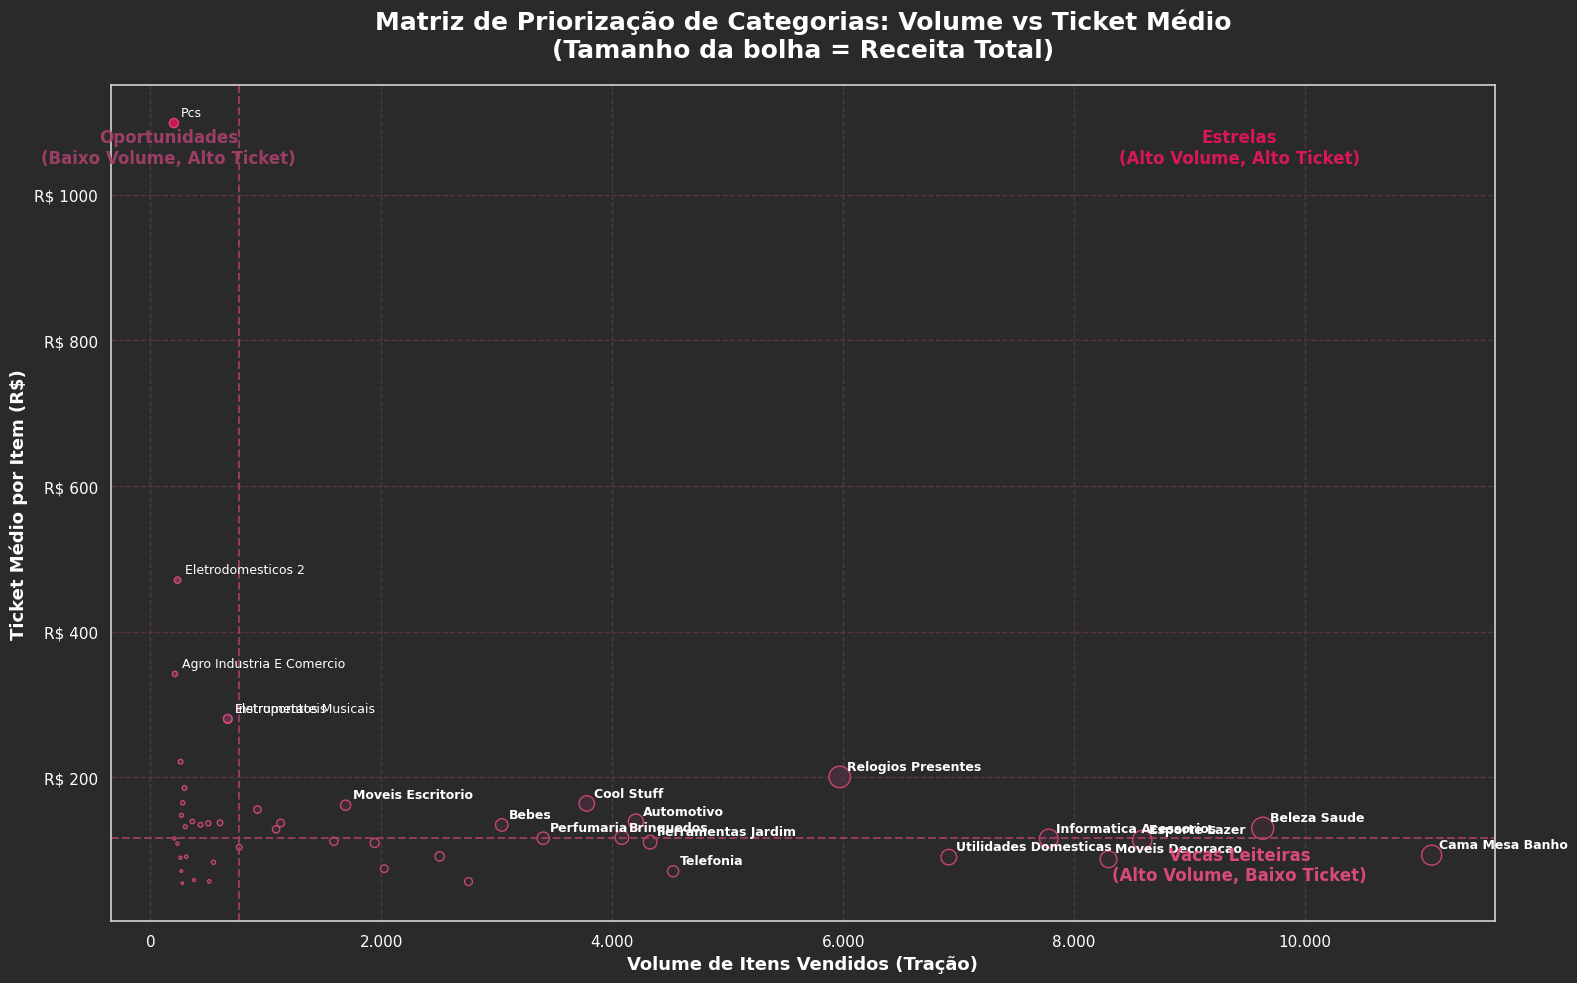

--- TOP CATEGORIAS POR RECEITA ---
                 categoria  receita_total  ticket_medio  total_itens
11            Beleza Saude     1255695.13    130.339955         9634
67      Relogios Presentes     1198185.21    200.701040         5970
13         Cama Mesa Banho     1035964.06     93.355327        11097
32           Esporte Lazer      979740.92    114.055986         8590
44  Informatica Acessorios      904322.02    116.221825         7781

--- OPORTUNIDADES DE ALTO TICKET (Ticket > 200, Volume entre 500 e 5000) ---
                categoria  receita_total  ticket_medio  total_itens
45  Instrumentos Musicais      187788.44    280.700209          669
31        Eletroportateis      187907.26    280.040626          671


In [349]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors

pedidos = pd.read_csv('olist_orders_dataset.csv')
itens = pd.read_csv('olist_order_items_dataset.csv')
produtos = pd.read_csv('olist_products_dataset.csv')
nome_categorias = pd.read_csv('product_category_name_translation.csv')

# Filtrando pedidos válidos
status_validos = ['delivered', 'shipped', 'invoiced', 'processing', 'approved']
pedidos_validos = pedidos[pedidos['order_status'].isin(status_validos)]['order_id']
itens_validos = itens[itens['order_id'].isin(pedidos_validos)]


# Mesclando os dados
df_validados = itens_validos.merge(produtos[['product_id', 'product_category_name']], on='product_id', how='left')
df_validados = df_validados.merge(nome_categorias, on='product_category_name', how='left')

# Criando coluna final de categoria
df_validados['categoria'] = df_validados['product_category_name'].str.replace('_', ' ').str.title()
df_validados['categoria'] = df_validados['categoria'].fillna('Outros')


# Criando métricas por categoria
metricas_categorias = df_validados.groupby('categoria').agg(
    receita_total=('price', 'sum'),
    total_itens=('order_id', 'count'),       # Volume total de itens
    pedidos_unicos=('order_id', 'nunique'),   # Volume de pedidos únicos
    ticket_medio=('price', 'mean')             # Ticket Médio (Preço médio do item)
).reset_index()

# Filtrando categorias com baixíssimo volume (ruído estatístico) - mínimo de 200 itens vendidos
metricas_categorias = metricas_categorias[metricas_categorias['total_itens'] >= 200].copy()

# Definindo medianas para os quadrantes
mediana_ticket = metricas_categorias['ticket_medio'].median()
mediana_volume = metricas_categorias['total_itens'].median()

# Top 10 categorias em receita para destacar
top_receita = metricas_categorias.nlargest(15, 'receita_total')['categoria'].tolist()
top_ticket = metricas_categorias.nlargest(5, 'ticket_medio')['categoria'].tolist()
top_categoria = set(top_receita + top_ticket)

# Plotandogem (Matriz de Priorização)
plt.figure(figsize=(16, 10))
# Cor de fundo:
plt.gcf().set_facecolor(paleta_fiap[0]) # Set the figure background color

sns.set_theme(style="whitegrid")

# Criando o Scatter/Bubble
custom_cmap = mcolors.LinearSegmentedColormap.from_list("FIAP_cmap", paleta_fiap)

scatter = plt.scatter(
    x=metricas_categorias['total_itens'],
    y=metricas_categorias['ticket_medio'],
    s=metricas_categorias['receita_total'] / 5000, # Tamanho da bolha = Receita
    alpha=0.8,
    c=metricas_categorias['ticket_medio'], # Cor baseada no ticket médio
    cmap=custom_cmap, # Mapa de cores customizado
    edgecolors=paleta_fiap[3], # Cor da borda dos círculos
    linewidth=1)

# Cor de fundo
ax = plt.gca()
ax.set_facecolor(paleta_fiap[0]) # Set the axes background color

# Adicionar linhas de quadrante (Medianas)
plt.axvline(mediana_volume, color=paleta_fiap[2], linestyle='--', alpha=0.8)
plt.axhline(mediana_ticket, color=paleta_fiap[2], linestyle='--', alpha=0.8)

# Anotações (Apenas para as principais para não poluir)
texts = []
for i, row in metricas_categorias.iterrows():
    if row['categoria'] in top_categoria or row['ticket_medio'] > 250:
        plt.annotate(
            row['categoria'],
            (row['total_itens'], row['ticket_medio']),
            xytext=(5, 5), textcoords='offset points',
            fontsize=9, fontweight='bold' if row['categoria'] in top_receita else 'normal',
            color='white' # Set annotation text color to white for better visibility on dark background
        )

# Formatação
plt.title('Matriz de Priorização de Categorias: Volume vs Ticket Médio\n(Tamanho da bolha = Receita Total)', fontsize=18, fontweight='bold', pad=20, color='white') # Set title color to white
plt.xlabel('Volume de Itens Vendidos (Tração)', fontsize=13, fontweight='bold', color='white') # Set xlabel color to white
plt.ylabel('Ticket Médio por Item (R$)', fontsize=13, fontweight='bold', color='white') # Set ylabel color to white

# Zonas Textuais
plt.text(metricas_categorias['total_itens'].max() * 0.85, metricas_categorias['ticket_medio'].max() * 0.95, 'Estrelas\n(Alto Volume, Alto Ticket)', color=paleta_fiap[4], fontsize=12, fontweight='bold', alpha=0.9, ha='center')
plt.text(metricas_categorias['total_itens'].max() * 0.85, mediana_ticket * 0.5, 'Vacas Leiteiras\n(Alto Volume, Baixo Ticket)', color=paleta_fiap[3], fontsize=12, fontweight='bold', alpha=0.9, ha='center')
plt.text(mediana_volume * 0.2, metricas_categorias['ticket_medio'].max() * 0.95, 'Oportunidades\n(Baixo Volume, Alto Ticket)', color=paleta_fiap[2], fontsize=12, fontweight='bold', alpha=0.9, ha='center')

# Eixos numéricos
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x:.0f}'))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.')))

# Cor dos ticks
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

# Cor do grid
ax.grid(color=paleta_fiap[1], linestyle='--', alpha=0.7)

sns.despine(right=False, left=False, bottom=False, top=False) # Keep the frame for better contrast with dark background
plt.tight_layout()
plt.savefig('category_matrix.png', dpi=300)
plt.show()

# Print top oportunidades para marketing
print("--- TOP CATEGORIAS POR RECEITA ---")
print(metricas_categorias.nlargest(5, 'receita_total')[['categoria', 'receita_total', 'ticket_medio', 'total_itens']])
print("\n--- OPORTUNIDADES DE ALTO TICKET (Ticket > 200, Volume entre 500 e 5000) ---")
opportunities = metricas_categorias[(metricas_categorias['ticket_medio'] > 200) & (metricas_categorias['total_itens'] > 500) & (metricas_categorias['total_itens'] < 5000)]
print(opportunities.sort_values(by='ticket_medio', ascending=False)[['categoria', 'receita_total', 'ticket_medio', 'total_itens']])


(metricas_categorias.sort_values(by = 'receita_total', ascending=False).reset_index()).head(10)

top_receita = metricas_categorias.sort_values(by = 'receita_total', ascending=False).reset_index().head(10)

top_ticket = (metricas_categorias.sort_values(by = 'ticket_medio', ascending=False).reset_index()).head(10)

2 - TKM X CATEGORIA

In [350]:
print('Ticket Médio por Categoria:')
display(metricas_categorias[['categoria', 'receita_total', 'ticket_medio']].sort_values('ticket_medio', ascending=False).round(2).head(10))

Ticket Médio por Categoria:


,categoria,receita_total,ticket_medio
62,Pcs,222963.13,1098.34
29,Eletrodomesticos 2,110649.74,470.85
0,Agro Industria E Comercio,72530.47,342.12
45,Instrumentos Musicais,187788.44,280.70
31,Eletroportateis,187907.26,280.04
72,Telefonia Fixa,57824.21,221.55
67,Relogios Presentes,1198185.21,200.70
19,Climatizacao,54723.16,185.50
53,Moveis Cozinha Area De Servico Jantar E Jardim,46070.37,165.13
26,Cool Stuff,620770.49,164.27


In [351]:
print('Top 10 Categorias por Ticket Médio:')
display(metricas_categorias[['categoria', 'receita_total', 'ticket_medio']].sort_values('ticket_medio', ascending=False).round(2).head(10))

Top 10 Categorias por Ticket Médio:


,categoria,receita_total,ticket_medio
62,Pcs,222963.13,1098.34
29,Eletrodomesticos 2,110649.74,470.85
0,Agro Industria E Comercio,72530.47,342.12
45,Instrumentos Musicais,187788.44,280.70
31,Eletroportateis,187907.26,280.04
72,Telefonia Fixa,57824.21,221.55
67,Relogios Presentes,1198185.21,200.70
19,Climatizacao,54723.16,185.50
53,Moveis Cozinha Area De Servico Jantar E Jardim,46070.37,165.13
26,Cool Stuff,620770.49,164.27


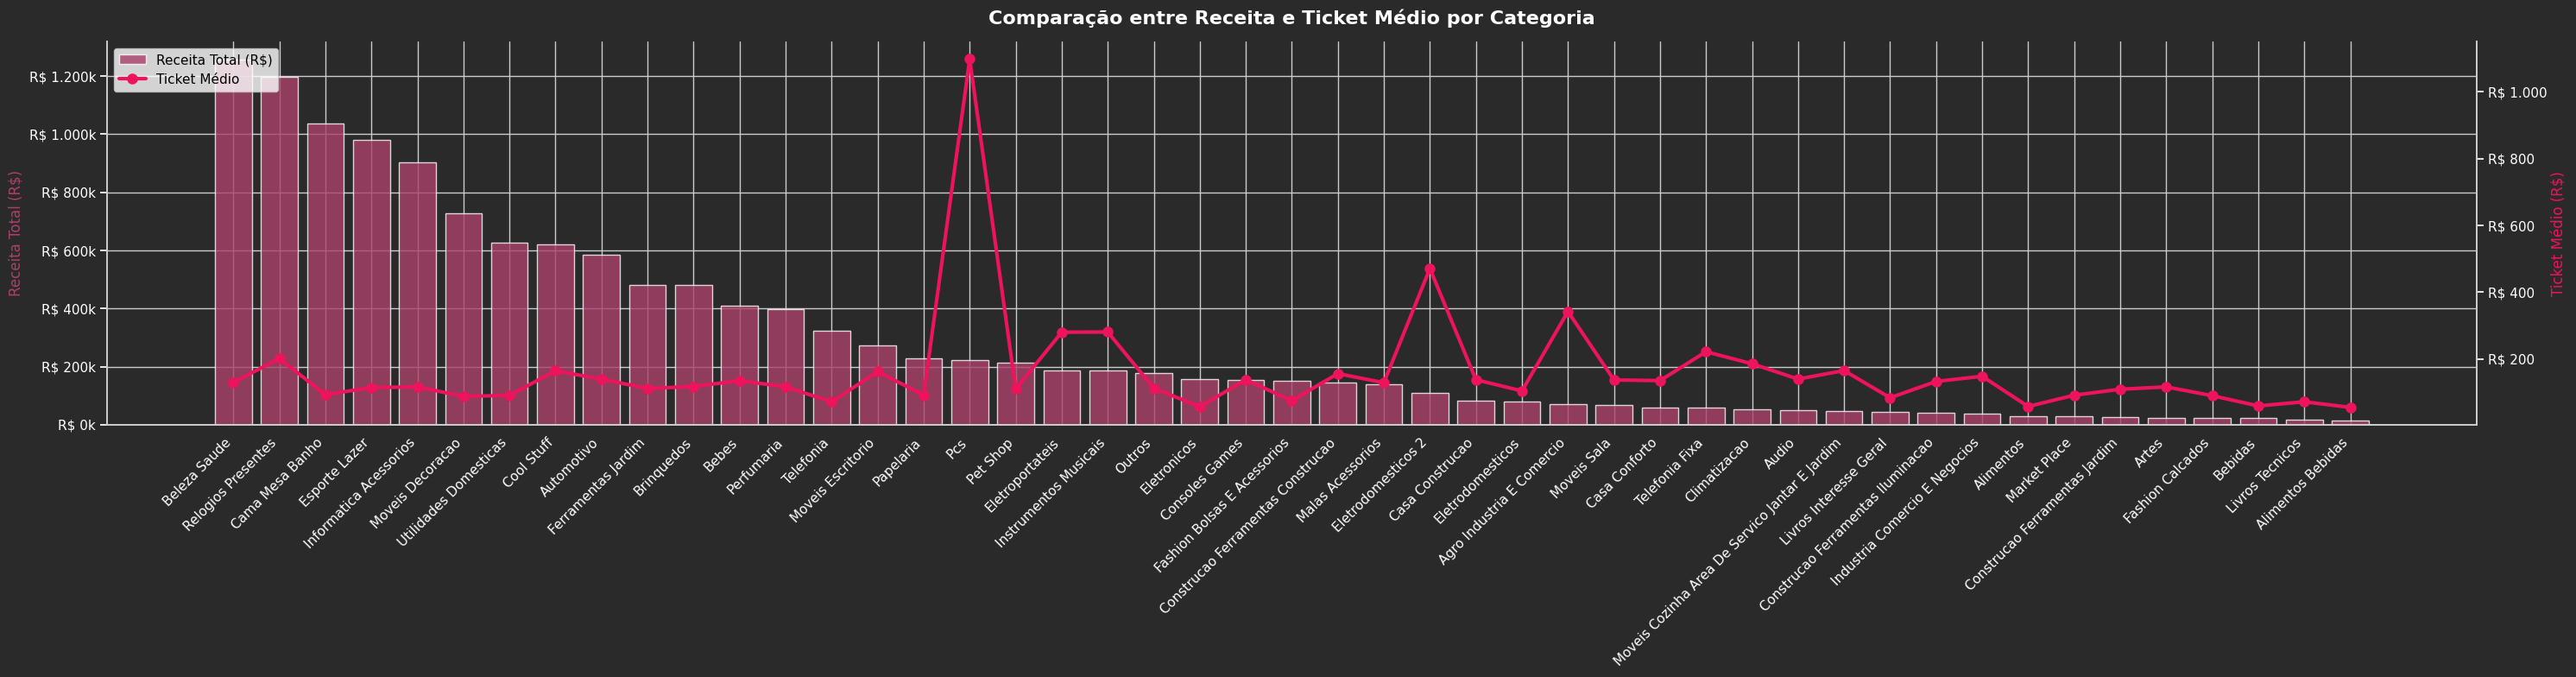

In [352]:
import matplotlib.ticker as ticker

# Sort the DataFrame for better visualization on the chart
metricas_categorias_sorted = metricas_categorias.sort_values('receita_total', ascending=False).copy()

paleta_fiap = ['#2a2a2a', '#6a3652', '#a9416b', '#ed4d84', '#ED145B']

# Create a figure with two y-axes for revenue and average ticket
fig, ax1 = plt.subplots(1, 1, figsize=(30, 8))
fig.set_facecolor(paleta_fiap[0])
sns.set_theme(style="whitegrid")

cor_receita = paleta_fiap[2] # Color for Revenue
cor_ticket = paleta_fiap[4] # Color for Average Ticket

ax1.set_facecolor(paleta_fiap[0])
ax1.bar(
    metricas_categorias_sorted['categoria'],
    metricas_categorias_sorted['receita_total'],
    color=cor_receita,
    alpha=0.8,
    label='Receita Total (R$)'
)

ax1.set_ylabel('Receita Total (R$)', color=cor_receita, fontsize=12)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x*1e-3:,.0f}k'.replace(',', '.')))
ax1.tick_params(axis='y', colors='white')

# Create a second y-axis for the average ticket
ax2 = ax1.twinx()
ax2.plot(
    metricas_categorias_sorted['categoria'],
    metricas_categorias_sorted['ticket_medio'],
    color=cor_ticket,
    marker='o', linewidth=3, markersize=8,
    label='Ticket Médio'
)
ax2.set_ylabel('Ticket Médio (R$)', color=cor_ticket, fontsize=12)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x*1:,.0f}'.replace(',', '.')))
ax2.grid(False)
ax2.tick_params(axis='y', colors='white')

# Format the plot
ax1.set_title('Comparação entre Receita e Ticket Médio por Categoria', fontsize=16, fontweight='bold', pad=15, color='white')
ax1.set_xticks(range(len(metricas_categorias_sorted['categoria'])))
ax1.set_xticklabels(metricas_categorias_sorted['categoria'], rotation=45, ha='right', color='white')
ax1.tick_params(axis='x', colors='white') # x-axis label color

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, fontsize=11, labelcolor='black')

sns.despine(right=False)
plt.tight_layout()
plt.show()

#### a. Identificando Rotas Críticas: Estados com Maiores Atrasos de Entrega

In [353]:
import json
import plotly.express as px
import pandas as pd
import numpy as np

# Carregar os dataframes necessários do dicionário 'datasets'
df_orders = datasets['orders']
df_customers = datasets['customers']
df_reviews = datasets['reviews']

# 1. Mesclar orders com customers para obter o estado do cliente
orders_customers = pd.merge(df_orders, df_customers, on='customer_id', how='inner')

# 2. Converter colunas de data para datetime
orders_customers['order_purchase_timestamp'] = pd.to_datetime(orders_customers['order_purchase_timestamp'])
orders_customers['order_delivered_customer_date'] = pd.to_datetime(orders_customers['order_delivered_customer_date'])
orders_customers['order_estimated_delivery_date'] = pd.to_datetime(orders_customers['order_estimated_delivery_date'])

# 3. Calcular o tempo de entrega em horas
orders_customers['delivery_time_hours'] = (orders_customers['order_delivered_customer_date'] - orders_customers['order_purchase_timestamp']).dt.total_seconds() / 3600

# NOVO CÓDIGO: Calcular o atraso na entrega em horas (Efetivo - Estimado)
# Positivo = Atraso (Chegou depois) | Negativo = Antecedência (Chegou antes)
orders_customers['delivery_delay_hours'] = (
    orders_customers['order_delivered_customer_date'] - orders_customers['order_estimated_delivery_date']
).dt.total_seconds() / 3600

# Remover linhas com tempo de entrega nulo (significam pedidos não entregues)
orders_customers_filtered = orders_customers.dropna(subset=['delivery_time_hours'])

# Mesclar com reviews para obter a pontuação da avaliação
orders_customers_reviews = pd.merge(orders_customers_filtered, df_reviews[['order_id', 'review_score']], on='order_id', how='left')

# 4. Calcular o tempo médio de entrega e a média de reviews por estado do cliente
avg_metrics_by_state = orders_customers_reviews.groupby('customer_state').agg(
    average_delivery_time_hours=('delivery_time_hours', 'mean'),
    average_review_score=('review_score', 'mean')
).reset_index()

# Re-calcular critical_states_delay, baseado no atraso (entrega efetiva vs. estimada)
# df_delay_by_state_calc utiliza 'delivery_delay_hours' que agora está definida
df_delay_by_state_calc = orders_customers.dropna(subset=['delivery_delay_hours']).copy()
avg_delay_by_state = df_delay_by_state_calc.groupby('customer_state', observed=False).agg(
    average_delivery_delay_hours=('delivery_delay_hours', 'mean')
).reset_index()

# Combinar avg_metrics_by_state e avg_delay_by_state para ter ambas as métricas no mesmo DataFrame
combined_state_metrics = pd.merge(
    avg_metrics_by_state,
    avg_delay_by_state,
    on='customer_state',
    how='left'
)

critical_states_delay = avg_delay_by_state.sort_values(
    by='average_delivery_delay_hours', ascending=False
).head(10).round(2)

# Filtrar o DataFrame combinado para os estados críticos
df_critical_states_performance = combined_state_metrics[
    combined_state_metrics['customer_state'].isin(critical_states_delay['customer_state'])
].copy()

fig = px.scatter(
    df_critical_states_performance,
    x='average_delivery_delay_hours',
    y='average_review_score',
    size=abs(df_critical_states_performance['average_delivery_delay_hours']), # Usar valor absoluto para o tamanho
    color='average_review_score',
    color_continuous_scale=paleta_fiap, # Usar a paleta Fiap
    hover_name='customer_state', # Mostrar o estado ao passar o mouse
    title='Atraso Médio de Entrega vs Média de Avaliação nos Estados Críticos',
    labels={
        'average_delivery_delay_hours': 'Atraso Médio de Entrega (horas)',
        'average_review_score': 'Média de Avaliação'
    },
    hover_data={'average_delivery_delay_hours': ':.2f', 'average_review_score': ':.2f'}
)

fig.update_layout(
    xaxis_title=dict(text='Atraso Médio de Entrega (horas)', font=dict(color='white')),
    yaxis_title=dict(text='Média de Avaliação', font=dict(color='white')),
    coloraxis_colorbar=dict(
        title=dict(text='Média de Avaliação', font=dict(color='white')),
        tickfont=dict(color='white')
    ),
    title=dict(text='Atraso Médio de Entrega vs Média de Avaliação nos Estados Críticos', x=0.5, font=dict(color='white')),
    yaxis=dict(gridcolor=paleta_fiap[1], griddash='dash', gridwidth=1, showgrid=True, tickfont=dict(color='white')),
    xaxis=dict(gridcolor=paleta_fiap[1], griddash='dash', gridwidth=1, showgrid=True, tickfont=dict(color='white')),
    plot_bgcolor='rgba(0,0,0,0)', # Fundo transparente
    paper_bgcolor='rgba(0,0,0,0)' # Fundo transparente
)

fig.show()

Identificando Rotas Críticas: Análise de Atraso e Avaliação por Estado
Com base nos estados com os maiores atrasos médios, vamos visualizar a relação entre o tempo de atraso e a média de avaliação dos reviews para entender melhor onde a situação é mais crítica, ou seja, onde os atrasos são maiores e as avaliações são mais baixas.

#### b. Identificando Rotas Críticas por Estado do Vendedor e do Cliente, Categoria e Métricas de Desempenho**

Para identificar as rotas críticas, precisamos consolidar informações de pedidos, clientes, vendedores, itens, produtos e avaliações. Em seguida, agruparemos os dados por estado do vendedor, estado do cliente e categoria do produto para analisar o atraso médio na entrega, a média de avaliações, o ticket médio e o impacto do frete em cada rota.

In [354]:
from sklearn.preprocessing import MinMaxScaler

# Criar uma cópia do dataframe filtrado para evitar modificar o original
df_critical_combined = rotas_analise_filtered.copy()

# ====================================================================
# 1. Normalizar as métricas para uma escala de 0 a 1
# ====================================================================

scaler = MinMaxScaler()

# Atraso Médio (maior = pior)
df_critical_combined['norm_atraso'] = scaler.fit_transform(
    df_critical_combined[['atraso_medio_dias']]
)

# Média de Avaliação (menor = pior, então invertemos a escala)
# Primeiro, inverta a pontuação (5 - review_medio), depois normalize
df_critical_combined['review_invertido'] = 5 - df_critical_combined['review_medio']
df_critical_combined['norm_review'] = scaler.fit_transform(
    df_critical_combined[['review_invertido']]
)

# Frete Percentual Médio (maior = pior)
df_critical_combined['norm_frete'] = scaler.fit_transform(
    df_critical_combined[['frete_percentual_medio']]
)

# ====================================================================
# 2. Calcular um Score de Criticidade Combinado
# ====================================================================
# Por simplicidade, vamos somar os scores normalizados.
# Se houver necessidade, pesos diferentes podem ser aplicados aqui.

df_critical_combined['criticality_score'] = (
    df_critical_combined['norm_atraso'] +
    df_critical_combined['norm_review'] +
    df_critical_combined['norm_frete']
)

# ====================================================================
# 3. Identificar as 5 rotas mais críticas
# ====================================================================

top_5_rotas_criticas_combinadas = df_critical_combined.nlargest(5, 'criticality_score')

# ====================================================================
# 4. Exibir a tabela das 5 rotas mais críticas
# ====================================================================

display(
    top_5_rotas_criticas_combinadas[
        [
            'seller_state',
            'customer_state',
            'product_category_name_final',
            'total_pedidos',
            'atraso_medio_dias',
            'review_medio',
            'frete_percentual_medio',
            'criticality_score'
        ]
    ].style.set_caption('Top 5 Rotas Mais Críticas (Score Combinado)')
)


,seller_state,customer_state,product_category_name_final,total_pedidos,atraso_medio_dias,review_medio,frete_percentual_medio,criticality_score
3692,SP,MA,electronics,11,-6.970000,3.090000,196.300000,2.212227
1599,PR,MG,bed_bath_table,13,2.480000,2.210000,29.020000,1.921918
4409,SP,SE,auto,12,10.120000,3.580000,68.260000,1.845403
3698,SP,MA,garden_tools,15,-7.740000,2.650000,97.000000,1.834037
4225,SP,RN,perfumery,12,-5.620000,3.000000,82.990000,1.694579


In [355]:
import plotly.graph_objects as go

# 1. Preparar Dados de Geolocalização (Centróides dos Estados)
# Remover duplicatas e nulos para calcular uma média precisa por estado
geoloc_state_coords = datasets['geolocation'].dropna(subset=['geolocation_lat', 'geolocation_lng', 'geolocation_state'])
geoloc_state_coords = geoloc_state_coords.groupby('geolocation_state').agg(
    state_lat=('geolocation_lat', 'mean'),
    state_lng=('geolocation_lng', 'mean')
).reset_index()

# 2. Mesclar Geolocalização nas Rotas Críticas
rotas_mapa = top_5_rotas_criticas_combinadas.copy()

# Mesclar para as coordenadas do estado do vendedor
rotas_mapa = rotas_mapa.merge(
    geoloc_state_coords,
    left_on='seller_state',
    right_on='geolocation_state',
    how='left'
).rename(columns={'state_lat': 'seller_lat', 'state_lng': 'seller_lng'})

# Mesclar para as coordenadas do estado do cliente
rotas_mapa = rotas_mapa.merge(
    geoloc_state_coords,
    left_on='customer_state',
    right_on='geolocation_state',
    how='left',
    suffixes=('_seller', '_customer')
).rename(columns={'state_lat': 'customer_lat', 'state_lng': 'customer_lng'})

# Remover colunas geolocation_state que não são mais necessárias
rotas_mapa = rotas_mapa.drop(columns=['geolocation_state_seller', 'geolocation_state_customer'])

# 3. Criar o Mapa com Plotly
fig = go.Figure()

# Adicionar as rotas como linhas no mapa
for index, row in rotas_mapa.iterrows():
    fig.add_trace(go.Scattermapbox(
        mode='lines',
        lon=[row['seller_lng'], row['customer_lng']],
        lat=[row['seller_lat'], row['customer_lat']],
        marker={'size': 10},
        line={'width': row['criticality_score'] * 2, 'color': paleta_fiap[4]}, # Linha mais grossa para rotas mais críticas
        hoverinfo='text',
        text=(
            f"Rota: {row['seller_state']} -> {row['customer_state']} ({row['product_category_name_final']})<br>" +
            f"Criticality Score: {row['criticality_score']:.2f}<br>" +
            f"Atraso Médio: {row['atraso_medio_dias']:.2f} dias<br>" +
            f"Avaliação Média: {row['review_medio']:.2f}<br>" +
            f"Frete % Médio: {row['frete_percentual_medio']:.2f}%<br>" +
            f"Total de Pedidos: {row['total_pedidos']}"
        ),
        name=f"Rota {index + 1}"
    ))

# Adicionar marcadores para os estados do vendedor (origem)
fig.add_trace(go.Scattermapbox(
    mode='markers',
    lon=rotas_mapa['seller_lng'],
    lat=rotas_mapa['seller_lat'],
    marker={'size': 10, 'color': paleta_fiap[3]},
    hoverinfo='text',
    text=rotas_mapa.apply(lambda x: f"Origem: {x['seller_state']}<br>Categoria: {x['product_category_name_final']}", axis=1),
    name='Origem (Vendedor)'
))

# Adicionar marcadores para os estados do cliente (destino)
fig.add_trace(go.Scattermapbox(
    mode='markers',
    lon=rotas_mapa['customer_lng'],
    lat=rotas_mapa['customer_lat'],
    marker={'size': 10, 'color': paleta_fiap[2]},
    hoverinfo='text',
    text=rotas_mapa.apply(lambda x: f"Destino: {x['customer_state']}<br>Categoria: {x['product_category_name_final']}", axis=1),
    name='Destino (Cliente)'
))


# Configurar o layout do mapa
fig.update_layout(
    mapbox_style='carto-positron', # Pode ser 'open-street-map', 'carto-positron', 'carto-darkmatter', etc.
    mapbox_zoom=3,  # Ajuste o zoom conforme necessário
    mapbox_center={'lat': -14.235, 'lon': -51.925}, # Centro do Brasil
    title={
        'text': 'Top 5 Rotas Mais Críticas no Brasil',
        'y': 0.9,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'color': 'white', 'size': 18}
    },
    height=800,
    width=1200,
    paper_bgcolor='rgba(0,0,0,0)',  # Fundo transparente do gráfico
    plot_bgcolor='rgba(0,0,0,0)',   # Fundo transparente da área do plot
    legend_font_color='white',
    hoverlabel=dict(bgcolor='white', font_size=12, font_family='sans-serif')
)

fig.show()

In [356]:
# 1. Mesclar df_logistica com df_order_items para obter detalhes do item, vendedor, preço e frete
df_rotas = df_logistica.merge(
    df_order_items[['order_id', 'product_id', 'seller_id', 'price', 'freight_value']],
    on='order_id',
    how='inner' # Usar inner para garantir que temos itens para os pedidos no df_logistica
)

# 2. Mesclar com df_products para obter o nome da categoria do produto
df_rotas = df_rotas.merge(
    df_products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# 3. Mesclar com df_product_category_name_translation para obter o nome da categoria em inglês
df_rotas = df_rotas.merge(
    df_product_category_name_translation,
    on='product_category_name',
    how='left'
)
# Usar o nome traduzido se disponível, caso contrário, usar o original
df_rotas['product_category_name_final'] = df_rotas['product_category_name_english'].fillna(df_rotas['product_category_name'])

# 4. Mesclar com df_sellers para obter o estado do vendedor
df_rotas = df_rotas.merge(
    df_sellers[['seller_id', 'seller_state']],
    on='seller_id',
    how='left'
)

# Remover linhas com informações críticas ausentes (ex: estado do vendedor, categoria)
df_rotas_cleaned = df_rotas.dropna(subset=['seller_state', 'product_category_name_final']).copy()

# Filtrar apenas pedidos entregues para análise de atraso e review
df_rotas_delivered = df_rotas_cleaned[df_rotas_cleaned['pedido_entregue']].copy()

# Calcular frete percentual em relação ao preço do produto
df_rotas_delivered['frete_percentual'] = (
    df_rotas_delivered['freight_value'] / df_rotas_delivered['price'] * 100
).replace([np.inf, -np.inf], np.nan) # Lidar com divisão por zero

# Agrupar por estado do vendedor, estado do cliente e categoria do produto
# Calcular as métricas relevantes
rotas_analise = df_rotas_delivered.groupby(['seller_state', 'customer_state', 'product_category_name_final']).agg(
    total_pedidos=('order_id', 'nunique'),
    receita_total=('price', 'sum'),
    frete_total=('freight_value', 'sum'),
    ticket_medio=('price', 'mean'), # Ticket médio por item
    atraso_medio_dias=('atraso_dias', 'mean'),
    review_medio=('review_score', 'mean'),
    frete_percentual_medio=('frete_percentual', 'mean')
).reset_index()

# Arredondar as colunas numéricas para melhor visualização
rotas_analise = rotas_analise.round({
    'receita_total': 2,
    'frete_total': 2,
    'ticket_medio': 2,
    'atraso_medio_dias': 2,
    'review_medio': 2,
    'frete_percentual_medio': 2
})

# Exibir as primeiras linhas da base de análise de rotas
display(rotas_analise.head())

,seller_state,customer_state,product_category_name_final,total_pedidos,receita_total,frete_total,ticket_medio,atraso_medio_dias,review_medio,frete_percentual_medio
0,AM,AL,telephony,1,949.00,35.26,949.00,38.01,1.0,3.72
1,AM,MA,telephony,1,114.00,21.25,114.00,0.39,5.0,18.64
2,AM,MG,telephony,1,114.00,25.29,114.00,-10.36,1.0,22.18
3,BA,AC,computers,1,1200.00,51.70,1200.00,24.07,1.0,4.31
4,BA,AL,computers,2,2049.99,56.38,1024.99,-14.89,4.5,2.84


Agora que temos a base de dados consolidada com as métricas por rota (estado do vendedor -> estado do cliente -> categoria do produto), podemos identificar as rotas críticas. Para isso, vamos focar em:

1.  **Rotas com Atraso Médio Elevado**: Estados onde os pedidos chegam consistentemente atrasados.
2.  **Rotas com Baixa Média de Avaliação**: Indica insatisfação geral do cliente, que pode estar ligada ao atraso ou a outros fatores.
3.  **Rotas com Alto Percentual de Frete**: Onde o custo do frete é desproporcionalmente alto em relação ao valor do produto, impactando a lucratividade e o preço final para o cliente.

Vamos começar identificando as 10 rotas com maior atraso médio.

In [357]:
import plotly.express as px

# Remover possíveis valores infinitos ou NaN resultantes da divisão por zero ou dados ausentes
rotas_analise_clean = rotas_analise.replace([np.inf, -np.inf], np.nan).dropna(subset=['atraso_medio_dias', 'review_medio', 'frete_percentual_medio'])

# Definir um limite mínimo de pedidos para considerar a rota (evitar ruído de poucas observações)
min_pedidos_rota = 10 # Ajuste conforme necessário
rotas_analise_filtered = rotas_analise_clean[rotas_analise_clean['total_pedidos'] >= min_pedidos_rota]

# 1. Top 10 Rotas com Maior Atraso Médio (onde o atraso_medio_dias é positivo)
top_10_atraso = rotas_analise_filtered[rotas_analise_filtered['atraso_medio_dias'] > 0].nlargest(10, 'atraso_medio_dias')
display(top_10_atraso.style.set_caption('Top 10 Rotas com Maior Atraso Médio (dias)'))

# 2. Top 10 Rotas com Menor Média de Avaliação
top_10_baixa_review = rotas_analise_filtered.nsmallest(10, 'review_medio')
display(top_10_baixa_review.style.set_caption('Top 10 Rotas com Menor Média de Avaliação'))

# 3. Top 10 Rotas com Maior Percentual de Frete
top_10_alto_frete = rotas_analise_filtered.nlargest(10, 'frete_percentual_medio')
display(top_10_alto_frete.style.set_caption('Top 10 Rotas com Maior Percentual de Frete Médio'))


# Visualização Interativa: Atraso Médio vs Review Médio, com tamanho pelo volume de pedidos e cor pelo frete percentual
fig = px.scatter(
    rotas_analise_filtered,
    x='atraso_medio_dias',
    y='review_medio',
    size='total_pedidos', # Tamanho da bolha pelo volume de pedidos
    color='frete_percentual_medio', # Cor pelo percentual de frete
    hover_name='product_category_name_final',
    hover_data={
        'seller_state': True,
        'customer_state': True,
        'atraso_medio_dias': ':.2f',
        'review_medio': ':.2f',
        'frete_percentual_medio': ':.2f%',
        'receita_total': ':.2f'
    },
    color_continuous_scale=paleta_fiap, # Usar a paleta Fiap
    title='Rotas Críticas: Atraso Médio vs Média de Avaliação (Volume e Frete %)',
    labels={
        'atraso_medio_dias': 'Atraso Médio (dias)',
        'review_medio': 'Média de Avaliação',
        'total_pedidos': 'Volume de Pedidos',
        'frete_percentual_medio': 'Frete % Médio'
    }
)

fig.update_layout(
    xaxis_title=dict(text='Atraso Médio (dias)', font=dict(color='white')),
    yaxis_title=dict(text='Média de Avaliação', font=dict(color='white')),
    coloraxis_colorbar=dict(
        title=dict(text='Frete % Médio', font=dict(color='white')),
        tickfont=dict(color='white')
    ),
    title=dict(text='Rotas Críticas: Atraso Médio vs Média de Avaliação (Volume e Frete %)', x=0.5, font=dict(color='white')),
    yaxis=dict(gridcolor=paleta_fiap[1], griddash='dash', gridwidth=1, showgrid=True, tickfont=dict(color='white')),
    xaxis=dict(gridcolor=paleta_fiap[1], griddash='dash', gridwidth=1, showgrid=True, tickfont=dict(color='white')),
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)'
)

fig.show()

,seller_state,customer_state,product_category_name_final,total_pedidos,receita_total,frete_total,ticket_medio,atraso_medio_dias,review_medio,frete_percentual_medio
4409,SP,SE,auto,12,1464.160000,554.010000,122.010000,10.120000,3.580000,68.260000
717,MG,BA,toys,10,984.390000,207.040000,98.440000,6.030000,3.330000,32.620000
2388,RJ,SP,electronics,10,1834.800000,198.390000,166.800000,3.580000,4.090000,26.880000
1599,PR,MG,bed_bath_table,13,1801.900000,421.650000,128.710000,2.480000,2.210000,29.020000
694,MG,BA,cool_stuff,13,1119.700000,279.930000,79.980000,0.980000,4.070000,30.480000
2047,RJ,CE,watches_gifts,13,3306.780000,479.090000,220.450000,0.480000,2.930000,27.230000


,seller_state,customer_state,product_category_name_final,total_pedidos,receita_total,frete_total,ticket_medio,atraso_medio_dias,review_medio,frete_percentual_medio
1599,PR,MG,bed_bath_table,13,1801.900000,421.650000,128.710000,2.480000,2.210000,29.020000
819,MG,GO,housewares,10,1804.490000,776.940000,90.220000,-12.920000,2.350000,63.620000
2255,RJ,PR,watches_gifts,26,8238.870000,717.530000,196.160000,-10.210000,2.600000,14.650000
1797,PR,RJ,construction_tools_construction,18,3729.380000,414.220000,186.470000,-4.340000,2.630000,18.710000
3698,SP,MA,garden_tools,15,1394.680000,817.650000,69.730000,-7.740000,2.650000,97.000000
3914,SP,PA,office_furniture,19,3596.250000,1574.980000,143.850000,-17.610000,2.800000,44.590000
2047,RJ,CE,watches_gifts,13,3306.780000,479.090000,220.450000,0.480000,2.930000,27.230000
1725,PR,PE,furniture_decor,11,1261.600000,534.010000,74.210000,-6.970000,2.940000,48.820000
3114,SC,RJ,health_beauty,18,5520.390000,372.760000,290.550000,-14.640000,2.950000,31.460000
1792,PR,RJ,bed_bath_table,18,2951.700000,485.630000,163.980000,-7.040000,3.000000,25.610000


,seller_state,customer_state,product_category_name_final,total_pedidos,receita_total,frete_total,ticket_medio,atraso_medio_dias,review_medio,frete_percentual_medio
3692,SP,MA,electronics,11,274.990000,339.480000,25.000000,-6.970000,3.090000,196.300000
1065,MG,RJ,construction_tools_construction,12,2915.850000,533.670000,208.280000,-11.320000,4.430000,183.940000
1212,MG,SP,construction_tools_construction,34,6897.510000,1605.550000,191.600000,-8.940000,4.060000,166.370000
1542,PR,ES,electronics,13,293.060000,465.440000,18.320000,-12.080000,4.270000,162.630000
4268,SP,RO,telephony,16,620.090000,596.420000,36.480000,-20.190000,4.440000,143.770000
3747,SP,MG,fashion_underwear_beach,13,1070.800000,275.910000,59.490000,-16.990000,4.710000,135.930000
4035,SP,PI,electronics,13,630.750000,363.430000,48.520000,-6.930000,4.150000,133.850000
1132,MG,RS,consoles_games,11,855.080000,277.370000,71.260000,-15.090000,4.750000,126.670000
1474,PR,BA,electronics,11,721.300000,430.900000,55.480000,-12.390000,4.690000,124.860000
4057,SP,PI,telephony,26,772.760000,720.180000,28.620000,-8.320000,4.110000,108.080000


#### c. Proposta de Estratégias de Otimização de Frete para Rotas Críticas**

Com base nas análises realizadas, que identificaram estados com maiores atrasos e as categorias de produtos (por tipo e peso) mais afetadas, podemos propor as seguintes estratégias de otimização de frete para as rotas críticas:

1.  **Negociação e Diversificação de Transportadoras:**
    *   **Estados Críticos:** Para os estados com atrasos mais severos e baixas avaliações, é crucial reavaliar as transportadoras parceiras. Pode ser necessário negociar novos SLAs (Service Level Agreements) com penalidades mais rigorosas para atrasos, ou buscar novas transportadoras com melhor histórico de desempenho nessas regiões.
    *   **Rotas Específicas:** Se as análises de categorias de produtos indicarem que certos tipos de itens (ex: eletrônicos, produtos frágeis, etc.) sofrem mais atrasos em rotas específicas, pode-se buscar transportadoras especializadas nesse tipo de carga.

2.  **Otimização de Rotas e Centros de Distribuição (CDs):**
    *   **Análise de Malha Logística:** Realizar um estudo aprofundado da malha logística para os estados críticos. Isso pode incluir a abertura de novos pontos de distribuição (Cross-Docking ou Centros de Distribuição menores) mais próximos a essas regiões, ou o uso de rotas alternativas para contornar gargalos de tráfego ou infraestrutura.
    *   **Last Mile Delivery:** Para áreas urbanas em estados críticos, explorar parcerias com empresas de "last mile delivery" que utilizam modais de transporte alternativos (ex: bicicletas, motos elétricas) para entregas mais rápidas e eficientes.

3.  **Gestão de Estoque e Previsão de Demanda:**
    *   **Estoque Estratégico:** Manter um estoque de segurança maior de produtos das categorias mais afetadas por atrasos nos CDs mais próximos dos estados críticos. Isso permite um despacho mais rápido e reduz a dependência do tempo de trânsito.
    *   **Previsão Aprimorada:** Utilizar modelos preditivos para prever picos de demanda em categorias e regiões críticas, permitindo o planejamento antecipado de transporte e estoque.

4.  **Embalagem e Manuseio de Produtos:**
    *   **Revisão de Embalagem:** Para categorias de produtos que, apesar de leves, sofrem atrasos (talvez por manuseio inadequado), investir em embalagens mais robustas e padronizadas pode otimizar o empilhamento e manuseio, reduzindo danos e, consequentemente, reentregas ou insatisfação.
    *   **Produtos Pesados:** Se os produtos "Muito Pesados" forem um fator, avaliar a possibilidade de transportadoras com equipamentos específicos para manuseio de cargas volumosas ou a subdivisão de remessas, quando possível, para agilizar o transporte.

5.  **Tecnologia e Rastreamento:**
    *   **Monitoramento em Tempo Real:** Implementar ou aprimorar sistemas de rastreamento em tempo real para todas as remessas, especialmente as destinadas a rotas críticas. Isso permite identificar e mitigar problemas proativamente.
    *   **Feedback Contínuo:** Utilizar os dados de atraso e review para fornecer feedback contínuo às transportadoras, incentivando a melhoria do serviço e a responsabilização por não conformidades.

Ao focar nestas áreas e monitorar continuamente os resultados, será possível mitigar os atrasos nas rotas críticas, melhorar a satisfação do cliente e otimizar os custos de frete.

In [358]:
import plotly.express as px

# Assegurar que os DataFrames necessários estão disponíveis
# df_logistica, rotas_analise e rotas_analise_filtered são recriados na célula e9bc4697
# portanto, devem estar disponíveis aqui.

# Calcular as medianas para criar os quadrantes de prioridade
mediana_frete_percentual = rotas_analise_filtered['frete_percentual_medio'].median()
mediana_frete_total = rotas_analise_filtered['frete_total'].median()

# Criar o gráfico de dispersão
fig = px.scatter(
    rotas_analise_filtered,
    x='frete_percentual_medio',
    y='frete_total',
    size='receita_total', # Tamanho da bolha pela receita total
    color='review_medio', # Cor pela média de avaliação
    hover_name='product_category_name_final',
    hover_data={
        'seller_state': True,
        'customer_state': True,
        'atraso_medio_dias': ':.2f',
        'review_medio': ':.2f',
        'frete_percentual_medio': ':.2f%',
        'frete_total': ':.2f',
        'receita_total': ':.2f',
        'total_pedidos': True
    },
    color_continuous_scale=paleta_fiap, # Usar a paleta Fiap
    title='Rotas Críticas: Oportunidades de Melhoria de Frete (Percentual vs. Total)',
    labels={
        'frete_percentual_medio': 'Frete % Médio (maior = pior)',
        'frete_total': 'Frete Total (R$)',
        'receita_total': 'Receita Total (R$)',
        'review_medio': 'Média de Avaliação'
    },
    size_max=60 # Definir um tamanho máximo para as bolhas
)

# Adicionar linhas de referência para as medianas
fig.add_vline(
    x=mediana_frete_percentual,
    line_dash='dash',
    line_color='white',
    opacity=0.7,
    annotation_text=f'Mediana Frete % ({mediana_frete_percentual:.2f}%)',
    annotation_position='top right',
    annotation_font_color='white'
)
fig.add_hline(
    y=mediana_frete_total,
    line_dash='dash',
    line_color='white',
    opacity=0.7,
    annotation_text=f'Mediana Frete Total (R$ {mediana_frete_total:.2f})',
    annotation_position='bottom right',
    annotation_font_color='white'
)

# Adicionar uma área para o quadrante de oportunidade
fig.add_shape(
    type='rect',
    x0=mediana_frete_percentual,
    x1=rotas_analise_filtered['frete_percentual_medio'].max() * 1.05,
    y0=mediana_frete_total,
    y1=rotas_analise_filtered['frete_total'].max() * 1.05,
    fillcolor=paleta_fiap[4],
    opacity=0.07,
    line_width=0,
    layer='below'
)

# Adicionar anotação para o quadrante de oportunidade
fig.add_annotation(
    x=mediana_frete_percentual + (rotas_analise_filtered['frete_percentual_medio'].max() - mediana_frete_percentual) * 0.5,
    y=mediana_frete_total + (rotas_analise_filtered['frete_total'].max() - mediana_frete_total) * 0.8,
    text='<b>OPORTUNIDADE<br>DE MELHORIA</b>',
    showarrow=False,
    font=dict(
        color=paleta_fiap[4],
        size=13
    ),
    align='center'
)

fig.update_layout(
    xaxis_title=dict(text='Frete % Médio (maior = pior)', font=dict(color='white')),
    yaxis_title=dict(text='Frete Total (R$)', font=dict(color='white')),
    coloraxis_colorbar=dict(
        title=dict(text='Média de Avaliação', font=dict(color='white')),
        tickfont=dict(color='white')
    ),
    title=dict(text='Rotas Críticas: Oportunidades de Melhoria de Frete (Percentual vs. Total)', x=0.5, font=dict(color='white')),
    yaxis=dict(gridcolor=paleta_fiap[1], griddash='dash', gridwidth=1, showgrid=True, tickfont=dict(color='white')),
    xaxis=dict(gridcolor=paleta_fiap[1], griddash='dash', gridwidth=1, showgrid=True, tickfont=dict(color='white')),
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font=dict(color='white'),
    hovermode='closest'
)

fig.show()

# Exibir as top 10 rotas no quadrante de oportunidade
top_freight_opportunity_routes = rotas_analise_filtered[
    (rotas_analise_filtered['frete_percentual_medio'] >= mediana_frete_percentual) &
    (rotas_analise_filtered['frete_total'] >= mediana_frete_total)
].nlargest(10, ['frete_total', 'frete_percentual_medio'])

display(
    top_freight_opportunity_routes[
        [
            'seller_state',
            'customer_state',
            'product_category_name_final',
            'total_pedidos',
            'receita_total',
            'frete_total',
            'frete_percentual_medio',
            'atraso_medio_dias',
            'review_medio'
        ]
    ].style.set_caption('Top 10 Rotas com Maiores Oportunidades de Melhoria de Frete')
)

,seller_state,customer_state,product_category_name_final,total_pedidos,receita_total,frete_total,frete_percentual_medio,atraso_medio_dias,review_medio
4494,SP,SP,housewares,2061,183276.710000,35032.840000,32.310000,-9.480000,4.210000
4160,SP,RJ,furniture_decor,582,66148.360000,16743.530000,35.620000,-10.090000,3.570000
4513,SP,SP,telephony,1341,68539.660000,13530.540000,35.580000,-8.720000,4.040000
3753,SP,MG,furniture_decor,486,48429.860000,13272.760000,40.150000,-12.460000,3.990000
4170,SP,RJ,housewares,474,45873.790000,12676.140000,44.750000,-12.460000,3.760000
3763,SP,MG,housewares,431,39184.180000,11977.700000,49.830000,-12.180000,4.010000
3757,SP,MG,health_beauty,563,71867.140000,11598.330000,32.230000,-12.560000,4.290000
4320,SP,RS,furniture_decor,308,33040.640000,8298.060000,35.640000,-14.470000,3.920000
4093,SP,PR,furniture_decor,257,28836.600000,8288.710000,39.140000,-12.710000,3.930000
1231,MG,SP,housewares,291,31059.070000,8272.960000,44.120000,-13.340000,4.200000


Eixos: O eixo horizontal (X) representa o Frete Percentual Médio (o custo do frete como percentual do valor do produto)

Eixo vertical (Y) representa o Frete Total (R$)**. * **Tamanho das Bolhas:** O tamanho de cada bolha indica a **Receita Total (R$$)**. * **Tamanho das Bolhas:** O tamanho de cada bolha indica a **Receita Total (R$) gerada por aquela rota (combinação de estado do vendedor, estado do cliente e categoria do produto).

Cor das Bolhas: A cor varia de acordo com a Média de Avaliação dos clientes, utilizando a nossa paleta. Cores mais escuras (cinza) tendem a indicar avaliações mais baixas, enquanto cores mais claras (rosa/vermelho) indicam avaliações mais altas.

Linhas Tracejadas: As linhas tracejadas representam as medianas do Frete Percentual Médio e do Frete Total, dividindo o gráfico em quatro quadrantes.
Oportunidade de Melhoria Identificada:

O quadrante superior direito é explicitamente marcado como "OPORTUNIDADE DE MELHORIA". Este quadrante destaca as rotas que apresentam simultaneamente:

Alto Frete Percentual Médio: O custo do frete é desproporcionalmente alto em relação ao valor do produto.

Alto Frete Total: O valor absoluto do frete pago nessas rotas é elevado.

Estas são as rotas mais críticas para intervenção. As categorias de produtos e estados que caem neste quadrante indicam que há um grande impacto financeiro (alto frete total) e um frete muito caro em relação ao produto, o que pode afetar a competitividade, a rentabilidade e a satisfação do cliente, especialmente se as avaliações médias (cor das bolhas) não forem boas. Focar nessas rotas pode gerar os maiores retornos em termos de otimização logística e financeira.